# Modélisation de la Probabilité de Défaut (PD)

**Objectif**  
Ce notebook implémente un pipeline de modélisation de la Probabilité de Défaut (PD) conforme aux exigences réglementaires Bâle III . 
Il couvre l'ensemble des étapes : de l'exploration des données jusqu'à la segmentation en classes homogènes de risque (CHR), 
en passant par la sélection des variables, la modélisation par régression logistique et la validation.

**Structure du pipeline**

| # | Étape | Objectif |
|---|-------|---------|
| 0 | Configuration & Imports | Centraliser les dépendances et le style graphique |
| 1 | Chargement & Contrôles qualité | Vérifier la profondeur historique et la cohérence des données |
| 2 | Analyse exploratoire (EDA) | Comprendre les taux de défaut, distributions et dynamiques temporelles |
| 3 | Prétraitement & Feature Engineering | Gérer les valeurs manquantes, outliers, et discrétiser les variables |
| 4 | Sélection des variables | Réduire la dimensionnalité par variance, corrélation et pouvoir discriminant |
| 5 | Échantillonnage | Découpage temporel train/test, contrôle de représentativité (PSI), SMOTE |
| 6 | Modélisation | Régression logistique (statsmodels) avec sélection forward BIC |
| 7 | Évaluation & Validation | AUC/Gini, K-Fold, Bootstrap, sous-populations matérielles |
| 8 | Classes Homogènes de Risque | K-Means, déciles, tests d'homogénéité/hétérogénéité, Marascuilo |
| 9 | Export des résultats | Sauvegarde des tables enrichies pour la calibration |



## Section 0-Configuration & Imports

In [1]:
# ── Bibliothèques standard ────────────────────────────────────────────────────
import warnings
import os
from itertools import combinations

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import gdown

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import jinja2

# ── Statistiques & économétrie ────────────────────────────────────────────────
import scipy.stats as stats
from scipy.stats import chi2_contingency, chi2, sem,wilcoxon, norm
import statsmodels.api as sm
import statsmodels.stats.weightstats as stw

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, chi2 as chi2_sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (
    roc_curve, auc, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
from imblearn.over_sampling import SMOTE
#from yellowbrick.cluster import KElbowVisualizer

# ── Divers ────────────────────────────────────────────────────────────────────
import ppscore as pps
from openpyxl import Workbook
import rich

# ── Configuration globale ─────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Thème graphique unique ────────────────────────────────────────────────────
COLORS = ['#E74C3C', '#2196F3', '#2ECC71', '#F39C12', '#9B59B6']
COLOR_DEFAUT   = '#E74C3C'
COLOR_SAIN     = '#2ECC71'
COLOR_NEUTRE   = '#2196F3'
COLOR_ACCENT   = '#F39C12'

plt.rcParams.update({
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
    'axes.grid'         : True,
    'grid.color'        : '#E0E0E0',
    'grid.linestyle'    : '--',
    'grid.linewidth'    : 0.6,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'font.size'         : 11,
    'axes.titlesize'    : 13,
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 9,
    'ytick.labelsize'   : 9,
    'legend.fontsize'   : 10,
    'figure.dpi'        : 100,
})

# ── Dossier données brutes─────────────────────────────────────────────────────────
INPUT_DIR = "data"
os.makedirs(INPUT_DIR, exist_ok=True)

# ── Dossier de sortie ─────────────────────────────────────────────────────────
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Configuration chargée.")

Configuration chargée.


## Section 1-Chargement & Contrôles Qualité des Données

### 1.1 Chargement

**Contexte métier** : les données d'entrée constituent la base de modélisation. Leur qualité conditionne directement la robustesse du modèle. Un contrôle rigoureux dès l'ingestion est indispensable avant tout traitement.

**Rappel réglementaire** : Bâle III exige a minima **5 ans d'historique** pour l'estimation interne des paramètres de risque.

In [2]:
# # ID du fichier Google Drive
# file_id = "1fF59EZq2GbbnrswD8QnMY5B1QCzWmVw-"

# # Nom du fichier après téléchargement
# file_name = f"{INPUT_DIR}/BASE_MODELE_PD_FF.csv"

# # Télécharger le fichier depuis Google Drive
# gdown.download(f"https://drive.google.com/uc?id={file_id}", file_name, quiet=False)

In [3]:
# ── Chargement des données ────────────────────────────────────────────────────
INPUT_FILE = f"{INPUT_DIR}/BASE_MODELE_PD_FF.csv"

df = pd.read_csv(INPUT_FILE, encoding="utf-8", delimiter=",")

# Conversion de la date d'arrêté en format datetime
df['Date'] = pd.to_datetime(df['ARRETE'].astype(str), format='%Y%m')

print(f"Dimensions : {df.shape[0]:,} lignes × {df.shape[1]} colonnes")
print(f"Période    : {df['Date'].min().strftime('%Y-%m')} → {df['Date'].max().strftime('%Y-%m')}")
df.head(3)

Dimensions : 475,147 lignes × 120 colonnes
Période    : 2018-03 → 2022-12


,DDefaut_NDB,CHR_V1_4_USAGE,ANCIENNETE,CRTAD_AG_SOLDE_T,CRTAD_AG_SOLDE_T1,CRTAD_AG_SOLDE_T2,CRTAD_AG_SOLDE_T3,CRTAD_AG_SOLDE_T4,CRTAR_IND_0036,CRTAD_AG_NBJDE_BA,CRTAD_AG_NBJDE_BB,CRTAD_AG_NBJDE_BC,CRTAD_AG_NBECR_A,NBECR_PAR,AGEPRS,CODACVPRO_modif,CODITDBDF_PAR,TOPLS,Engagement_prorat,CODACVPRO_modif_Am1,CODITDBDF_PAR_Am1,NDB_Mm1,NDB_Mm2,NDB_Mm3,NDB_Mm4,...,seuils_abs_rel_arrieres_T,arrieres_T,nbjdpls_T,impaye_T,impaye_T_Mm1,impaye_T_Mm2,impaye_T_Mm3,impaye_T_Mm12,depassement_T_Mm1,depassement_T_Mm2,depassement_T_Mm3,depassement_T_Mm12,Top_immo_hyp,Top_immo_CL,Top_immo_autre_gar,Top_immo_vie,Top_immo_camca,Top_immo_ss_gar,TOP_PRO,top_immo,top_assu_vie,top_anciennete_15m,ARRETE,IDENT_CLIENT,Date
0,0.0000,2.0000,398.0000,583999.0000,1569666.0000,346000.0000,899332.0000,1069999.0000,0.0000,2.0000,0.0000,0.0000,140.0000,20.0000,51.0000,5400.0000,0,0.0000,187412.5400,5400.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,201803,1,2018-03-01
1,0.0000,1.0000,470.0000,1985833.0000,932332.0000,1232165.0000,1685500.0000,2695332.0000,0.0000,243.0000,54.0000,59.0000,181.0000,28.0000,47.0000,8500.0000,0,0.0000,65141.1800,8500.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,57.0000,478.9000,479.2000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,201803,2,2018-03-01
2,0.0000,2.0000,350.0000,60832.0000,1565999.0000,1494499.0000,1002499.0000,675333.0000,0.0000,130.0000,64.0000,4.0000,101.0000,19.0000,54.0000,3113.0000,0,0.0000,199048.8800,3113.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,201803,3,2018-03-01


### 1.2 Rapport qualité des données

Ce rapport produit un inventaire rapide : types, volumétrie mémoire, premières statistiques de complétude.

In [4]:
def rapport_qualite(df: pd.DataFrame) -> pd.DataFrame:
    """Rapport synthétique de qualité : types, missing, unicité."""
    rapport = pd.DataFrame({
        'Type'            : df.dtypes,
        'Non_Nul'         : df.notna().sum(),
        'Pct_Missing'     : (df.isna().mean() * 100).round(2),
        'N_Uniques'       : df.nunique(),
        'Exemple'         : [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns]
    })
    return rapport.sort_values('Pct_Missing', ascending=False)


print("=" * 65)
print("RAPPORT QUALITÉ DES DONNÉES")
print("=" * 65)
print(f"Mémoire totale : {df.memory_usage(deep=True).sum() / 1e6:.1f} Mo")
print()
display(rapport_qualite(df).sample(30))

RAPPORT QUALITÉ DES DONNÉES
Mémoire totale : 476.1 Mo



,Type,Non_Nul,Pct_Missing,N_Uniques,Exemple
Engagement_prorat,float64,475147,0.0000,389441,187412.5400
top_immo,float64,475147,0.0000,1,1.0000
Top_immo_camca,float64,475147,0.0000,2,0.0000
ENGAGEMENT_Am1,float64,460579,3.0700,366320,191655.5200
CODITDBDF_PAR,int64,475147,0.0000,2,0
NBECR_PAR,float64,475147,0.0000,1009,20.0000
impaye_T_Mm1,float64,475010,0.0300,315,0.0000
CRTAR_IND_0036,float64,475147,0.0000,60353,0.0000
MNTPLV,float64,475147,0.0000,233251,-3886.7600
CRTAD_AG_SOLDE_T1,float64,475147,0.0000,89415,1569666.0000


### 1.3 Contrôles réglementaires

Trois contrôles sont effectués :
1. **Périodicité** : les données doivent être strictement trimestrielles.
2. **Profondeur historique** : minimum 5 ans consécutifs (Exigence reglementaire).
3. **Variable cible** : `DDefaut_NDB` doit être binaire (0/1).

In [5]:
def controle_periodicite(df: pd.DataFrame, date_col: str = 'Date') -> None:
    """Vérifie que toutes les dates correspondent à des fins de trimestre."""
    mois_invalides = df[~df[date_col].dt.month.isin([3, 6, 9, 12])]
    if not mois_invalides.empty:
        raise ValueError(
            f"Périodicité non trimestrielle : {mois_invalides[date_col].unique()}"
        )
    print("Périodicité trimestrielle confirmée.")


def controle_profondeur_historique(
    df: pd.DataFrame, date_col: str = 'Date', current_year: int = 2022
) -> None:
    """Vérifie la conformité de la profondeur historique (≥ 5 ans consécutifs)."""
    latest_five = set(range(current_year - 4, current_year + 1))
    years_in_df = set(df[date_col].dt.year.unique())
    n_years = df[date_col].dt.year.nunique()

    if n_years < 5 or not latest_five.issubset(years_in_df):
        raise KeyError(
            f"Profondeur historique non conforme. Années présentes : {sorted(years_in_df)}"
        )
    print(f"Profondeur historique conforme ({n_years} années, {sorted(years_in_df)}).")


def controle_variable_cible(
    df: pd.DataFrame, cible: str = 'DDefaut_NDB'
) -> None:
    """Vérifie que la variable cible est binaire (0/1)."""
    valeurs = set(df[cible].dropna().unique())
    if not valeurs.issubset({0, 1}):
        raise ValueError(f"Variable cible non binaire : valeurs observées = {valeurs}")
    taux = df[cible].mean() * 100
    print(f"Variable cible binaire. Taux de défaut global : {taux:.3f}%")


# ── Exécution des contrôles ───────────────────────────────────────────────────
controle_periodicite(df)
controle_profondeur_historique(df, current_year=2022)
controle_variable_cible(df)

# Conversion de la cible en entier après validation
df['DDefaut_NDB'] = df['DDefaut_NDB'].astype(int)

Périodicité trimestrielle confirmée.
Profondeur historique conforme (5 années, [np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022)]).
Variable cible binaire. Taux de défaut global : 0.294%


## Section 2-Analyse Exploratoire (EDA)

### 2.1 Évolution du taux de défaut dans le temps

**Concept** : l'analyse temporelle du taux de défaut permet de détecter des ruptures de série, des effets cycliques et de valider la cohérence avec les événements économiques connus (crises, mesures réglementaires). Elle est préalable à tout modèle PD.

**Intérêt métier** : identifier les fenêtres d'observation pertinentes et vérifier que l'historique couvre suffisamment de cycles économiques.

In [6]:
def calculer_stats_defaut(
    df: pd.DataFrame,
    date_col: str = 'Date',
    cible: str = 'DDefaut_NDB',
    base_date: str = '2018-03-01'
) -> pd.DataFrame:
    """
    Calcule par trimestre : taux de défaut, volumes, indices base 100.

    L'indice base 100 est ancré sur `base_date` (mars 2018 par défaut).
    """
    g = df.groupby(date_col).agg(
        total_operations=(cible, 'count'),
        total_defauts=(cible, 'sum')
    ).reset_index()

    g['Taux_Defaut'] = g['total_defauts'] / g['total_operations']

    # Références base 100
    base = g.loc[g[date_col] == base_date].squeeze()
    if base.empty:
        raise ValueError(f"Date de base {base_date} introuvable dans les données.")

    g['Indice_Defauts'] = (g['total_defauts']     / base['total_defauts'])     * 100
    g['Indice_Sains']   = (g['total_operations']  / base['total_operations'])  * 100

    # Taux scalé pour superposition graphique
    scaling = 50 / base['Taux_Defaut']
    g['Taux_Defaut_Scaled'] = g['Taux_Defaut'] * scaling

    return g


df_grouped = calculer_stats_defaut(df)

# Sauvegarde
df_grouped.to_csv(f"{OUTPUT_DIR}/Taux_Indice_trim.csv", index=False)
display(df_grouped.tail(5))

,Date,total_operations,total_defauts,Taux_Defaut,Indice_Defauts,Indice_Sains,Taux_Defaut_Scaled
15,2021-12-01,24959,67,0.0027,104.6875,114.3806,45.7628
16,2022-03-01,25024,70,0.0028,109.3750,114.6785,47.6877
17,2022-06-01,25082,71,0.0028,110.9375,114.9443,48.2571
18,2022-09-01,25179,72,0.0029,112.5000,115.3888,48.7482
19,2022-12-01,25129,72,0.0029,112.5000,115.1597,48.8452


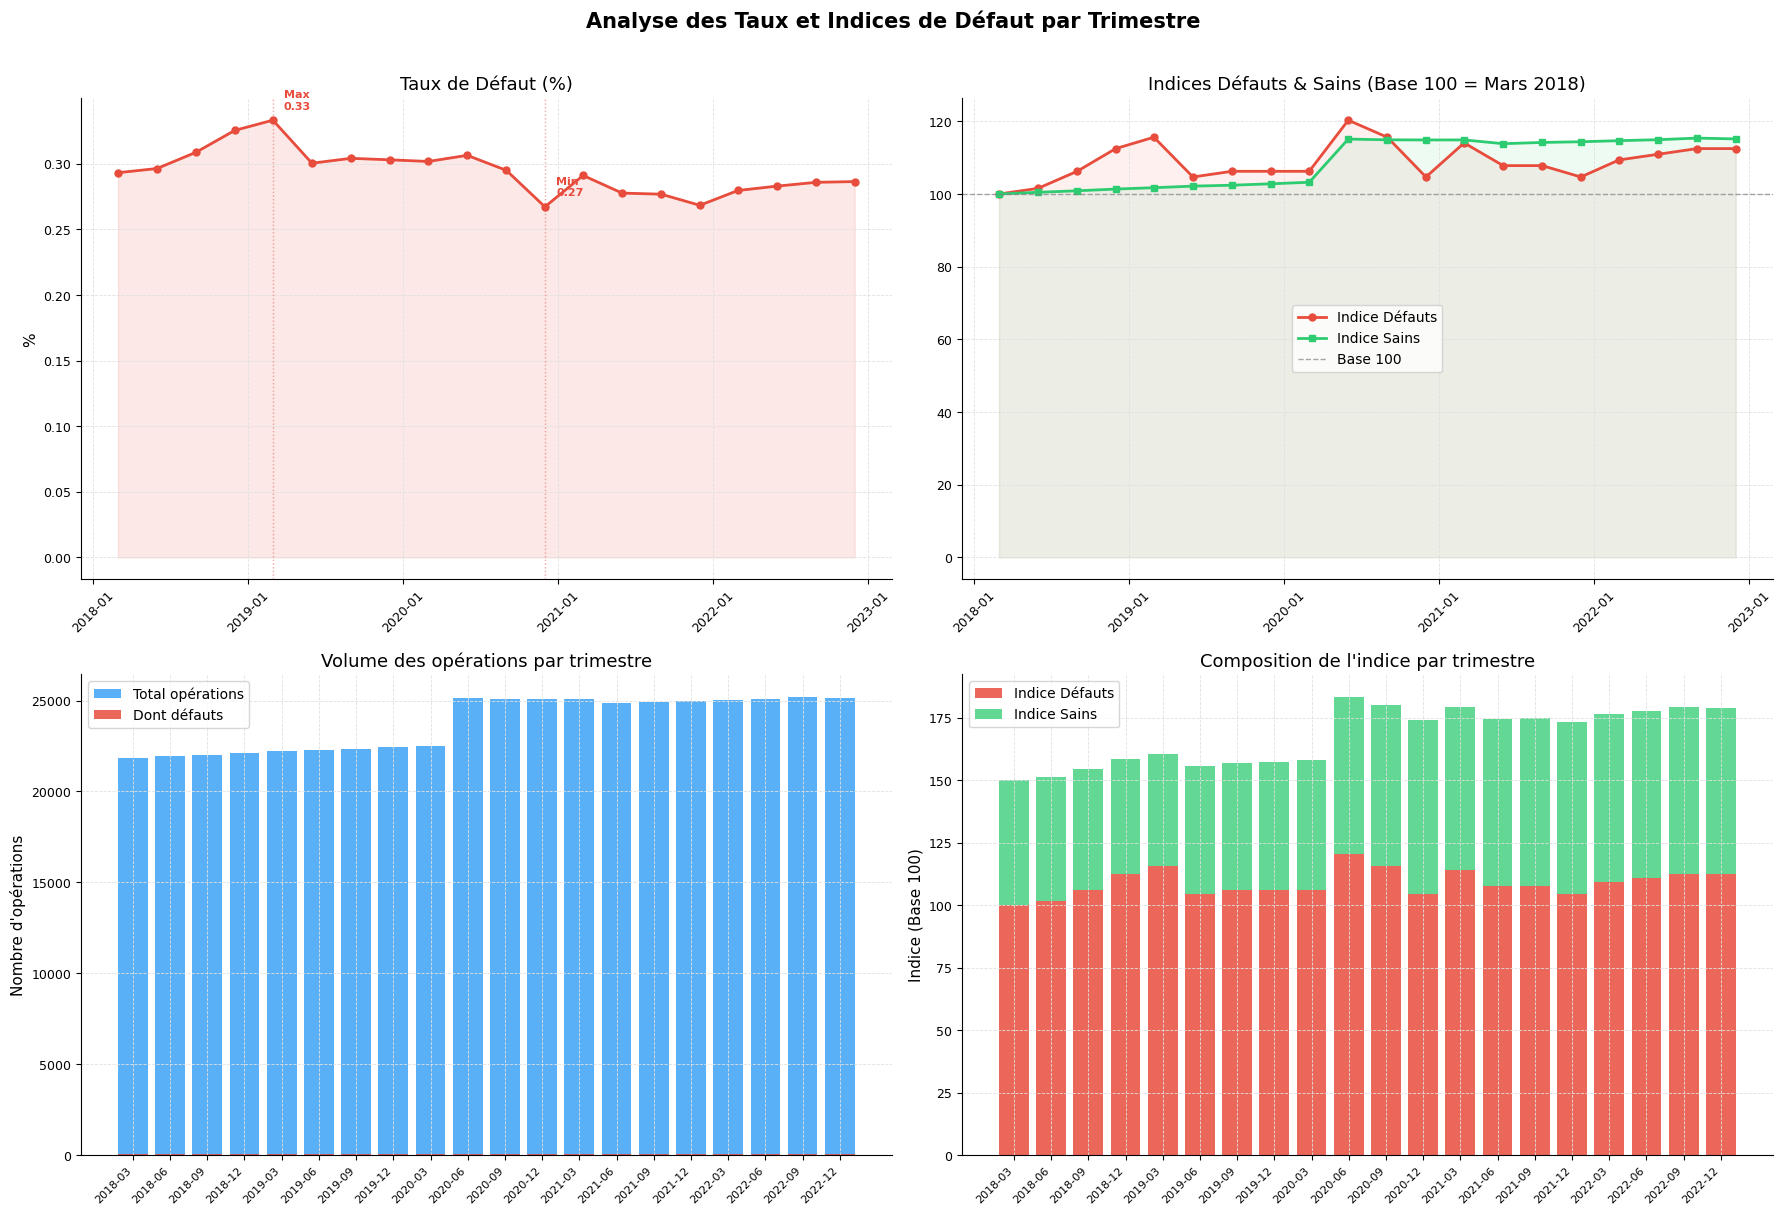

In [7]:
def _annotate_minmax(ax, dates, values, color):
    """Annote les points min/max sur un axe."""
    idx_max, idx_min = values.idxmax(), values.idxmin()
    for idx, marker, label in [(idx_max, '▲', 'Max'), (idx_min, '▼', 'Min')]:
        ax.axvline(dates[idx], color=color, linestyle=':', linewidth=1, alpha=0.5)
        ax.annotate(
            f"{label}\n{values[idx]:.2f}",
            xy=(dates[idx], values[idx]),
            xytext=(8, 8), textcoords='offset points',
            fontsize=8, color=color, fontweight='bold'
        )


fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analyse des Taux et Indices de Défaut par Trimestre',
             fontsize=15, fontweight='bold', y=1.01)

dates = df_grouped['Date']
taux  = df_grouped['Taux_Defaut'] * 100

# ── Graphique 1 : Taux de défaut ──────────────────────────────────────────────
ax1 = axes[0, 0]
ax1.plot(dates, taux, color=COLOR_DEFAUT, marker='o', linewidth=2, markersize=5)
ax1.fill_between(dates, taux, alpha=0.12, color=COLOR_DEFAUT)
_annotate_minmax(ax1, dates, taux, COLOR_DEFAUT)
ax1.set_title('Taux de Défaut (%)')
ax1.set_ylabel('%')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.tick_params(axis='x', rotation=45)

# ── Graphique 2 : Indice défauts vs sains ────────────────────────────────────
ax2 = axes[0, 1]
ax2.plot(dates, df_grouped['Indice_Defauts'], color=COLOR_DEFAUT, marker='o',
         linewidth=2, markersize=5, label='Indice Défauts')
ax2.plot(dates, df_grouped['Indice_Sains'],   color=COLOR_SAIN, marker='s',
         linewidth=2, markersize=5, label='Indice Sains')
ax2.axhline(100, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Base 100')
ax2.fill_between(dates, df_grouped['Indice_Defauts'], alpha=0.08, color=COLOR_DEFAUT)
ax2.fill_between(dates, df_grouped['Indice_Sains'],   alpha=0.08, color=COLOR_SAIN)
ax2.set_title('Indices Défauts & Sains (Base 100 = Mars 2018)')
ax2.legend()
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.tick_params(axis='x', rotation=45)

# ── Graphique 3 : Volume total des opérations ────────────────────────────────
ax3 = axes[1, 0]
ax3.bar(
    np.arange(len(df_grouped)), df_grouped['total_operations'],
    color=COLOR_NEUTRE, alpha=0.75, label='Total opérations'
)
ax3.bar(
    np.arange(len(df_grouped)), df_grouped['total_defauts'],
    color=COLOR_DEFAUT, alpha=0.85, label='Dont défauts'
)
ax3.set_xticks(np.arange(len(df_grouped)))
ax3.set_xticklabels([d.strftime('%Y-%m') for d in dates], rotation=45, ha='right', fontsize=8)
ax3.set_title('Volume des opérations par trimestre')
ax3.set_ylabel('Nombre d\'opérations')
ax3.legend()

# ── Graphique 4 : Indice défauts vs taux scalé ───────────────────────────────
ax4 = axes[1, 1]
x = np.arange(len(df_grouped))
diff = df_grouped['Indice_Sains'] - df_grouped['Taux_Defaut_Scaled']
ax4.bar(x, df_grouped['Indice_Defauts'], color=COLOR_DEFAUT,  alpha=0.85, label='Indice Défauts')
ax4.bar(x, diff, bottom=df_grouped['Indice_Defauts'], color=COLOR_SAIN, alpha=0.75, label='Indice Sains')
ax4.set_xticks(x)
ax4.set_xticklabels([d.strftime('%Y-%m') for d in dates], rotation=45, ha='right', fontsize=8)
ax4.set_title('Composition de l\'indice par trimestre')
ax4.set_ylabel('Indice (Base 100)')
ax4.legend()

fig.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/analyse_taux_defaut.png", bbox_inches='tight', dpi=150)
plt.show()

### 2.2 Statistiques descriptives

**Objectif** : comprendre la distribution des variables avant tout traitement. On distingue les variables **quantitatives continues** (traitées par statistiques de moments) et les variables **qualitatives/binaires** (traitées par tables de fréquences).

In [8]:
def is_discrete(serie: pd.Series, max_unique: int = 15) -> bool:
    """Retourne True si la série est discrète (entière avec peu de valeurs uniques)."""
    if not pd.api.types.is_numeric_dtype(serie):
        return False

    # Convertir en float pour éviter le mélange int/float
    vals = pd.to_numeric(serie, errors="coerce").dropna()

    # Cas vides
    if len(vals) == 0:
        return False

    # Vérifier que tous les nombres sont essentiellement entiers
    # Chaque valeur doit être égale à sa version entière
    are_integer = np.equal(vals, vals.astype(int))
    is_integer = pd.Series(are_integer, index=vals.index)

    return (
        is_integer.all()
        and serie.nunique() <= max_unique
    )

# Séparation des types de variables
EXCLUDE_META = {'IDENT_CLIENT', 'ARRETE', 'Date', 'DDefaut_NDB', 'CHR_V1_4_USAGE'}

obj_cols         = df.select_dtypes(include='object').columns.tolist()
binary_cols      = [c for c in df.columns if is_discrete(df[c]) and c not in EXCLUDE_META]
cat_bin_vars     = list(set(obj_cols) | set(binary_cols) - EXCLUDE_META)
numeric_vars_raw = [
    c for c in df.select_dtypes(include='number').columns
    if c not in EXCLUDE_META | set(cat_bin_vars)
]

print(f"Variables quantitatives continues : {len(numeric_vars_raw)}")
print(f"Variables qualitatives/binaires   : {len(cat_bin_vars)}")

# Statistiques descriptives sur les variables continues
df[numeric_vars_raw].describe().T.round(3)

Variables quantitatives continues : 90
Variables qualitatives/binaires   : 25


,count,mean,std,min,25%,50%,75%,max
ANCIENNETE,475147.0000,247.8340,156.0140,3.0000,103.0000,244.0000,375.0000,836.0000
CRTAD_AG_SOLDE_T,475147.0000,1948351.0380,6405220.5540,-1120327167.0000,169499.0000,509000.0000,1592333.0000,353689165.0000
CRTAD_AG_SOLDE_T1,475147.0000,1882147.7180,6237134.1700,-1108443333.0000,164000.0000,498666.0000,1542583.0000,353689165.0000
CRTAD_AG_SOLDE_T2,475147.0000,1838943.2280,6014492.6880,-1023747167.0000,159833.0000,492333.0000,1516666.0000,405978832.0000
CRTAD_AG_SOLDE_T3,475147.0000,1807521.9380,5794664.9940,-950373000.0000,153333.0000,487499.0000,1508500.0000,353689165.0000
...,...,...,...,...,...,...,...,...
impaye_T_Mm12,463484.0000,1.7440,111.6570,0.0000,0.0000,0.0000,0.0000,27335.0000
depassement_T_Mm1,475010.0000,255.8260,7767.1650,0.0000,0.0000,0.0000,40.0000,2780103.6000
depassement_T_Mm2,474618.0000,273.1380,9645.1280,0.0000,0.0000,0.0000,40.0000,2767362.8000
depassement_T_Mm3,473819.0000,268.9090,9558.6760,0.0000,0.0000,0.0000,39.0000,2780103.6000


In [9]:
# Statistiques descriptives sur les variables qualitatives/binaires
df_cat_bin = df[cat_bin_vars].copy()
df_cat_bin = df_cat_bin.astype('object')

cat_describe = df_cat_bin.describe(include='object').T
display(cat_describe)

,count,unique,top,freq
CODITDBDF_PAR,475147,2,0,474791
TOPCLILITIG,475147.0000,2.0000,0.0000,474683.0000
NDB_Mm4,470662.0000,2.0000,0.0000,470352.0000
Top_immo_ss_gar,475147.0000,2.0000,0.0000,455156.0000
couleur_irpar,475147,3,V,450548
top_assu_vie,475147.0000,2.0000,1.0000,241376.0000
NDB_Mm6,468274.0000,2.0000,0.0000,467907.0000
Top_immo_hyp,475147.0000,2.0000,0.0000,408079.0000
TOP_PRO,475147.0000,2.0000,0.0000,425858.0000
IND_DEPASSE_90J,475147,2,0,474147


#### Stabilité temporelle du taux de défaut par variable

**Concept** : pour chaque variable qualitative ou discrète, on trace l'évolution
dans le temps du **taux de défaut moyen par modalité**. Ce graphique répond à
deux questions simultanément :

1. **Pouvoir discriminant** : les modalités se séparent-elles bien sur l'axe Y ?
   Une variable où toutes les courbes se confondent n'apporte pas d'information.
2. **Stabilité temporelle** : les écarts entre modalités sont-ils stables d'un
   trimestre à l'autre ? Une variable instable (croisements fréquents de courbes)
   sera difficile à modéliser et à valider réglementairement.

**Intérêt métier** : cette analyse est le pendant graphique du test de stabilité(PSI). Elle permet d'écarter visuellement les variables bruitées avant même d'entrer dans la phase de sélection formelle.

In [10]:
# Cette fonction gère les deux cas d'usage : exploration tous-variables et focus sur les classes de risque (CHR).
def plot_evolution_taux_defaut(
    df: pd.DataFrame,
    cible: str,
    variables: list,
    date_col: str = 'Date',
    y_min: float = None,
    y_max: float = None,
    n_cols: int = 2,
    figsize_col: float = 10.0,
    figsize_row: float = 5.0,
    titre_prefixe: str = "Stabilité temporelle du taux de défaut",
    save_dir: str = None,
) -> None:
    """
    Trace l'évolution du taux de défaut moyen par modalité et par trimestre,
    pour une liste de variables qualitatives ou discrètes.

    Paramètres
    ----------
    df           : DataFrame contenant `cible`, `date_col` et toutes les variables
    cible        : variable binaire cible (ex. 'DDefaut_NDB')
    variables    : liste des variables qualitatives/discrètes à analyser
    date_col     : colonne de date (format datetime)
    y_min, y_max : bornes facultatives de l'axe Y (ex. 0, 0.03)
    n_cols       : nombre de colonnes dans la grille de sous-graphiques
    figsize_col  : largeur par colonne (pouces)
    figsize_row  : hauteur par ligne (pouces)
    titre_prefixe: préfixe du titre de chaque sous-graphique
    save_dir     : si renseigné, sauvegarde chaque figure dans ce dossier

    Notes
    -----
    - Les NaN dans les variables qualitatives sont remplacés par 'NR' (signal risque).
    - Les modalités sont triées pour une lecture cohérente de la légende.
    - Le thème graphique suit la palette définie en Section 0 (COLORS).
    """
    # Travail sur une copie pour ne pas altérer le DataFrame source
    df_plot = df[[date_col, cible] + variables].copy()

    # Remplacement des NaN par la modalité 'NR'
    for var in variables:
        df_plot[var] = df_plot[var].fillna('NR').astype(str)

    n_plots = len(variables)
    n_rows  = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(figsize_col * n_cols, figsize_row * n_rows)
    )
    # Garantir que axes est toujours un tableau 1D
    axes = np.array(axes).flatten()

    for idx, var in enumerate(variables):
        ax = axes[idx]

        # Taux de défaut moyen par (date, modalité)
        agg = (
            df_plot.groupby([date_col, var])[cible]
            .mean()
            .reset_index()
            .rename(columns={cible: 'Taux_Defaut'})
            .sort_values([date_col, var])
        )

        modalites = sorted(agg[var].unique())

        for i, mod in enumerate(modalites):
            color  = COLORS[i % len(COLORS)]
            subset = agg[agg[var] == mod]

            ax.plot(
                subset[date_col],
                subset['Taux_Defaut'],
                color=color,
                marker='o',
                linewidth=2,
                markersize=5,
                label=str(mod),
            )
            ax.fill_between(
                subset[date_col],
                subset['Taux_Defaut'],
                alpha=0.06,
                color=color,
            )

        # Mise en forme
        ax.set_title(f"{titre_prefixe} — {var}", fontsize=11, fontweight='bold')
        ax.set_xlabel('Date')
        ax.set_ylabel('Taux de défaut moyen')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.legend(title=var, fontsize=8, title_fontsize=8)

        if y_min is not None:
            ax.set_ylim(bottom=y_min)
        if y_max is not None:
            ax.set_ylim(top=y_max)

    # Suppression des sous-graphiques vides
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.tight_layout()

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        fname = os.path.join(save_dir, f"stabilite_{cible}_{'_'.join(variables[:3])}.png")
        fig.savefig(fname, bbox_inches='tight', dpi=150)
        print(f"Figure sauvegardée → {fname}")

    plt.show()

In [11]:
# # Variable Categorielle
# plot_evolution_taux_defaut(
#     df       = df,
#     cible    = 'DDefaut_NDB',
#     variables= cat_bin_vars,
#     date_col = 'Date',
#     y_min    = 0,
#     y_max    = 0.03,
#     titre_prefixe = "Stabilité-Variables categorielle",
#     save_dir = OUTPUT_DIR,
# )

In [12]:
# # Variables quantitatives
# plot_evolution_taux_defaut(
#     df       = df,
#     cible    = 'DDefaut_NDB',
#     variables= numeric_vars_raw,
#     date_col = 'Date',
#     y_min    = 0,
#     y_max    = 0.03,
#     titre_prefixe = "Stabilité-Variables Quantitatives",
#     save_dir = OUTPUT_DIR,
# )

## Section 3-Prétraitement & Feature Engineering

### 3.1 Analyse et gestion des valeurs manquantes

**Concept** : les valeurs manquantes dans un modèle de risque peuvent être **informationnelles** (l'absence d'information est elle-même un signal de risque) ou **accidentelles** (données non collectées). La stratégie retenue diffère selon les cas :
- Variables continues : création d'un indicateur binaire `NR` (Non Renseigné) et imputation
- Variables qualitatives : remplacement par la modalité `'NR'`

**Intérêt métier** : préserver le signal risque lié à l'absence d'information tout en permettant l'utilisation dans un modèle paramétrique.

In [13]:
# ── Analyse globale des valeurs manquantes ────────────────────────────────────
missing = (
    pd.DataFrame({
        'N_Manquants'  : df.isna().sum(),
        'Pct_Manquants': (df.isna().mean() * 100).round(2)
    })
    .query('N_Manquants > 0')
    .sort_values('Pct_Manquants', ascending=False)
)

cols_with_missing = missing.index.tolist()
print(f"{len(cols_with_missing)} variables présentent des valeurs manquantes.")
display(missing)

27 variables présentent des valeurs manquantes.


,N_Manquants,Pct_Manquants
nbjdpls_T,374352,78.7900
CODITDBDF_PAR_Am1,14568,3.0700
CODACVPRO_modif_Am1,14568,3.0700
NDB_Mm12,14568,3.0700
CRTAD_AG_SOLDE_IND_0009_Am1,14568,3.0700
CAPDU_Am1,14568,3.0700
ENGAGEMENT_Am1,14568,3.0700
CRTOC_IND_0301_Am1,14568,3.0700
MNTPLV_Am1,14599,3.0700
CRTOC_IND_0164_Am1,14568,3.0700


In [14]:
def preprocess_missing(
    df: pd.DataFrame,
    cols_with_missing: list,
    cat_bin_vars: list,
    exclude: set = None
) -> tuple[pd.DataFrame, list, list]:
    """
    Stratégie de traitement des valeurs manquantes :
    - Variables numériques continues : création de la modalité 'NR', valeur numérique intacte
    - Variables qualitatives/binaires : remplacement par la modalité 'NR'

    Retourne :
        df2          : DataFrame traité
        numeric_vars : liste des indicateurs NR créés pour les numériques
        qualit_vars  : liste des variables qualitatives traitées
    """
    exclude = exclude or set()
    df2 = df.copy()

    qualit_set = set(cat_bin_vars)
    numeric_indicators = []
    qualit_vars = []

    for col in cols_with_missing:
        if col in exclude:
            continue
        if col in qualit_set:
            df2[col] = df2[col].fillna('NR').astype(str)
            qualit_vars.append(col)
        else:
            indicator_col = f"{col}_NR"
            df2[indicator_col] = df2[col].isna().astype(int)
            df2[col] = df2[col].fillna(df2[col].median())
            numeric_indicators.append(indicator_col)

    return df2, numeric_indicators, qualit_vars


df_prep, numeric_indicators, qualit_vars_prep = preprocess_missing(
    df=df[["Date", "DDefaut_NDB"] + cols_with_missing],
    cols_with_missing=cols_with_missing,
    cat_bin_vars=cat_bin_vars,
    exclude=EXCLUDE_META
)

print(f"Indicateurs NR créés : {len(numeric_indicators)}")
print(f"Variables qualit. traitées : {len(qualit_vars_prep)}")

Indicateurs NR créés : 19
Variables qualit. traitées : 8


### 3.2 Détection des valeurs aberrantes-Méthode IQR

**Concept** : la méthode des intervalles interquartiles (IQR) est préférée au z-score pour les données de risque de crédit, car elle est robuste à la non-normalité des distributions (skewness, queue lourde) qui caractérisent la plupart des variables financières.

**Formule** : une observation $x_i$ est aberrante si $x_i < Q_1 - 1.5 \times IQR$ ou $x_i > Q_3 + 1.5 \times IQR$.

**Intérêt métier** : les outliers peuvent biaiser les seuils de discrétisation (arbres) et gonfler artificiellement certains coefficients. On les documente avant de décider de leur traitement (winsorisation, exclusion, indicateur binaire).

In [15]:
def detection_outliers_iqr(
    df: pd.DataFrame,
    numeric_vars: list,
    seuil_pct: float = 10.0,
    exclude_missing: bool = True
) -> pd.DataFrame:
    """
    Calcule le pourcentage de valeurs aberrantes par variable selon la méthode IQR.

    Paramètres :
        df             : DataFrame source
        numeric_vars   : liste des variables à analyser
        seuil_pct      : seuil d'alerte (% d'outliers, défaut 10%)
        exclude_missing: si True, exclut les NaN et les NR avant calcul

    Retourne un DataFrame trié par proportion décroissante d'outliers.
    """
    resultats = {}

    for col in numeric_vars:
        serie = df[col].dropna()
        if exclude_missing:
            serie = serie[serie != 0] if serie.min() == 0 else serie

        if len(serie) < 4:
            resultats[col] = np.nan
            continue

        q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
        iqr    = q3 - q1
        lb, ub = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out  = ((serie < lb) | (serie > ub)).sum()
        resultats[col] = round(n_out / len(serie) * 100, 2)

    out_df = (
        pd.DataFrame.from_dict(resultats, orient='index',
                               columns=['Pct_Outliers_IQR'])
        .dropna()
        .sort_values('Pct_Outliers_IQR', ascending=False)
    )
    out_df['Alerte'] = out_df['Pct_Outliers_IQR'] > seuil_pct
    return out_df


outliers_df = detection_outliers_iqr(df, numeric_vars_raw, seuil_pct=10.0)

n_alerte = outliers_df['Alerte'].sum()
print(f"Variables en alerte (>10% outliers IQR) : {n_alerte}")
display(outliers_df[outliers_df['Alerte']].sample(20))

Variables en alerte (>10% outliers IQR) : 33


,Pct_Outliers_IQR,Alerte
CRTAD_AG_SOLDE_IND_0009,12.1300,True
CRTAD_AG_SOLDE_IND_0009_Am1,11.9000,True
CRTAD_AG_SOLDE_T4,12.4300,True
CRTAD_AG_SOLDE_T,12.5700,True
arrieres_T,12.7700,True
HORSBILAN,15.1700,True
MNTPLV,10.4600,True
MNTECRCRD,11.0500,True
CRTAT_IND_0205,11.0100,True
MNTECRDBT,10.6100,True


### 3.3 Modalités rares des variables qualitatives

**Concept** : une modalité est dite **rare** lorsqu'elle représente moins de 5% des observations. Les modalités rares doivent être identifiées pour deux raisons :
1. Elles peuvent conduire à des estimations instables du taux de défaut.
2. Elles peuvent poser des problèmes lors de la construction des tables de contingence (test du χ²).

**Traitement recommandé** : regroupement avec une modalité proche (sémantique ou proximité du taux de défaut).

In [16]:
def detection_modalites_rares(
    df: pd.DataFrame,
    vars_discretes: list,
    seuil: float = 0.05,
    exclude: set = None
) -> dict:
    """
    Identifie les modalités rares (fréquence < seuil) dans les variables qualitatives.

    Retourne un dictionnaire {variable: DataFrame de modalités rares}.
    """
    exclude = exclude or {'DDefaut_NDB'}
    resultats = {}

    for col in vars_discretes:
        if col in exclude:
            continue
        freq = df[col].value_counts(normalize=True)
        rares = freq[freq < seuil]
        if not rares.empty:
            resultats[col] = rares.reset_index().rename(
                columns={col: 'Modalite', 'proportion': 'Frequence'}
            )
    return resultats


modalites_rares = detection_modalites_rares(df, cat_bin_vars)
print(f"{len(modalites_rares)} variables présentent des modalités rares (<5%).")

# Affichage des 5 premières
for var, df_rare in list(modalites_rares.items())[:5]:
    print(f"\n── {var} ──")
    display(df_rare)

17 variables présentent des modalités rares (<5%).

── CODITDBDF_PAR ──


,Modalite,Frequence
0,2,0.0007



── TOPCLILITIG ──


,Modalite,Frequence
0,1.0000,0.0010



── NDB_Mm4 ──


,Modalite,Frequence
0,1.0000,0.0007



── Top_immo_ss_gar ──


,Modalite,Frequence
0,1.0000,0.0421



── couleur_irpar ──


,Modalite,Frequence
0,O,0.0432
1,R,0.0086


### 3.4 Discrétisation des variables continues par arbres de décision

**Concept** : la discrétisation par arbre de régression (profondeur 2) est une méthode supervisée qui détermine les seuils de découpage d'une variable continue de façon à **maximiser la séparation entre défauts et sains**. Elle est préférée aux approches non supervisées (quantiles, égale largeur) car elle optimise directement la relation avec la variable cible.

**Résultat** : chaque variable continue `X` est transformée en une variable binaire `X_level1` (indicateur du premier seuil) exportée dans un fichier Excel de référence.

In [17]:
# ── Corrections spécifiques ────────────────────────────────────────────────────
# Modalité 'NR' remplacée par 0 pour les variables de découvert
for col in ['NDB_Mm4', 'NDB_Mm6', 'NDB_Mm12']:
    if col in df.columns:
        df[col] = df[col].replace('NR', 0.0).astype(float)
        #df[col] = df[col].fillna(0.0)

# Indicateur binaire usage compte courant
df['CHR_V1_4_USAGE_bin'] = np.where(df['CHR_V1_4_USAGE'] <= 4.5, 0, 1)


# ── Découpage temporel ────────────────────────────────────────────────────────
DATE_COUPURE = '2022-03'

mask_train = df['Date'] < DATE_COUPURE
X = df[mask_train].drop(columns='DDefaut_NDB')
y = df[mask_train]['DDefaut_NDB'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [18]:
def discretiser_par_arbre(
    df: pd.DataFrame,
    target: str,
    quantitative_vars: list,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    output_excel: str = "output/Seuils_Discretisation.xlsx"
) -> tuple[pd.DataFrame, dict]:
    """
    Discrétise les variables continues par arbre de décision (profondeur 2).

    Pour chaque variable :
    - Entraîne un DecisionTreeClassifier(max_depth=2)
    - Extrait les seuils de coupure
    - Calcule AUC et PPS
    - Crée les indicateurs binaires _level1, _level2

    Retourne :
        df_enrichi : DataFrame avec les nouvelles variables discrétisées
        seuils     : dictionnaire {variable: [seuil1, seuil2]}
    """
    wb = Workbook()
    ws = wb.active
    ws.title = "Seuils Discretisation"
    ws.append(["Variable", "AUC", "PPS", "Seuil_1", "Seuil_2"])

    df_enrichi = df.copy()
    seuils = {}

    for var in quantitative_vars:
        if var not in X_train.columns:
            continue
        try:
            X_var = X_train[[var]].dropna()
            y_var = y_train.loc[X_var.index]

            # Arbre de décision supervisé
            tree = DecisionTreeClassifier(max_depth=2, random_state=42)
            tree.fit(X_var, y_var)

            # Seuils extraits de l'arbre
            thresholds = sorted(set(
                t for t in tree.tree_.threshold if t != -2
            ))
            seuil1 = thresholds[0] if len(thresholds) > 0 else None
            seuil2 = thresholds[1] if len(thresholds) > 1 else None

            # AUC univariée
            proba = tree.predict_proba(X_var)[:, 1]
            fpr, tpr, _ = roc_curve(y_var, proba)
            auc_val = round(auc(fpr, tpr), 4)

            # PPS
            pps_tmp = df[[var, target]].dropna()
            pps_val = pps.score(pps_tmp, var, target)['ppscore']

            # Création des indicateurs binaires
            if seuil1 is not None:
                df_enrichi[f"{var}_level1"] = (df_enrichi[var] <= seuil1).astype(int)
            if seuil2 is not None:
                df_enrichi[f"{var}_level2"] = (df_enrichi[var] <= seuil2).astype(int)

            seuils[var] = [seuil1, seuil2]
            ws.append([var, auc_val, round(pps_val, 4), seuil1, seuil2])

        except Exception as e:
            print(f"{var} ignoré : {e}")

    wb.save(output_excel)
    print(f"Seuils sauvegardés dans {output_excel}")
    return df_enrichi, seuils

In [19]:
df_enrichi,seuils = discretiser_par_arbre(df,"DDefaut_NDB",numeric_vars_raw,X_train,y_train)
df_enrichi.to_csv(f"{OUTPUT_DIR}/Base_Modele_PD_Enrichie.csv", index=False, encoding="utf-8", sep=",")

Seuils sauvegardés dans output/Seuils_Discretisation.xlsx


## Section 4-Sélection des Variables

### 4.0-Weight of Evidence (WOE) et Information Value (IV)

**Concept** : le WOE et l'IV sont deux mesures complémentaires issues du
cadre log-odds, standard dans la modélisation scorecard depuis les années 1980.

**Weight of Evidence (WOE)** mesure la séparation locale entre défauts et sains
pour chaque modalité d'une variable :

$$WOE_j = \ln\left(\frac{\text{Distr. Défauts}_j}{\text{Distr. Sains}_j}\right)
= \ln\left(\frac{n_{D,j} / N_D}{n_{S,j} / N_S}\right)$$

- $WOE_j > 0$ : la modalité est sur-représentée chez les défauts
- $WOE_j < 0$ : la modalité est sur-représentée chez les sains
- $WOE_j = 0$ : la modalité ne discrimine pas

**Information Value (IV)** agrège le pouvoir discriminant de l'ensemble des
modalités d'une variable :

$$IV = \sum_j \left(\frac{n_{D,j}}{N_D} - \frac{n_{S,j}}{N_S}\right)
\times WOE_j$$

**Règle de décision standard** (Anderson, 2007 ; Siddiqi, 2006) :

| IV | Pouvoir discriminant |
|---|---|
| < 0.02 | Inutile |
| [0.02, 0.10[ | Faible |
| [0.10, 0.30[ | Moyen |
| [0.30, 0.50[ | Fort |
| ≥ 0.50 | Suspicieux (surapprentissage potentiel) |

**Intérêt métier** :
- Le WOE transforme les variables en une échelle log-odds commune,
  ce qui les rend directement comparables entre elles.
- L'IV permet de **classer les variables par pouvoir discriminant**
  avant la modélisation, réduisant efficacement la dimensionnalité.
- Contrairement au chi² ou au V de Cramér, l'IV tient compte à la fois
  de la séparation (WOE) et du poids de chaque modalité dans la population.

> **Référence** : Anderson, R. (2007), *The Credit Scoring Toolkit*,
> Oxford University Press, Module C — équation de l'IV comme distance
> de Kullback-Leibler entre distributions de défauts et de sains.

CLASSEMENT DES VARIABLES PAR INFORMATION VALUE (IV)


,Variable,IV,Interpretation,N_Modalites
0,couleur_irpar,1.7311,Suspicieux,3
1,TOP_DP,1.3808,Suspicieux,5
2,TOPLS,0.8196,Suspicieux,4
3,TOPCLILITIG,0.7847,Suspicieux,2
4,seuils_abs_rel_arrieres_T,0.6529,Suspicieux,2
5,CODITDBDF_PAR,0.1597,Moyen,2
6,NDB_Mm12,0.1190,Moyen,2
7,NDB_Mm4,0.0989,Faible,2
8,NDB_Mm6,0.0926,Faible,2
9,CODITDBDF_PAR_Am1,0.0907,Faible,2



Détail WOE par (variable, modalité) :


,Variable,Modalite,N_Total,N_Defauts,N_Sains,Pct_Population,Taux_Defaut_Pct,Distr_Defauts,Distr_Sains,WOE,IV_Contribution
0,CODITDBDF_PAR,0,262126,747,261379,99.9300,0.2850,0.9614,0.9994,-0.0388,0.0015
1,CODITDBDF_PAR,2,187,30,157,0.0700,16.0428,0.0386,0.0006,4.1638,0.1583
2,TOPCLILITIG,0.0000,262049,668,261381,99.9000,0.2549,0.8597,0.9994,-0.1506,0.0210
3,TOPCLILITIG,1.0000,264,109,155,0.1000,41.2879,0.1403,0.0006,5.4668,0.7637
4,NDB_Mm4,0.0000,259650,740,258910,98.9800,0.2850,0.9524,0.9900,-0.0387,0.0015
5,NDB_Mm4,1.0000,161,20,141,0.0600,12.4224,0.0257,0.0005,3.8659,0.0974
6,Top_immo_ss_gar,0.0000,251040,746,250294,95.7000,0.2972,0.9601,0.9570,0.0032,0.0000
7,Top_immo_ss_gar,1.0000,11273,31,11242,4.3000,0.2750,0.0399,0.0430,-0.0745,0.0002
8,couleur_irpar,O,11308,219,11089,4.3100,1.9367,0.2819,0.0424,1.8942,0.4536
9,couleur_irpar,R,2229,206,2023,0.8500,9.2418,0.2651,0.0077,3.5344,0.9097


xportés → output/WOE_detail.csv et IV_synthese.csv


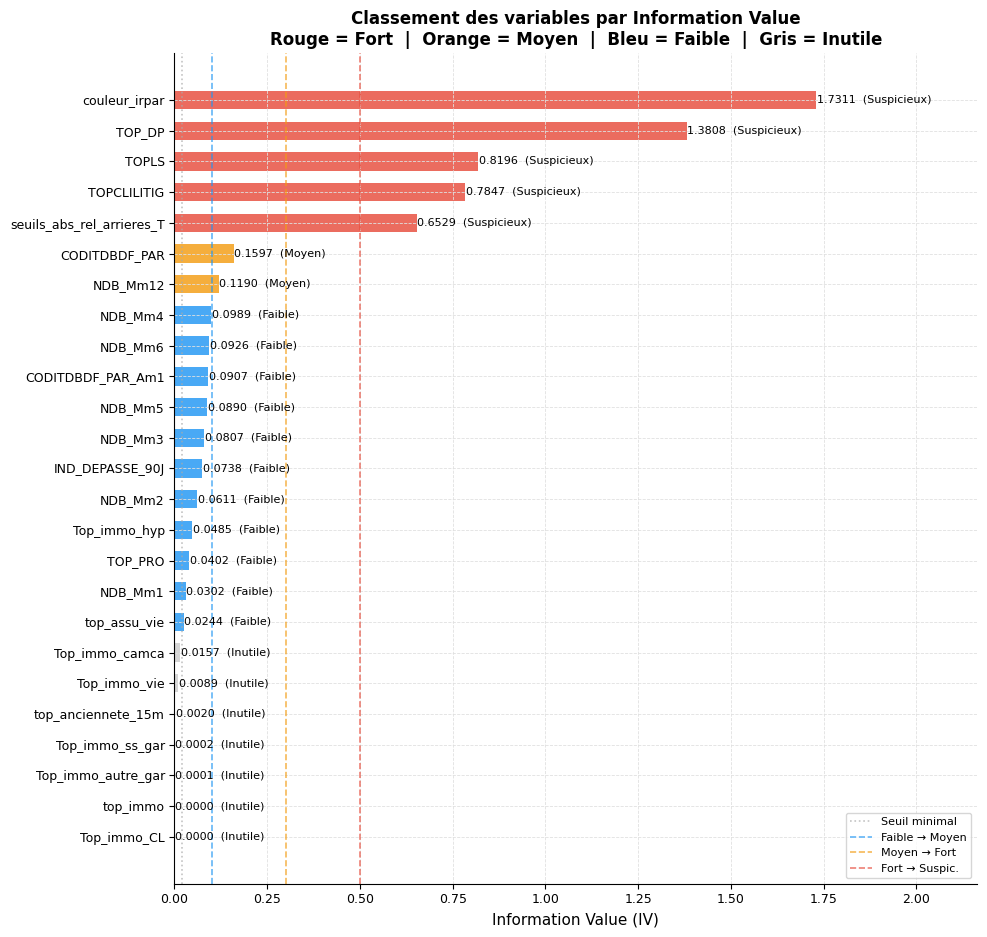

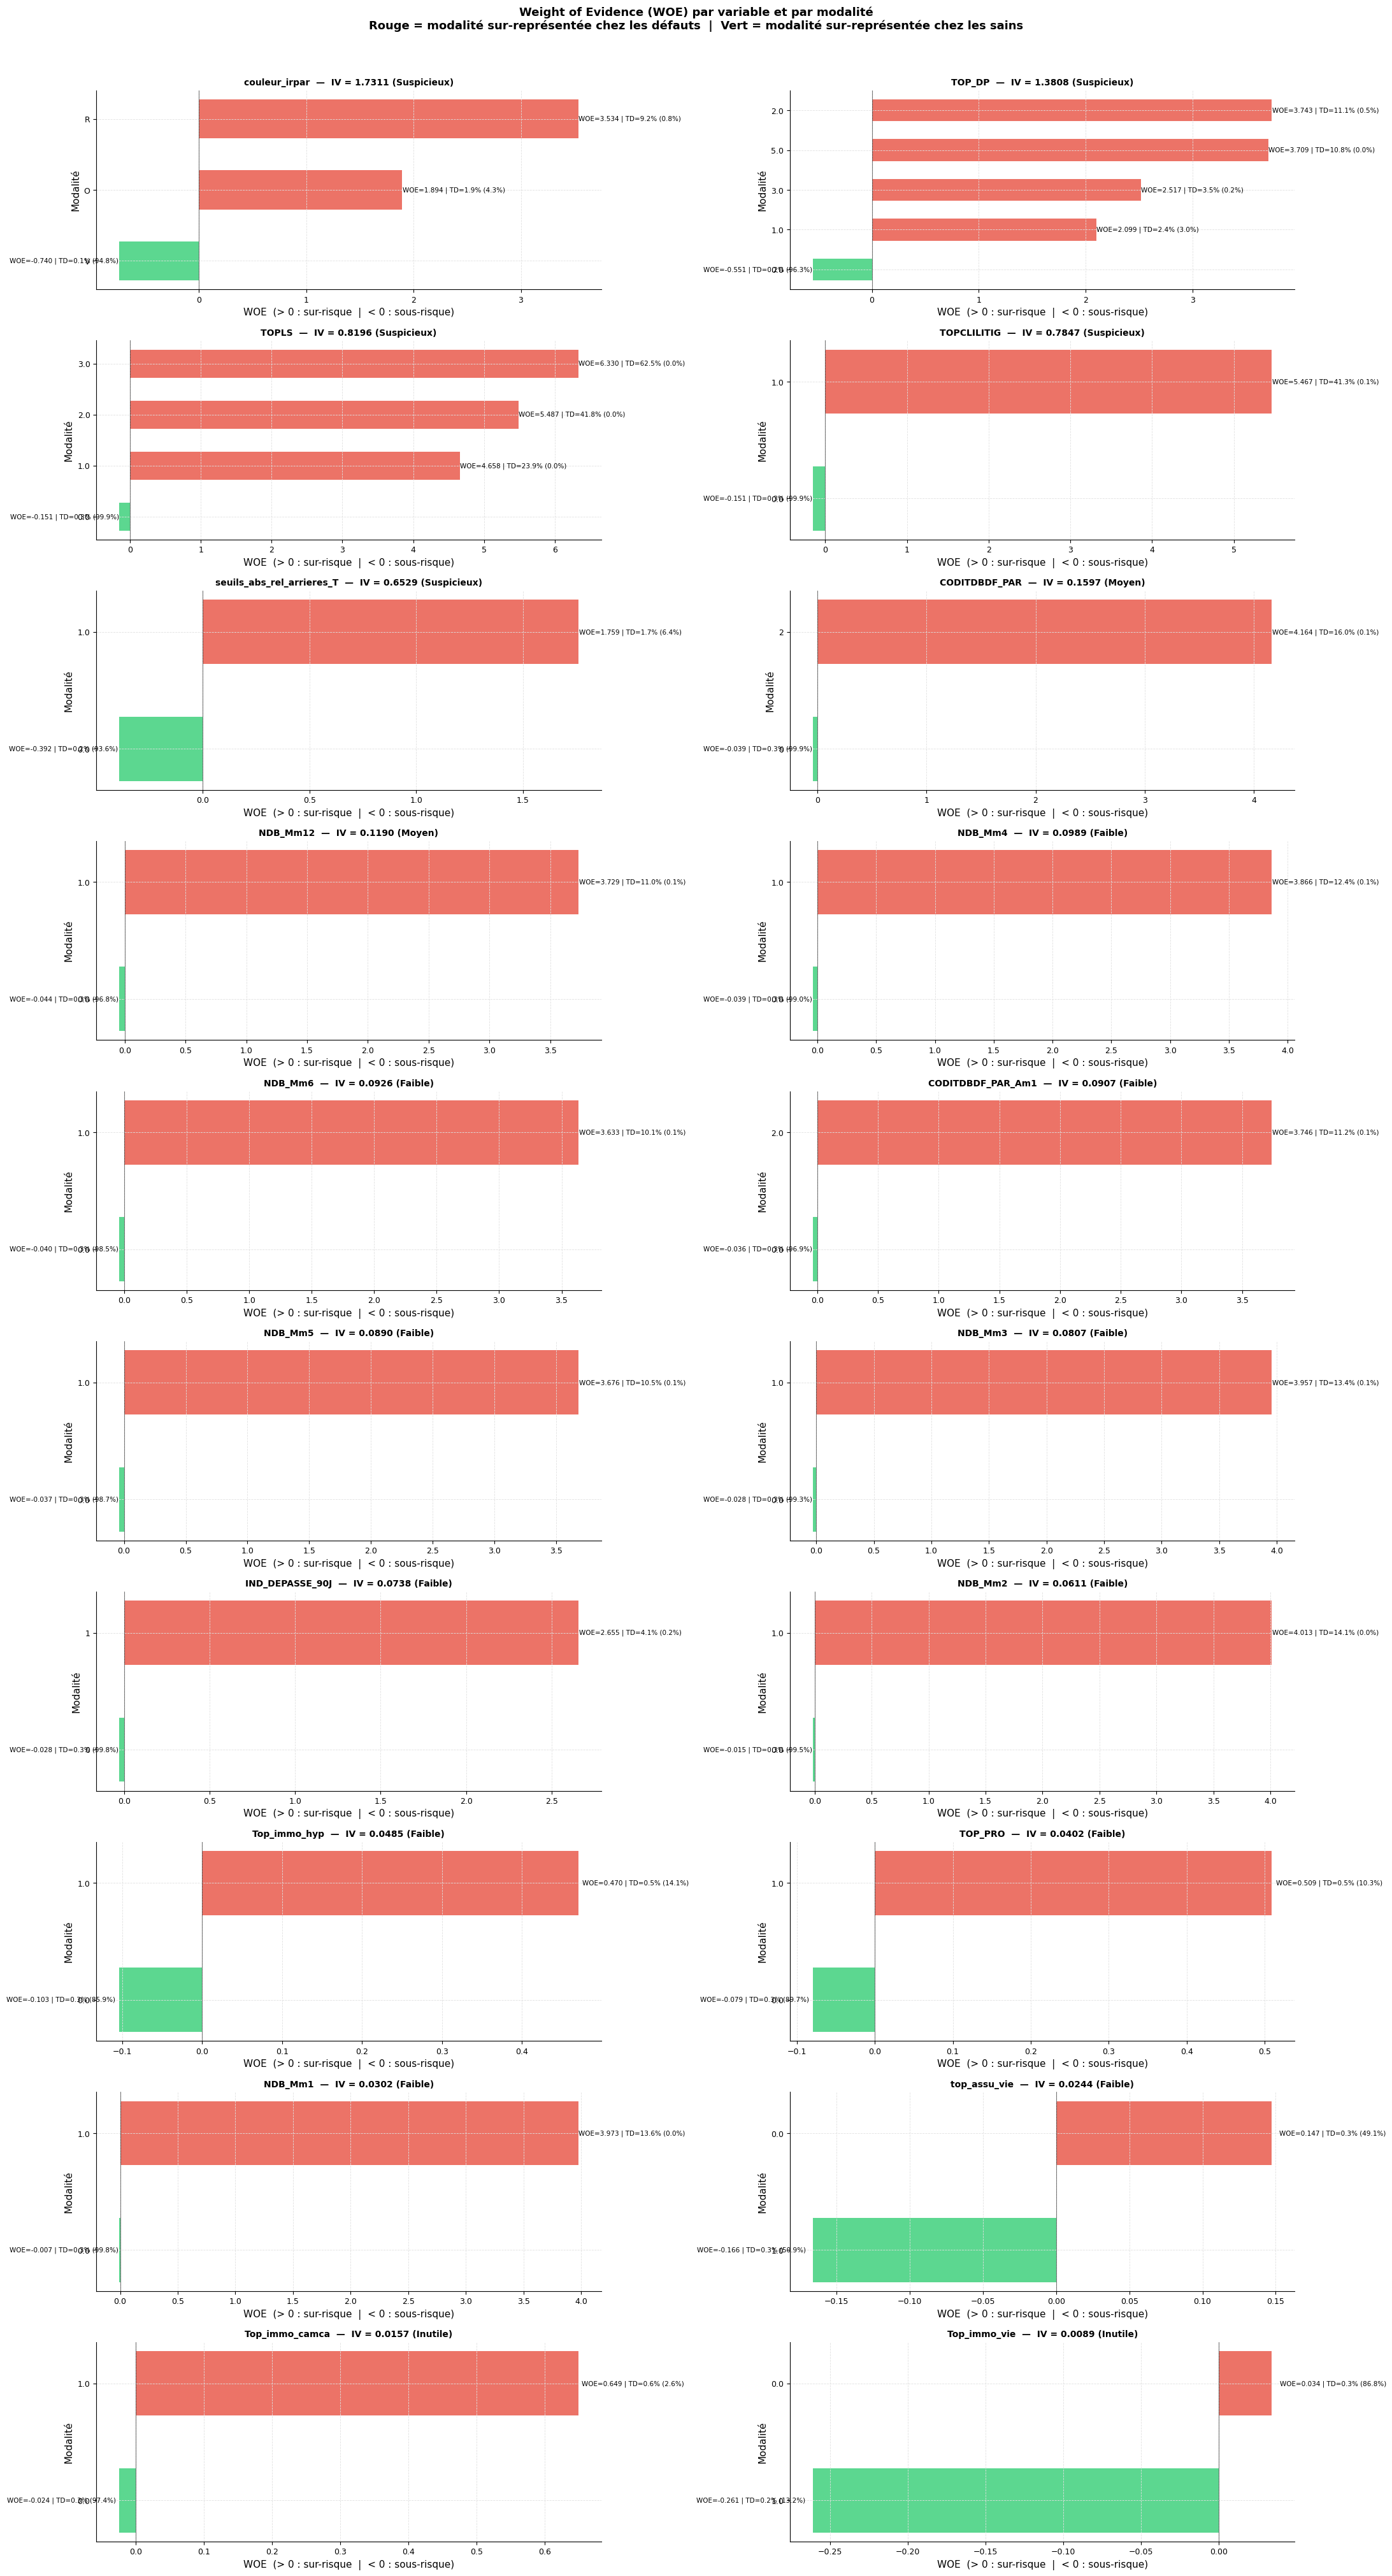

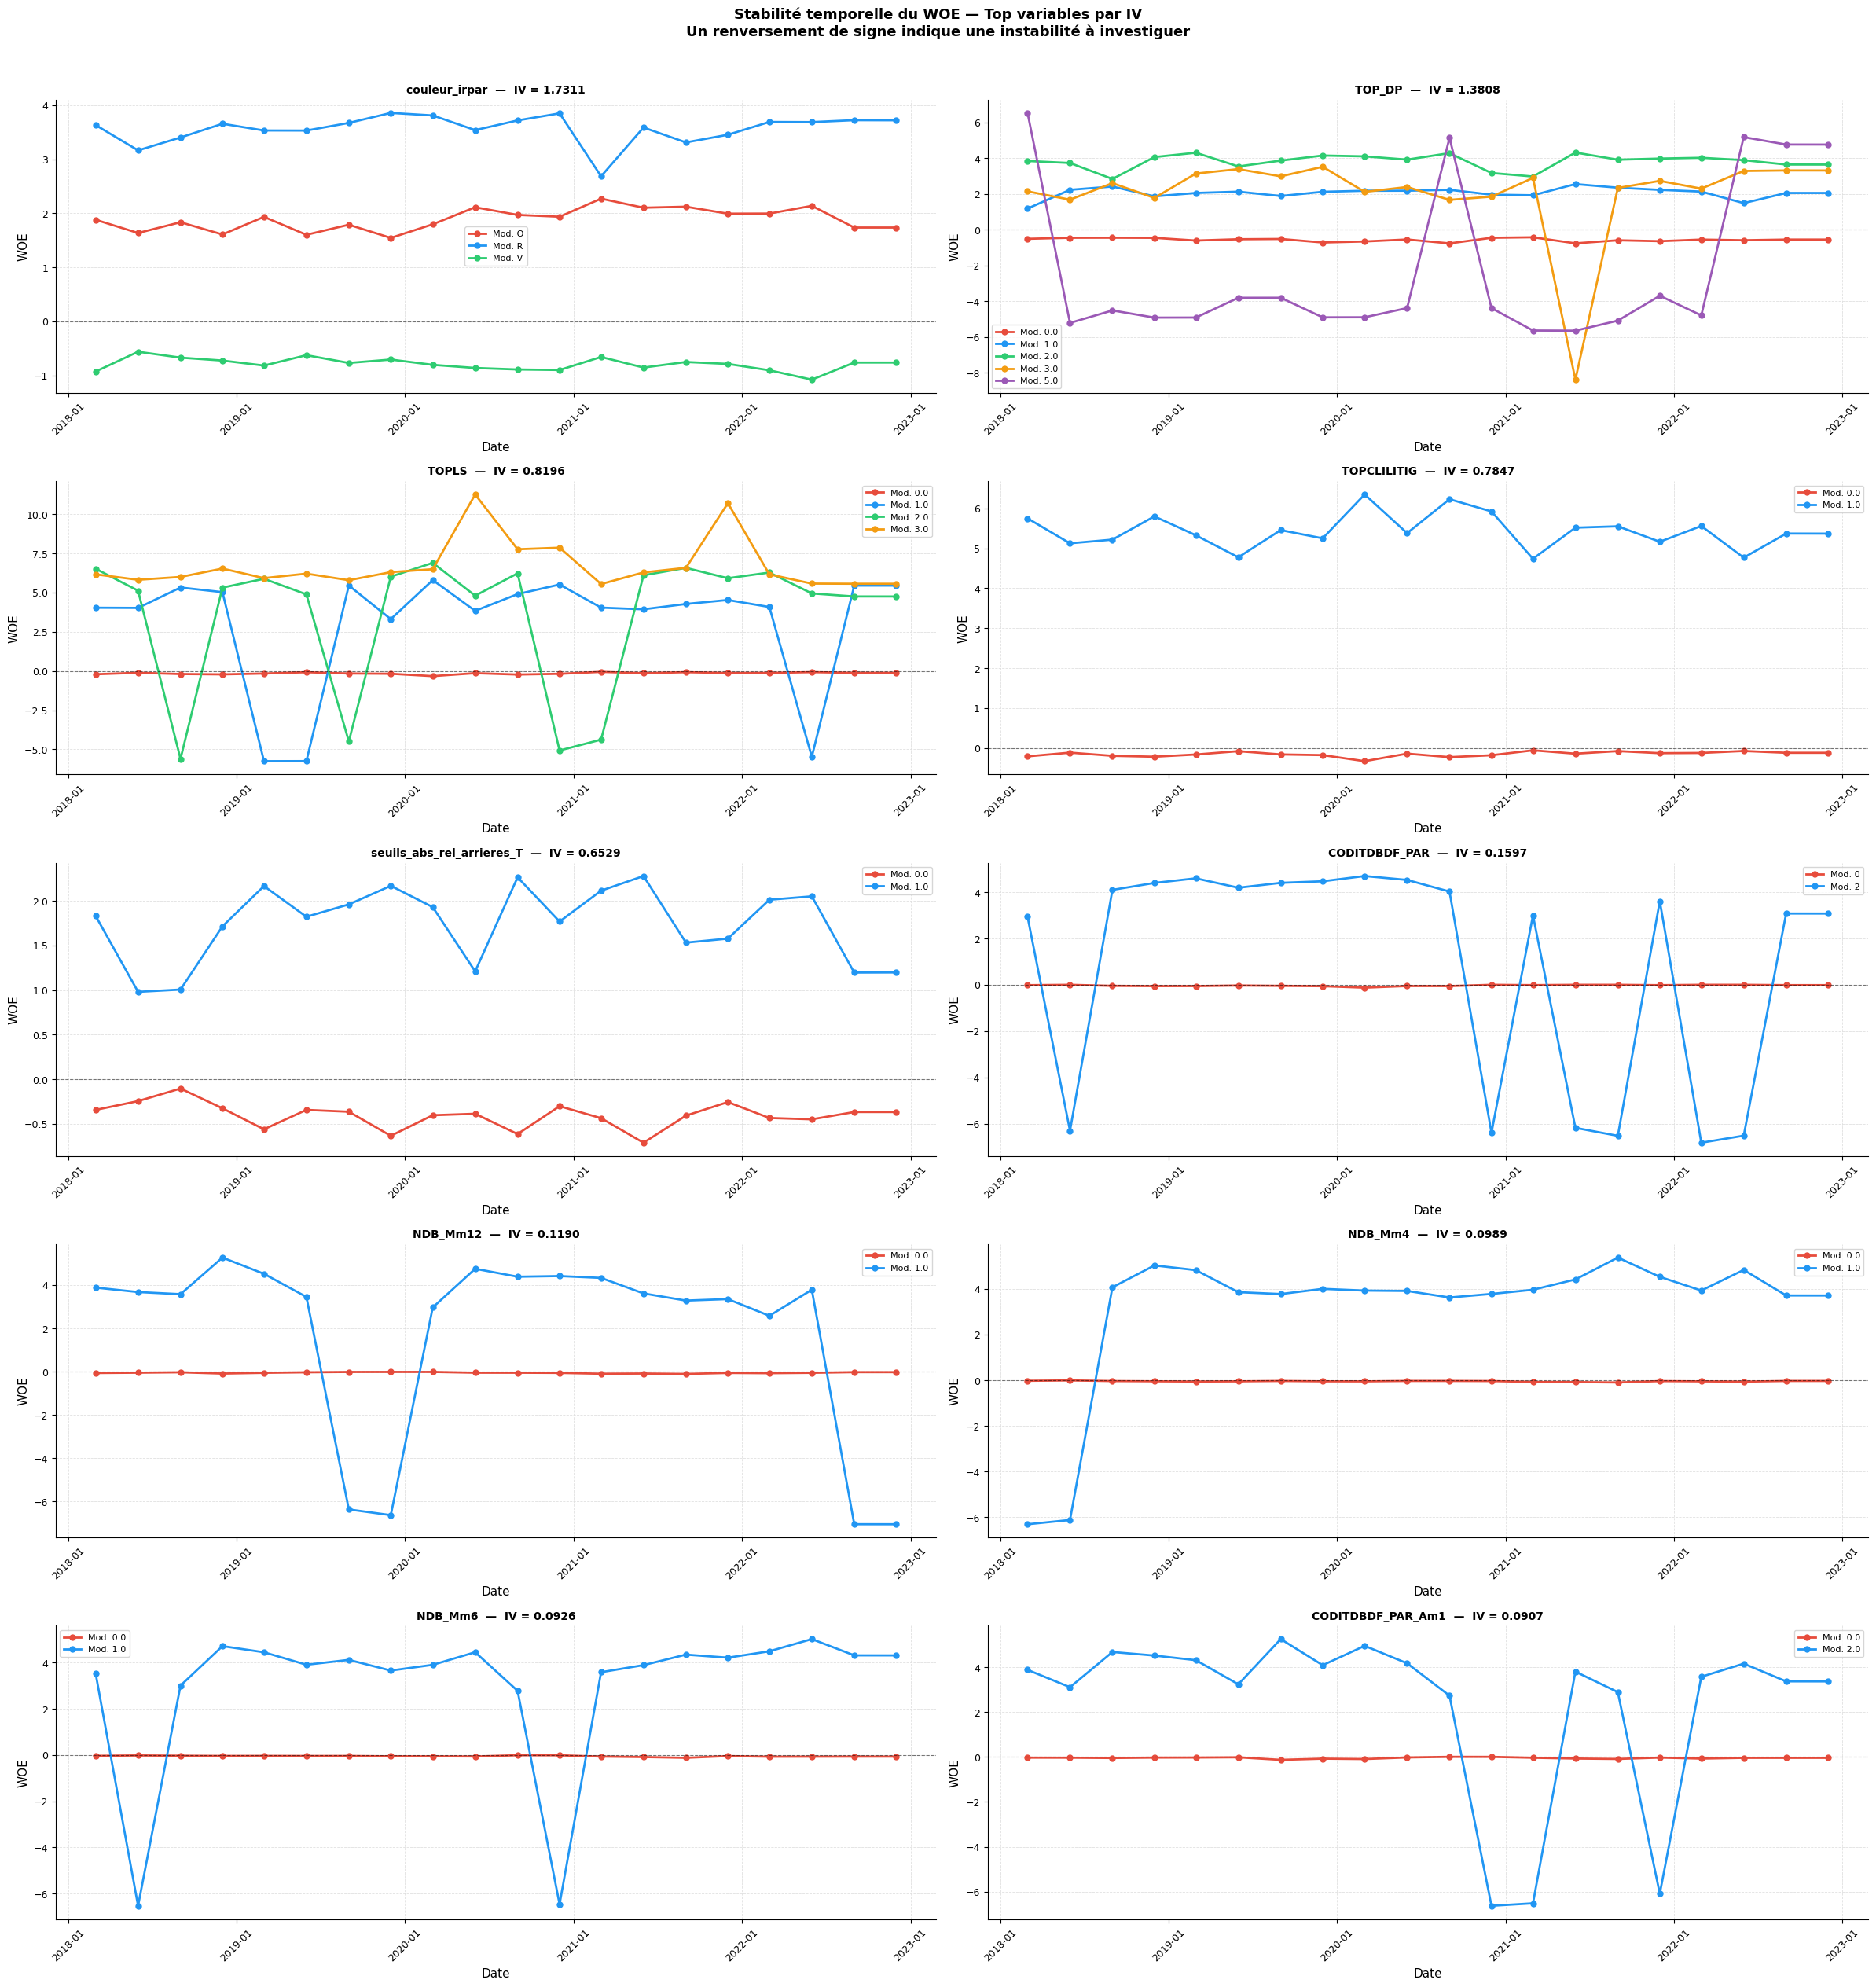

DÉCISION — Seuil IV ≥ 0.02

Variables retenues : 18
couleur_irpar                                 IV = 1.7311  (Suspicieux)
TOP_DP                                        IV = 1.3808  (Suspicieux)
TOPLS                                         IV = 0.8196  (Suspicieux)
TOPCLILITIG                                   IV = 0.7847  (Suspicieux)
seuils_abs_rel_arrieres_T                     IV = 0.6529  (Suspicieux)
CODITDBDF_PAR                                 IV = 0.1597  (Moyen)
NDB_Mm12                                      IV = 0.1190  (Moyen)
NDB_Mm4                                       IV = 0.0989  (Faible)
NDB_Mm6                                       IV = 0.0926  (Faible)
CODITDBDF_PAR_Am1                             IV = 0.0907  (Faible)
NDB_Mm5                                       IV = 0.0890  (Faible)
NDB_Mm3                                       IV = 0.0807  (Faible)
IND_DEPASSE_90J                               IV = 0.0738  (Faible)
NDB_Mm2                                       

In [20]:
# ═══════════════════════════════════════════════════════════════════════════════
# WOE & IV — Weight of Evidence et Information Value
# Étapes :
#   1. Calcul du WOE et de l'IV par (variable, modalité)
#   2. Classement des variables par IV décroissant
#   3. Visualisation : WOE par modalité + IV global
#   4. Stabilité temporelle du WOE
#   5. Décision de sélection sur seuil IV
# ═══════════════════════════════════════════════════════════════════════════════

# Seuils IV standard (Anderson 2007, Siddiqi 2006)
IV_SEUILS = {
    'Inutile'               : (0.00, 0.02),
    'Faible'                : (0.02, 0.10),
    'Moyen'                 : (0.10, 0.30),
    'Fort'                  : (0.30, 0.50),
    'Suspicieux'            : (0.50, np.inf),
}
IV_SEUIL_SELECTION = 0.02   # Seuil minimal pour retenir une variable


# ── Étape 1 : Calcul du WOE et de l'IV ───────────────────────────────────────
def calculer_woe_iv(
    df: pd.DataFrame,
    variables: list,
    cible: str = 'DDefaut_NDB',
    epsilon: float = 1e-6,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Calcule le WOE et l'IV pour une liste de variables qualitatives/binaires.

    Paramètres
    ----------
    df        : DataFrame contenant les variables et la cible
                (utiliser X_train joint avec y_train pour éviter le data leakage)
    variables : liste des variables à analyser
    cible     : variable binaire cible (1 = défaut, 0 = sain)
    epsilon   : valeur plancher pour éviter log(0)

    Retourne
    --------
    df_woe : DataFrame détaillé par (variable, modalité) avec WOE
    df_iv  : DataFrame synthétique par variable avec IV global

    Notes
    -----
    - On travaille sur X_train (non SMOTE) pour des distributions réelles.
    - Le WOE est défini sur les distributions marginales de défauts et sains,
      pas sur les taux bruts — voir formule ci-dessus.
    - Les modalités avec 0 défaut ou 0 sain reçoivent epsilon (convention).
    """
    df_tmp = df[variables].copy()
    df_tmp[cible] = df[cible].values if cible in df.columns else df_tmp[cible]

    N_D = df_tmp[cible].sum()         # Total défauts
    N_S = (1 - df_tmp[cible]).sum()   # Total sains

    if N_D == 0 or N_S == 0:
        raise ValueError("La variable cible ne contient qu'une seule classe.")

    woe_rows = []
    iv_rows  = []

    for var in variables:
        if var not in df_tmp.columns:
            print(f"{var} absent — ignoré.")
            continue

        modalites = sorted(df_tmp[var].dropna().unique())
        iv_var    = 0.0

        for mod in modalites:
            mask  = df_tmp[var] == mod
            n_tot = mask.sum()
            n_d   = df_tmp.loc[mask, cible].sum()
            n_s   = n_tot - n_d

            # Distributions marginales avec plancher epsilon
            distr_d = max(n_d / N_D, epsilon)
            distr_s = max(n_s / N_S, epsilon)

            woe = np.log(distr_d / distr_s)
            iv_contrib = (distr_d - distr_s) * woe
            iv_var += iv_contrib

            woe_rows.append({
                'Variable'        : var,
                'Modalite'        : mod,
                'N_Total'         : n_tot,
                'N_Defauts'       : int(n_d),
                'N_Sains'         : int(n_s),
                'Pct_Population'  : round(n_tot / len(df_tmp) * 100, 2),
                'Taux_Defaut_Pct' : round(n_d / n_tot * 100, 4) if n_tot > 0 else np.nan,
                'Distr_Defauts'   : round(distr_d, 6),
                'Distr_Sains'     : round(distr_s, 6),
                'WOE'             : round(woe, 4),
                'IV_Contribution' : round(iv_contrib, 6),
            })

        # Interprétation de l'IV
        interpretation = next(
            label for label, (lo, hi) in IV_SEUILS.items()
            if lo <= iv_var < hi
        )

        iv_rows.append({
            'Variable'       : var,
            'IV'             : round(iv_var, 4),
            'Interpretation' : interpretation,
            'N_Modalites'    : len(modalites),
        })

    df_woe = pd.DataFrame(woe_rows)
    df_iv  = (
        pd.DataFrame(iv_rows)
        .sort_values('IV', ascending=False)
        .reset_index(drop=True)
    )

    return df_woe, df_iv


# ── Exécution sur X_train (non SMOTE) ─────────────────────────────────────────
# On joint X_train et y_train pour avoir cible + variables au même endroit
df_train_woe = X_train[cat_bin_vars].copy()
df_train_woe['DDefaut_NDB'] = y_train.values

df_woe, df_iv = calculer_woe_iv(
    df       = df_train_woe,
    variables= cat_bin_vars,
    cible    = 'DDefaut_NDB',
)

print("=" * 60)
print("CLASSEMENT DES VARIABLES PAR INFORMATION VALUE (IV)")
print("=" * 60)
display(df_iv)

print("\nDétail WOE par (variable, modalité) :")
display(df_woe)


# ── Étape 2 : Export des résultats WOE/IV ────────────────────────────────────
df_woe.to_csv(f"{OUTPUT_DIR}/WOE_detail.csv",   index=False)
df_iv.to_csv(f"{OUTPUT_DIR}/IV_synthese.csv",   index=False)
print(f"xportés → {OUTPUT_DIR}/WOE_detail.csv et IV_synthese.csv")


# ── Étape 3 : Visualisation — IV global par variable ─────────────────────────
def plot_iv_barchart(
    df_iv: pd.DataFrame,
    seuil_selection: float = 0.02,
    n_max: int = 30,
) -> None:
    """
    Graphique en barres horizontales des IV par variable.
    Les variables sous le seuil de sélection sont grisées.
    Les zones IV sont matérialisées par des lignes verticales colorées.
    """
    df_plot = df_iv.head(n_max).sort_values('IV', ascending=True)

    colors = [
        COLOR_DEFAUT if iv >= 0.30
        else COLOR_ACCENT if iv >= 0.10
        else COLOR_NEUTRE if iv >= seuil_selection
        else '#CCCCCC'
        for iv in df_plot['IV']
    ]

    fig, ax = plt.subplots(figsize=(10, max(6, len(df_plot) * 0.38)))

    bars = ax.barh(
        df_plot['Variable'], df_plot['IV'],
        color=colors, alpha=0.82, height=0.6
    )

    # Annotation de la valeur IV et de l'interprétation
    for bar, (_, row) in zip(bars, df_plot.iterrows()):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{row['IV']:.4f}  ({row['Interpretation']})",
            va='center', fontsize=8, color='black'
        )

    # Lignes de seuil
    seuils_plot = [
        (0.02, 'Seuil minimal',  '#AAAAAA', ':'),
        (0.10, 'Faible → Moyen', COLOR_NEUTRE, '--'),
        (0.30, 'Moyen → Fort',   COLOR_ACCENT, '--'),
        (0.50, 'Fort → Suspic.', COLOR_DEFAUT, '--'),
    ]
    for val, label, color, ls in seuils_plot:
        if val <= df_plot['IV'].max() * 1.1:
            ax.axvline(val, color=color, linestyle=ls,
                       linewidth=1.2, alpha=0.7, label=label)

    ax.set_xlabel('Information Value (IV)', fontsize=11)
    ax.set_title(
        'Classement des variables par Information Value\n'
        'Rouge = Fort  |  Orange = Moyen  |  Bleu = Faible  |  Gris = Inutile',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim(0, df_plot['IV'].max() * 1.25)
    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/IV_barchart.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_iv_barchart(df_iv, seuil_selection=IV_SEUIL_SELECTION)


# ── Étape 4 : Visualisation — WOE par modalité pour chaque variable ───────────
def plot_woe_par_variable(
    df_woe: pd.DataFrame,
    df_iv: pd.DataFrame,
    n_cols: int = 2,
    top_n: int = 20,
) -> None:
    """
    Pour chaque variable (triées par IV décroissant), trace :
        - Barres horizontales : WOE par modalité
          (rouge si WOE > 0 → sur-représenté chez les défauts,
           vert si WOE < 0 → sur-représenté chez les sains)
        - Annotation : taux de défaut et % population par modalité

    Paramètres
    ----------
    df_woe : DataFrame détaillé (issu de calculer_woe_iv)
    df_iv  : DataFrame IV pour le titre (IV global par variable)
    top_n  : nombre de variables à afficher (top IV)
    """
    vars_plot = df_iv.head(top_n)['Variable'].tolist()
    n_plots   = len(vars_plot)
    n_rows    = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(11 * n_cols, 4.0 * n_rows)
    )
    axes = np.array(axes).flatten()

    for idx, var in enumerate(vars_plot):
        ax  = axes[idx]
        sub = df_woe[df_woe['Variable'] == var].sort_values('WOE', ascending=True)
        iv_val = df_iv.loc[df_iv['Variable'] == var, 'IV'].values[0]

        # Couleur selon le signe du WOE
        bar_colors = [
            COLOR_DEFAUT if woe > 0 else COLOR_SAIN
            for woe in sub['WOE']
        ]

        bars = ax.barh(
            sub['Modalite'].astype(str), sub['WOE'],
            color=bar_colors, alpha=0.78, height=0.55
        )

        # Ligne verticale WOE = 0
        ax.axvline(0, color='black', linewidth=0.8, alpha=0.5)

        # Annotation : WOE + taux de défaut + % population
        for bar, (_, row) in zip(bars, sub.iterrows()):
            x_pos = bar.get_width()
            align = 'left' if x_pos >= 0 else 'right'
            offset = 0.005 if x_pos >= 0 else -0.005
            ax.text(
                x_pos + offset,
                bar.get_y() + bar.get_height() / 2,
                f"WOE={row['WOE']:.3f} | TD={row['Taux_Defaut_Pct']:.1f}% "
                f"({row['Pct_Population']:.1f}%)",
                va='center', ha=align, fontsize=7.5
            )

        ax.set_title(
            f"{var}  —  IV = {iv_val:.4f} ({df_iv.loc[df_iv['Variable']==var, 'Interpretation'].values[0]})",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel('WOE  (> 0 : sur-risque  |  < 0 : sous-risque)')
        ax.set_ylabel('Modalité')

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        'Weight of Evidence (WOE) par variable et par modalité\n'
        'Rouge = modalité sur-représentée chez les défauts  |  '
        'Vert = modalité sur-représentée chez les sains',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/WOE_par_variable.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_woe_par_variable(df_woe, df_iv, top_n=20)


# ── Étape 5 : Stabilité temporelle du WOE ────────────────────────────────────
def plot_woe_stabilite_temporelle(
    df: pd.DataFrame,
    variables: list,
    cible: str = 'DDefaut_NDB',
    date_col: str = 'Date',
    top_n: int = 10,
    epsilon: float = 1e-6,
    n_cols: int = 2,
) -> None:
    """
    Trace l'évolution du WOE par modalité et par trimestre.

    Un WOE stable dans le temps est un prérequis pour la modélisation :
    il garantit que la relation entre la modalité et le risque ne se
    renverse pas d'une période à l'autre.

    On analyse les `top_n` variables avec le plus fort IV.
    """
    vars_top = df_iv.head(top_n)['Variable'].tolist()
    vars_top = [v for v in vars_top if v in df.columns]

    n_plots = len(vars_top)
    n_rows  = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(12 * n_cols, 5.0 * n_rows)
    )
    axes = np.array(axes).flatten()

    for idx, var in enumerate(vars_top):
        ax       = axes[idx]
        modalites = sorted(df[var].dropna().unique())

        for i, mod in enumerate(modalites):
            color   = COLORS[i % len(COLORS)]
            woe_par_date = []

            for date, grp in df.groupby(date_col):
                N_D_t = grp[cible].sum()
                N_S_t = (1 - grp[cible]).sum()
                if N_D_t == 0 or N_S_t == 0:
                    continue

                sub   = grp[grp[var] == mod]
                n_d   = sub[cible].sum()
                n_s   = len(sub) - n_d

                distr_d = max(n_d / N_D_t, epsilon)
                distr_s = max(n_s / N_S_t, epsilon)
                woe_t   = np.log(distr_d / distr_s)

                woe_par_date.append({'Date': date, 'WOE': woe_t})

            if not woe_par_date:
                continue

            df_woe_t = pd.DataFrame(woe_par_date).sort_values('Date')
            ax.plot(
                df_woe_t['Date'], df_woe_t['WOE'],
                color=color, marker='o', linewidth=2,
                markersize=5, label=f'Mod. {mod}'
            )

        ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
        iv_val = df_iv.loc[df_iv['Variable'] == var, 'IV'].values[0]
        ax.set_title(
            f"{var}  —  IV = {iv_val:.4f}",
            fontsize=10, fontweight='bold'
        )
        ax.set_xlabel('Date')
        ax.set_ylabel('WOE')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=8, loc='best')

    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        'Stabilité temporelle du WOE — Top variables par IV\n'
        'Un renversement de signe indique une instabilité à investiguer',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/WOE_stabilite_temporelle.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


# On travaille sur la base complète df pour avoir la profondeur temporelle
df_woe = df[cat_bin_vars + ['Date', 'DDefaut_NDB']].copy()

plot_woe_stabilite_temporelle(
    df      = df_woe,
    variables = cat_bin_vars,
    cible   = 'DDefaut_NDB',
    date_col= 'Date',
    top_n   = 10,
)


# ── Étape 6 : Décision de sélection sur seuil IV ─────────────────────────────
vars_retenues_iv  = df_iv[df_iv['IV'] >= IV_SEUIL_SELECTION]['Variable'].tolist()
vars_exclues_iv   = df_iv[df_iv['IV'] <  IV_SEUIL_SELECTION]['Variable'].tolist()

print("=" * 60)
print(f"DÉCISION — Seuil IV ≥ {IV_SEUIL_SELECTION}")
print("=" * 60)
print(f"\nVariables retenues : {len(vars_retenues_iv)}")
for v in vars_retenues_iv:
    iv = df_iv.loc[df_iv['Variable'] == v, 'IV'].values[0]
    interp = df_iv.loc[df_iv['Variable'] == v, 'Interpretation'].values[0]
    print(f"{v:<45} IV = {iv:.4f}  ({interp})")

print(f"\nVariables exclues (IV < {IV_SEUIL_SELECTION}) : {len(vars_exclues_iv)}")
for v in vars_exclues_iv:
    iv = df_iv.loc[df_iv['Variable'] == v, 'IV'].values[0]
    print(f"{v:<45} IV = {iv:.4f}")

# Mise à jour de la liste des candidates pour la suite du pipeline
# (à utiliser en entrée de matrice_cramer et forward_selection_bic)
cat_bin_vars_filtrees_iv = vars_retenues_iv

print(f"\n→ {len(cat_bin_vars_filtrees_iv)} variables transmises "
      f"à l'étape de corrélation (V de Cramér).")

### 4.1 Variables à variance quasi-nulle

**Concept** : une variable dont la variance est quasi-nulle (ou dont une modalité domine très largement) n'apporte pas de pouvoir discriminant. Elle peut même introduire des instabilités numériques dans le modèle logistique.

**Critères d'élimination** :
- Variance < seuil (défaut : 0.001)
- Skewness > 2 (asymétrie forte → à approfondir)
- Taux de valeurs manquantes > 50%
- Corrélation avec une autre variable > 0.9

In [21]:
def analyser_variables_numeriques(
    df: pd.DataFrame,
    X_train: pd.DataFrame,
    exclude: set = None,
    variance_threshold: float = 0.001,
    skew_threshold: float = 2.0,
    missing_threshold: float = 0.5,
    corr_threshold: float = 0.9
) -> pd.DataFrame:
    exclude = exclude or set()
    num_cols = [
        c for c in df.select_dtypes(include='number').columns
        if c not in exclude
    ]

    stats_list = []
    # On s'assure qu'on ne fait pas corr si pas de données
    df_num = df[num_cols]
    corr_matrix = df_num.corr().abs() if not df_num.empty else pd.DataFrame()

    for col in num_cols:
        serie = df[col].dropna()

        # Si toute la colonne est NA, on met NaN / 0 et un flag
        if len(serie) == 0:
            variance = np.nan
            skewness = np.nan
            pct_missing = 1.0
            max_corr = np.nan
            max_corr_var = None
            flags = ['TOUTES_NA']
        else:
            variance = serie.var()
            skewness = serie.skew()
            pct_missing = df[col].isna().mean()

            # Corrélation maximale avec une autre variable
            if col in corr_matrix.columns and not corr_matrix.empty:
                corr_vals = corr_matrix[col].drop(col)
                max_corr = corr_vals.max() if not corr_vals.empty else 0
                max_corr_var = corr_vals.idxmax(skipna=True) if not corr_vals.empty and not corr_vals.isna().all() else None
            else:
                max_corr = np.nan
                max_corr_var = None

            flags = []
            if not pd.isna(variance) and variance < variance_threshold:
                flags.append('FAIBLE_VARIANCE')
            if not pd.isna(skewness) and abs(skewness) > skew_threshold:
                flags.append('FORTE_ASYMETRIE')
            if pct_missing > missing_threshold:
                flags.append('TAUX_MISSING_ELEVE')
            if not pd.isna(max_corr) and max_corr > corr_threshold:
                flags.append(f'CORR_ELEVEE>{max_corr_var}')

        stats_list.append({
            'Variable': col,
            'Moyenne': round(serie.mean(), 4) if len(serie) > 0 else np.nan,
            'Mediane': round(serie.median(), 4) if len(serie) > 0 else np.nan,
            'Ecart_Type': round(serie.std(), 4) if len(serie) > 0 else np.nan,
            'Variance': round(variance, 6),
            'Skewness': round(skewness, 3),
            'Pct_Missing': round(pct_missing * 100, 2),
            'Max_Correlation': round(max_corr, 4) if not pd.isna(max_corr) else 0,
            'Flags': ' | '.join(flags) if flags else 'OK'
        })

    return (
        pd.DataFrame(stats_list)
        .sort_values('Flags')
        .reset_index(drop=True)
    )

stats_summary = analyser_variables_numeriques(df, X_train, exclude=EXCLUDE_META)

In [22]:
stats_summary.sample(30)

,Variable,Moyenne,Mediane,Ecart_Type,Variance,Skewness,Pct_Missing,Max_Correlation,Flags
89,CRTOC_AG_NBJDEB_IND_0015,0.6562,0.0000,6.4995,42.2429,11.6120,0.0000,0.9426,FORTE_ASYMETRIE | CORR_ELEVEE>CRTOC_IND_0015
42,impaye_T_Mm12,1.7436,0.0000,111.6569,12467.2569,124.1680,2.4500,0.2239,FORTE_ASYMETRIE
66,TOP_DP,0.0465,0.0000,0.2670,0.0713,7.3910,0.0000,0.5456,FORTE_ASYMETRIE
77,CRTAD_AG_NBJDE_BB,14.2173,0.0000,29.4701,868.4857,3.3770,0.0000,0.9216,FORTE_ASYMETRIE | CORR_ELEVEE>CRTAD_IND_0015
112,NBOPECAR,28.6468,25.0000,26.9414,725.8378,1.1240,0.0000,0.8928,OK
19,MNTPLV,-3798.7242,-882.0100,31135.4767,969417907.6155,-54.5150,0.0000,0.4073,FORTE_ASYMETRIE
33,Top_immo_ss_gar,0.0421,0.0000,0.2008,0.0403,4.5620,0.0000,0.1729,FORTE_ASYMETRIE
32,TOP_PRO,0.1037,0.0000,0.3049,0.0930,2.5990,0.0000,0.8226,FORTE_ASYMETRIE
56,CRTAD_AG_SOLDE_T4,1739211.0703,472666.0000,5682608.1147,32292034985382.6680,-4.3680,0.0000,0.8002,FORTE_ASYMETRIE
15,NBECRCRD,9.6127,8.0000,7.6441,58.4329,4.8610,0.0000,0.5083,FORTE_ASYMETRIE


### 4.2 Analyse de la corrélation entre variables-V de Cramer

**Concept** : pour des variables discrètes ou binaires, la corrélation de Pearson est inadaptée. On utilise le **V de Cramér**, mesure de dépendance basée sur le χ² normalisé, qui prend des valeurs entre 0 (indépendance) et 1 (dépendance parfaite).

**Règle de décision** : si $V > 0.8$ entre deux variables explicatives, l'une d'elles est supprimée (on conserve celle dont l'AUC univariée est la plus élevée).

In [23]:
def cramers_v(x: pd.Series, y: pd.Series) -> float:
    """
    Calcule le V de Cramér corrigé entre deux variables catégorielles.
    Correction de biais selon Bergsma & Wicher (2013).
    """
    ct = pd.crosstab(x, y)
    if ct.shape[0] == 1 or ct.shape[1] == 1:
        return 0.0

    chi2_val = chi2_contingency(ct, correction=True)[0]
    n   = ct.values.sum()
    phi2 = chi2_val / n
    r, k = ct.shape

    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)

    denom = min(k_corr - 1, r_corr - 1)
    return float(np.sqrt(phi2_corr / denom)) if denom > 0 else 0.0


def matrice_cramer(
    df: pd.DataFrame,
    variables: list,
    seuil: float = 0.8
) -> tuple[pd.DataFrame, list]:
    """
    Calcule la matrice des V de Cramér et identifie les paires corrélées.

    Retourne :
        cramer_df       : matrice symétrique des V de Cramér
        paires_correlees: liste de tuples (var1, var2, V)
    """
    n = len(variables)
    mat = np.zeros((n, n))
    paires = []

    for i in range(n):
        for j in range(i + 1, n):
            v = cramers_v(df[variables[i]], df[variables[j]])
            mat[i, j] = mat[j, i] = v
            if v > seuil:
                paires.append((variables[i], variables[j], round(v, 4)))

    np.fill_diagonal(mat, 1.0)
    cramer_df = pd.DataFrame(mat, index=variables, columns=variables)
    return cramer_df, paires


def plot_cramer_heatmap(cramer_df: pd.DataFrame, title: str = "Matrice des V de Cramér") -> None:
    """Visualise la matrice des V de Cramér sous forme de heatmap."""
    fig, ax = plt.subplots(figsize=(max(10, len(cramer_df) * 0.6),
                                    max(8,  len(cramer_df) * 0.5)))
    mask = np.triu(np.ones_like(cramer_df, dtype=bool))
    sns.heatmap(
        cramer_df,
        mask=mask,
        annot=True, fmt='.2f',
        cmap='RdYlGn_r',
        vmin=0, vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 4.3 Variables retenues et supprimées après analyse

**Décision documentée** : les listes ci-dessous synthétisent les résultats de l'analyse de corrélation (V de Cramér), de variance et du pouvoir discriminant univarié (AUC, PPS). Elles constituent la référence pour la suite du pipeline.

In [24]:
# ── Variables discrétisées retenues ──────────────────────────────────────────
var_discret_retenu = [
    'ANCIENNETE_level1',
    'CRTAD_AG_SOLDE_T_level1',
    'CRTAD_AG_SOLDE_T1_level1',
    'CRTAD_AG_SOLDE_T2_level1',
    'CRTAD_AG_SOLDE_T3_level1',
    'CRTAD_AG_SOLDE_T4_level1',
    'CRTAD_AG_NBJDE_BA_level1',
    'CRTAD_AG_NBJDE_BB_level1',
    'CRTAD_AG_NBJDE_BC_level1',
    'CRTAD_AG_NBECR_A_level1',
    'NBECR_PAR_level1',
    'AGEPRS_level1',
    'CODACVPRO_modif_level1',
    'Engagement_prorat_level1',
    'DECOUVERT_MOY_MEAN_level1',
    'NBRJJRDVTAUT_STK_MAX_level1',
    'NBRJJRDVTAUT_STK_MEAN_level1',
    'nb_jours_arrieres_T_level1',
    'CRTAD_IND_0015_level1',
]

# ── Variables qualitatives retenues ──────────────────────────────────────────
var_qual_retenu = [
    'TOP_PRO',
    'CODITDBDF_PAR',
    'TOPCLILITIG',
    'NDB_Mm3', 'NDB_Mm4', 'NDB_Mm5', 'NDB_Mm6', 'NDB_Mm12',
    'CHR_V1_4_USAGE_bin',
    'Top_immo_hyp', 'Top_immo_CL', 'Top_immo_autre_gar',
    'Top_immo_vie', 'Top_immo_camca',
    'top_assu_vie',
]

# ── Variables supprimées pour corrélation élevée ──────────────────────────────
var_suppr = [
    'CRTOC_AG_LIGCRE_2T_IND_0009_level1',
    'ENGAGEMENT_Am1_level1',
    'CAPDU_level1',
    'NDB_Mm5',
    'DECOUVERT_MOY_SUM_level1',
    'NDB_Mm3',
    'CRTOC_IND_0301_Am1_level1',
    'TOP_DP_level1',
    'NBPLV_level1',
    'couleur_irpar',
    'CODACVPRO_modif_Am1_level1',
    'NBECRCRD_level1',
    'CRTOC_AG_LIGDEB_IND_0015_level1',
    'top_anciennete_15m',
    'CRTOC_AG_NBJDEB_IND_0015_level1',
    'NBOPECARGLISS_M12_level1',
]

variables_qualitatives = var_discret_retenu + var_qual_retenu
print(f"Variables candidates au modèle : {len(variables_qualitatives)}")
print(f"Variables supprimées           : {len(var_suppr)}")

Variables candidates au modèle : 34
Variables supprimées           : 16


## Section 5-Échantillonnage

### 5.1 Découpage temporel train / test

**Concept** : contrairement aux approches standards (split aléatoire), la modélisation PD requiert un **découpage temporel strict** : les données d'apprentissage précèdent les données de validation hors du temps. Ce découpage garantit que le modèle n'utilise pas d'information future lors de l'entraînement.

**Convention** : données antérieures à mars 2022 → apprentissage/test ; données de mars 2022 et après → validation hors du temps.

In [26]:
# ── Chargement de la base enrichie (après discrétisation) ─────────────────────
BD_ENRICHIE = f"{OUTPUT_DIR}/Base_Modele_PD_Enrichie.csv"
df3 = pd.read_csv(BD_ENRICHIE, encoding='utf-8', delimiter=',')
df3['Date'] = pd.to_datetime(df3['Date'])

# ── Corrections spécifiques ────────────────────────────────────────────────────
# Modalité 'NR' remplacée par 0 pour les variables de découvert
for col in ['NDB_Mm4', 'NDB_Mm6', 'NDB_Mm12']:
    if col in df3.columns:
        # df3[col] = df3[col].replace('NR', 0.0).astype(float)
        df3[col] = df3[col].fillna(0.0)

# Indicateur binaire usage compte courant
df3['CHR_V1_4_USAGE_bin'] = np.where(df3['CHR_V1_4_USAGE'] <= 4.5, 0, 1)

# ── Découpage temporel ────────────────────────────────────────────────────────
DATE_COUPURE = '2022-03'

mask_train = df3['Date'] < DATE_COUPURE
X = df3[mask_train].drop(columns='DDefaut_NDB')
y = df3[mask_train]['DDefaut_NDB'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Échantillon hors du temps
X_hdt = df3[~mask_train].drop(columns='DDefaut_NDB')
y_hdt = df3[~mask_train]['DDefaut_NDB'].astype(int)

print("Distribution des classes :")
for nom, y_s in [("Complet", y), ("Train", y_train), ("Test", y_test), ("Hors du temps", y_hdt)]:
    taux = y_s.mean() * 100
    print(f"  {nom:<20}: {len(y_s):>6,} obs. — Taux défaut = {taux:.3f}%")

Distribution des classes :
  Complet             : 374,733 obs. — Taux défaut = 0.296%
  Train               : 262,313 obs. — Taux défaut = 0.296%
  Test                : 112,420 obs. — Taux défaut = 0.296%
  Hors du temps       : 100,414 obs. — Taux défaut = 0.284%


### 5.2 Contrôle de représentativité-PSI (Population Stability Index)

**Concept** : le PSI mesure la dérive de la distribution d'une variable entre deux populations (référence et test). Il est utilisé ici pour vérifier que l'échantillon d'apprentissage est représentatif de la base initiale.

**Interprétation** :
- PSI < 10 : distribution stable
- 10 ≤ PSI < 25 : dérive légère à surveiller
- PSI ≥ 25 : dérive significative-biais potentiel de sélection

In [27]:
def sub_psi(e_perc: float, a_perc: float) -> float:
    """Contribution élémentaire au PSI pour une modalité."""
    e_perc = max(e_perc, 0.0001)
    a_perc = max(a_perc, 0.0001)
    return (e_perc - a_perc) * np.log(e_perc / a_perc) * 100


def psi_quantitative(
    df_ref: pd.DataFrame,
    df_test: pd.DataFrame,
    columns: list,
    n_bins: int = 10
) -> pd.DataFrame:
    """Calcule le PSI pour les variables quantitatives (découpage en quantiles)."""
    resultats = []
    for col in columns:
        if col not in df_ref or col not in df_test:
            continue
        try:
            _, bins = pd.qcut(df_ref[col], q=n_bins, retbins=True, duplicates='drop')
            e_hist = np.histogram(df_ref[col],  bins=bins)[0] / len(df_ref)
            a_hist = np.histogram(df_test[col], bins=bins)[0] / len(df_test)
            psi_val = sum(sub_psi(e, a) for e, a in zip(e_hist, a_hist))
            resultats.append({'Variable': col, 'PSI': round(psi_val, 4)})
        except Exception:
            pass
    return pd.DataFrame(resultats)


def psi_categorielle(
    df_ref: pd.DataFrame,
    df_test: pd.DataFrame,
    columns: list
) -> pd.DataFrame:
    """Calcule le PSI pour les variables qualitatives."""
    resultats = []
    for col in columns:
        if col not in df_ref or col not in df_test:
            continue
        modalites = set(df_ref[col].unique()) | set(df_test[col].unique())
        psi_val = 0.0
        for m in modalites:
            e = (df_ref[col] == m).mean()
            a = (df_test[col] == m).mean()
            psi_val += sub_psi(e, a)
        resultats.append({'Variable': col, 'PSI': round(psi_val, 4)})
    return pd.DataFrame(resultats)


# ── Calcul du PSI sur les variables de modélisation ──────────────────────────
df_ref_psi  = X_train.copy()
df_test_psi = df3.drop(columns='DDefaut_NDB', errors='ignore').copy()

var_represent = [v for v in variables_qualitatives if v in df_ref_psi.columns]
quant_psi = df_ref_psi[var_represent].select_dtypes(include='number').columns.tolist()
qual_psi  = df_ref_psi[var_represent].select_dtypes(exclude='number').columns.tolist()

psi_q  = psi_quantitative(df_ref_psi, df_test_psi, quant_psi)
psi_c  = psi_categorielle(df_ref_psi, df_test_psi, qual_psi)
psi_df = pd.concat([psi_q, psi_c], ignore_index=True).sort_values('PSI', ascending=False)

psi_df['Statut'] = pd.cut(
    psi_df['PSI'],
    bins=[-np.inf, 10, 25, np.inf],
    labels=['Stable', 'Dérive légère', 'Dérive forte']
)

print("Résultats PSI — Représentativité de l'échantillon d'apprentissage :")
display(psi_df)

Résultats PSI — Représentativité de l'échantillon d'apprentissage :


,Variable,PSI,Statut
0,ANCIENNETE_level1,0.0000,Stable
1,CRTAD_AG_SOLDE_T_level1,0.0000,Stable
2,CRTAD_AG_SOLDE_T1_level1,0.0000,Stable
3,CRTAD_AG_SOLDE_T2_level1,0.0000,Stable
4,CRTAD_AG_SOLDE_T3_level1,0.0000,Stable
5,CRTAD_AG_SOLDE_T4_level1,0.0000,Stable
6,CRTAD_AG_NBJDE_BA_level1,0.0000,Stable
7,CRTAD_AG_NBJDE_BB_level1,0.0000,Stable
8,CRTAD_AG_NBJDE_BC_level1,0.0000,Stable
9,CRTAD_AG_NBECR_A_level1,0.0000,Stable


### 5.3 Rééquilibrage de la variable cible-SMOTE

**Problématique** : les données de crédit sont fortement déséquilibrées (taux de défaut typiquement < 5%). Un modèle entraîné sur des données déséquilibrées a tendance à prédire systématiquement le sain.

**SMOTE** (Synthetic Minority Over-sampling Technique) génère des observations synthétiques de la classe minoritaire par interpolation entre observations voisines. 

> **Important** : le SMOTE est appliqué **uniquement sur X_train**. L'évaluation des performances se fait toujours sur les échantillons originaux non rééchantillonnés (test, hors du temps) pour ne pas biaiser les métriques.

In [28]:
# ── Préparation de l'échantillon d'entraînement réduit ───────────────────────
X_train_reduit = X_train[variables_qualitatives].drop(
    columns=[v for v in var_suppr if v in X_train.columns],errors="ignore"
)

# ── Corrections spécifiques ────────────────────────────────────────────────────
# Modalité 'NaN' remplacée par 0 pour les variables de découvert
for col in ['NDB_Mm4', 'NDB_Mm6', 'NDB_Mm12']:
    if col in X_train_reduit.columns:
        X_train_reduit[col] = X_train_reduit[col].fillna(0.0)

# Vérification des modalités
print("Nombre de modalités par variable (avant SMOTE) :")
print(X_train_reduit.nunique().sort_values(ascending=False).to_string())

# ── Application du SMOTE ──────────────────────────────────────────────────────
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_reduit, y_train)

# Conversion en catégories pour la régression logistique
for col in X_resampled.columns:
    X_resampled[col] = X_resampled[col].astype('category')

print(f"\nClasses après SMOTE : {dict(pd.Series(y_resampled).value_counts())}")
print(f"Taille échantillon SMOTE : {len(X_resampled):,} obs.")

Nombre de modalités par variable (avant SMOTE) :
ANCIENNETE_level1               2
CRTAD_AG_SOLDE_T_level1         2
CRTAD_AG_SOLDE_T1_level1        2
CRTAD_AG_SOLDE_T2_level1        2
CRTAD_AG_SOLDE_T3_level1        2
CRTAD_AG_SOLDE_T4_level1        2
CRTAD_AG_NBJDE_BA_level1        2
CRTAD_AG_NBJDE_BB_level1        2
CRTAD_AG_NBJDE_BC_level1        2
CRTAD_AG_NBECR_A_level1         2
NBECR_PAR_level1                2
AGEPRS_level1                   2
CODACVPRO_modif_level1          2
Engagement_prorat_level1        2
DECOUVERT_MOY_MEAN_level1       2
NBRJJRDVTAUT_STK_MAX_level1     2
NBRJJRDVTAUT_STK_MEAN_level1    2
nb_jours_arrieres_T_level1      2
CRTAD_IND_0015_level1           2
TOP_PRO                         2
CODITDBDF_PAR                   2
TOPCLILITIG                     2
NDB_Mm4                         2
NDB_Mm6                         2
NDB_Mm12                        2
CHR_V1_4_USAGE_bin              2
Top_immo_hyp                    2
Top_immo_CL                     2

## Section 6 - Modélisation : Régression Logistique

**Pourquoi la régression logistique ?**

La régression logistique est le standard réglementaire pour la modélisation PD dans le cadre Bâle II/III et IFRS 9. Elle présente plusieurs avantages :
1. **Interprétabilité** : les coefficients ont une signification directe (log-odds)
2. **Probabilités calibrées** : output directement utilisable pour la PD estimée
3. **Validation facilitée** : AUC, Gini, tests de Hosmer-Lemeshow, etc.
4. **Conformité réglementaire** : acceptée par les superviseurs (BCE, ACPR)

### 6.1 Sélection de variables par forward BIC

**Concept** : le critère BIC (Bayesian Information Criterion) pénalise la complexité du modèle plus fortement que l'AIC. La procédure **forward** ajoute séquentiellement la variable qui minimise le BIC, ce qui produit des modèles parcimonieux.

In [29]:
def forward_selection_bic(
    X: pd.DataFrame,
    y: pd.Series,
    max_vars: int = 15
) -> tuple[list, list, list]:
    """
    Sélection forward par critère BIC.

    À chaque étape, ajoute la variable qui minimise le BIC du modèle logit.
    Arrête si l'ajout d'une variable ne réduit pas le BIC.

    Retourne :
        selected_vars : variables sélectionnées (ordre d'entrée)
        bic_list      : BIC à chaque étape
        num_vars      : nombre de variables à chaque étape
    """
    remaining = list(X.columns)
    selected  = []
    bic_list  = []
    num_vars  = []

    while remaining and len(selected) < max_vars:
        best_bic, best_var = np.inf, None

        for candidate in remaining:
            cols = selected + [candidate]
            X_tmp = sm.add_constant(X[cols])
            try:
                model = sm.Logit(y, X_tmp).fit(disp=False)
                if model.bic < best_bic:
                    best_bic, best_var = model.bic, candidate
            except Exception:
                continue

        if best_var is None:
            break
        if bic_list and best_bic >= bic_list[-1]:
            break  # Le BIC ne s'améliore plus

        selected.append(best_var)
        remaining.remove(best_var)
        bic_list.append(best_bic)
        num_vars.append(len(selected))
        print(f"  +{best_var:<50} BIC = {best_bic:.2f}")

    return selected, bic_list, num_vars


print("Sélection forward par BIC :")
selected_vars_bic, bic_values, nb_vars = forward_selection_bic(
    X_resampled, y_resampled, max_vars=15
)

Sélection forward par BIC :
  +nb_jours_arrieres_T_level1                         BIC = 534851.11
  +CRTAD_AG_NBJDE_BB_level1                           BIC = 474940.64
  +CHR_V1_4_USAGE_bin                                 BIC = 453684.50
  +Engagement_prorat_level1                           BIC = 439785.96
  +NBECR_PAR_level1                                   BIC = 429535.53
  +CRTAD_AG_NBJDE_BA_level1                           BIC = 423884.18
  +NDB_Mm12                                           BIC = 418986.84
  +NDB_Mm4                                            BIC = 417379.53
  +Top_immo_CL                                        BIC = 415975.61
  +DECOUVERT_MOY_MEAN_level1                          BIC = 414670.54
  +AGEPRS_level1                                      BIC = 413562.71
  +TOPCLILITIG                                        BIC = 412550.48
  +CRTAD_AG_NBJDE_BC_level1                           BIC = 411799.06
  +CRTAD_AG_SOLDE_T3_level1                           BIC = 41

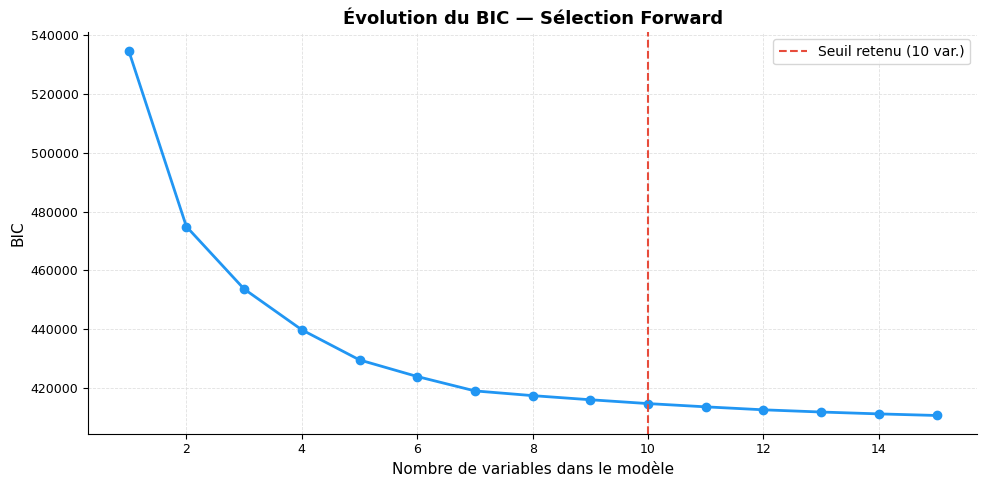

In [30]:
# ── Visualisation de la courbe BIC ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(nb_vars, bic_values, color=COLOR_NEUTRE, marker='o', linewidth=2, markersize=6)
ax.set_xlabel('Nombre de variables dans le modèle')
ax.set_ylabel('BIC')
ax.set_title('Évolution du BIC — Sélection Forward', fontweight='bold')
ax.axvline(x=10, color=COLOR_DEFAUT, linestyle='--', linewidth=1.5, label='Seuil retenu (10 var.)')
ax.legend()
plt.tight_layout()
plt.show()

In [31]:
# ── Sélection finale des 10 meilleures variables ──────────────────────────────
# Alternative : SelectKBest avec test du chi2
N_VARS = 10
selector = SelectKBest(score_func=chi2_sklearn, k=N_VARS)
selector.fit_transform(X_resampled, y_resampled)
selected_features = X_resampled.columns[selector.get_support()].tolist()

print(f"Variables sélectionnées (chi2, top {N_VARS}) :")
for i, v in enumerate(selected_features, 1):
    print(f"{i:2d}. {v}")

Variables sélectionnées (chi2, top 10) :
 1. CRTAD_AG_NBJDE_BA_level1
 2. CRTAD_AG_NBJDE_BB_level1
 3. CRTAD_AG_NBJDE_BC_level1
 4. DECOUVERT_MOY_MEAN_level1
 5. NBRJJRDVTAUT_STK_MAX_level1
 6. NBRJJRDVTAUT_STK_MEAN_level1
 7. nb_jours_arrieres_T_level1
 8. CRTAD_IND_0015_level1
 9. TOPCLILITIG
10. CHR_V1_4_USAGE_bin


In [32]:
set_BIC, set_kbest = set(selected_vars_bic), set(selected_features)

common     = set_BIC & set_kbest            
only_in_BIC  = set_BIC - set_kbest              
only_in_Kbest  = set_kbest - set_BIC              

print("Common:", list(common))
print("Only in BIC:", list(only_in_BIC))
print("Only in Kbest:", list(only_in_Kbest))

Common: ['TOPCLILITIG', 'CRTAD_AG_NBJDE_BA_level1', 'CRTAD_AG_NBJDE_BC_level1', 'CRTAD_AG_NBJDE_BB_level1', 'DECOUVERT_MOY_MEAN_level1', 'CHR_V1_4_USAGE_bin', 'nb_jours_arrieres_T_level1']
Only in BIC: ['NDB_Mm4', 'NBECR_PAR_level1', 'Engagement_prorat_level1', 'CRTAD_AG_SOLDE_T3_level1', 'NDB_Mm12', 'Top_immo_camca', 'AGEPRS_level1', 'Top_immo_CL']
Only in Kbest: ['NBRJJRDVTAUT_STK_MEAN_level1', 'NBRJJRDVTAUT_STK_MAX_level1', 'CRTAD_IND_0015_level1']


In [33]:
common = list(common)
#common.remove("nb_jours_arrieres_T_level1")
final_selected_features = common + [
    "CRTAD_IND_0015_level1",
    "NBRJJRDVTAUT_STK_MEAN_level1",
    "NBECR_PAR_level1"
]

In [34]:
SEUIL_CRAMER_INTER= 0.80   # Seuil de corrélation entre variables explicatives
CIBLE= 'DDefaut_NDB'

print(f"Variables candidates analysées : {len(final_selected_features)}")
print(f"Seuil V de Cramér inter-variables : {SEUIL_CRAMER_INTER}")

# ── Calcul de la matrice complète ─────────────────────────────────────────────
cramer_df, paires_correlees = matrice_cramer(
    df=X_train,
    variables=final_selected_features,
    seuil=SEUIL_CRAMER_INTER
)
print(f"\nPaires corrélées détectées (V > {SEUIL_CRAMER_INTER}) : {len(paires_correlees)}")

Variables candidates analysées : 10
Seuil V de Cramér inter-variables : 0.8

Paires corrélées détectées (V > 0.8) : 0


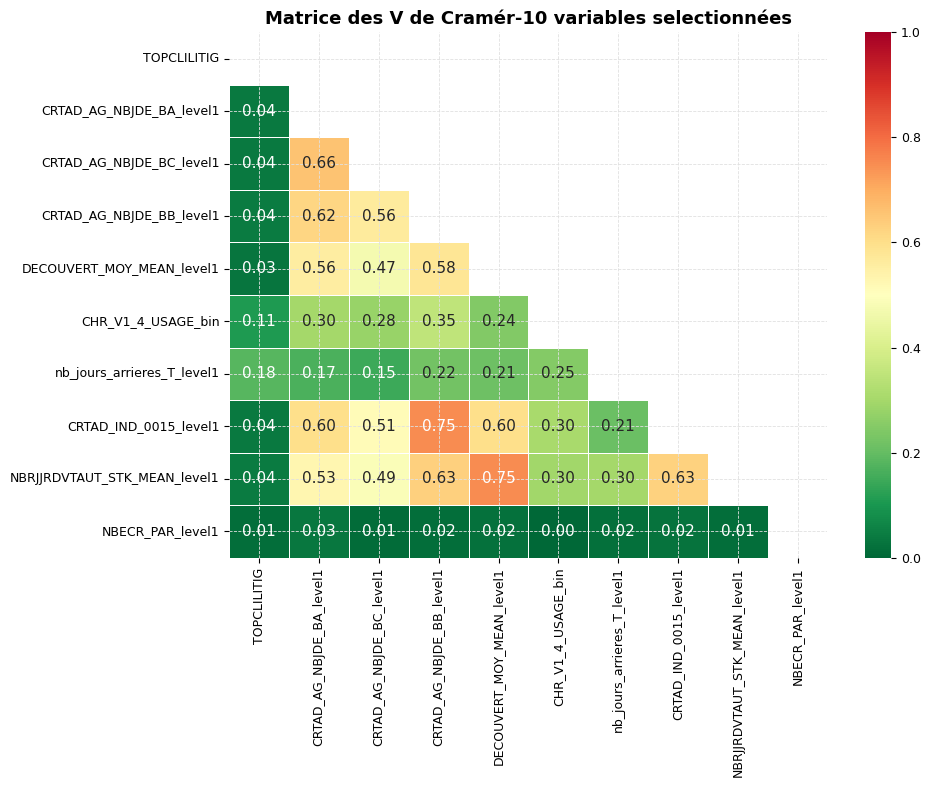

In [35]:
# ── Heatmap de la matrice complète ────────────────────────────────────────────
plot_cramer_heatmap(
    cramer_df,
    title=f"Matrice des V de Cramér-{len(final_selected_features)} variables selectionnées"
)

Figure sauvegardée → output\stabilite_DDefaut_NDB_TOPCLILITIG_CRTAD_AG_NBJDE_BA_level1_CRTAD_AG_NBJDE_BC_level1.png


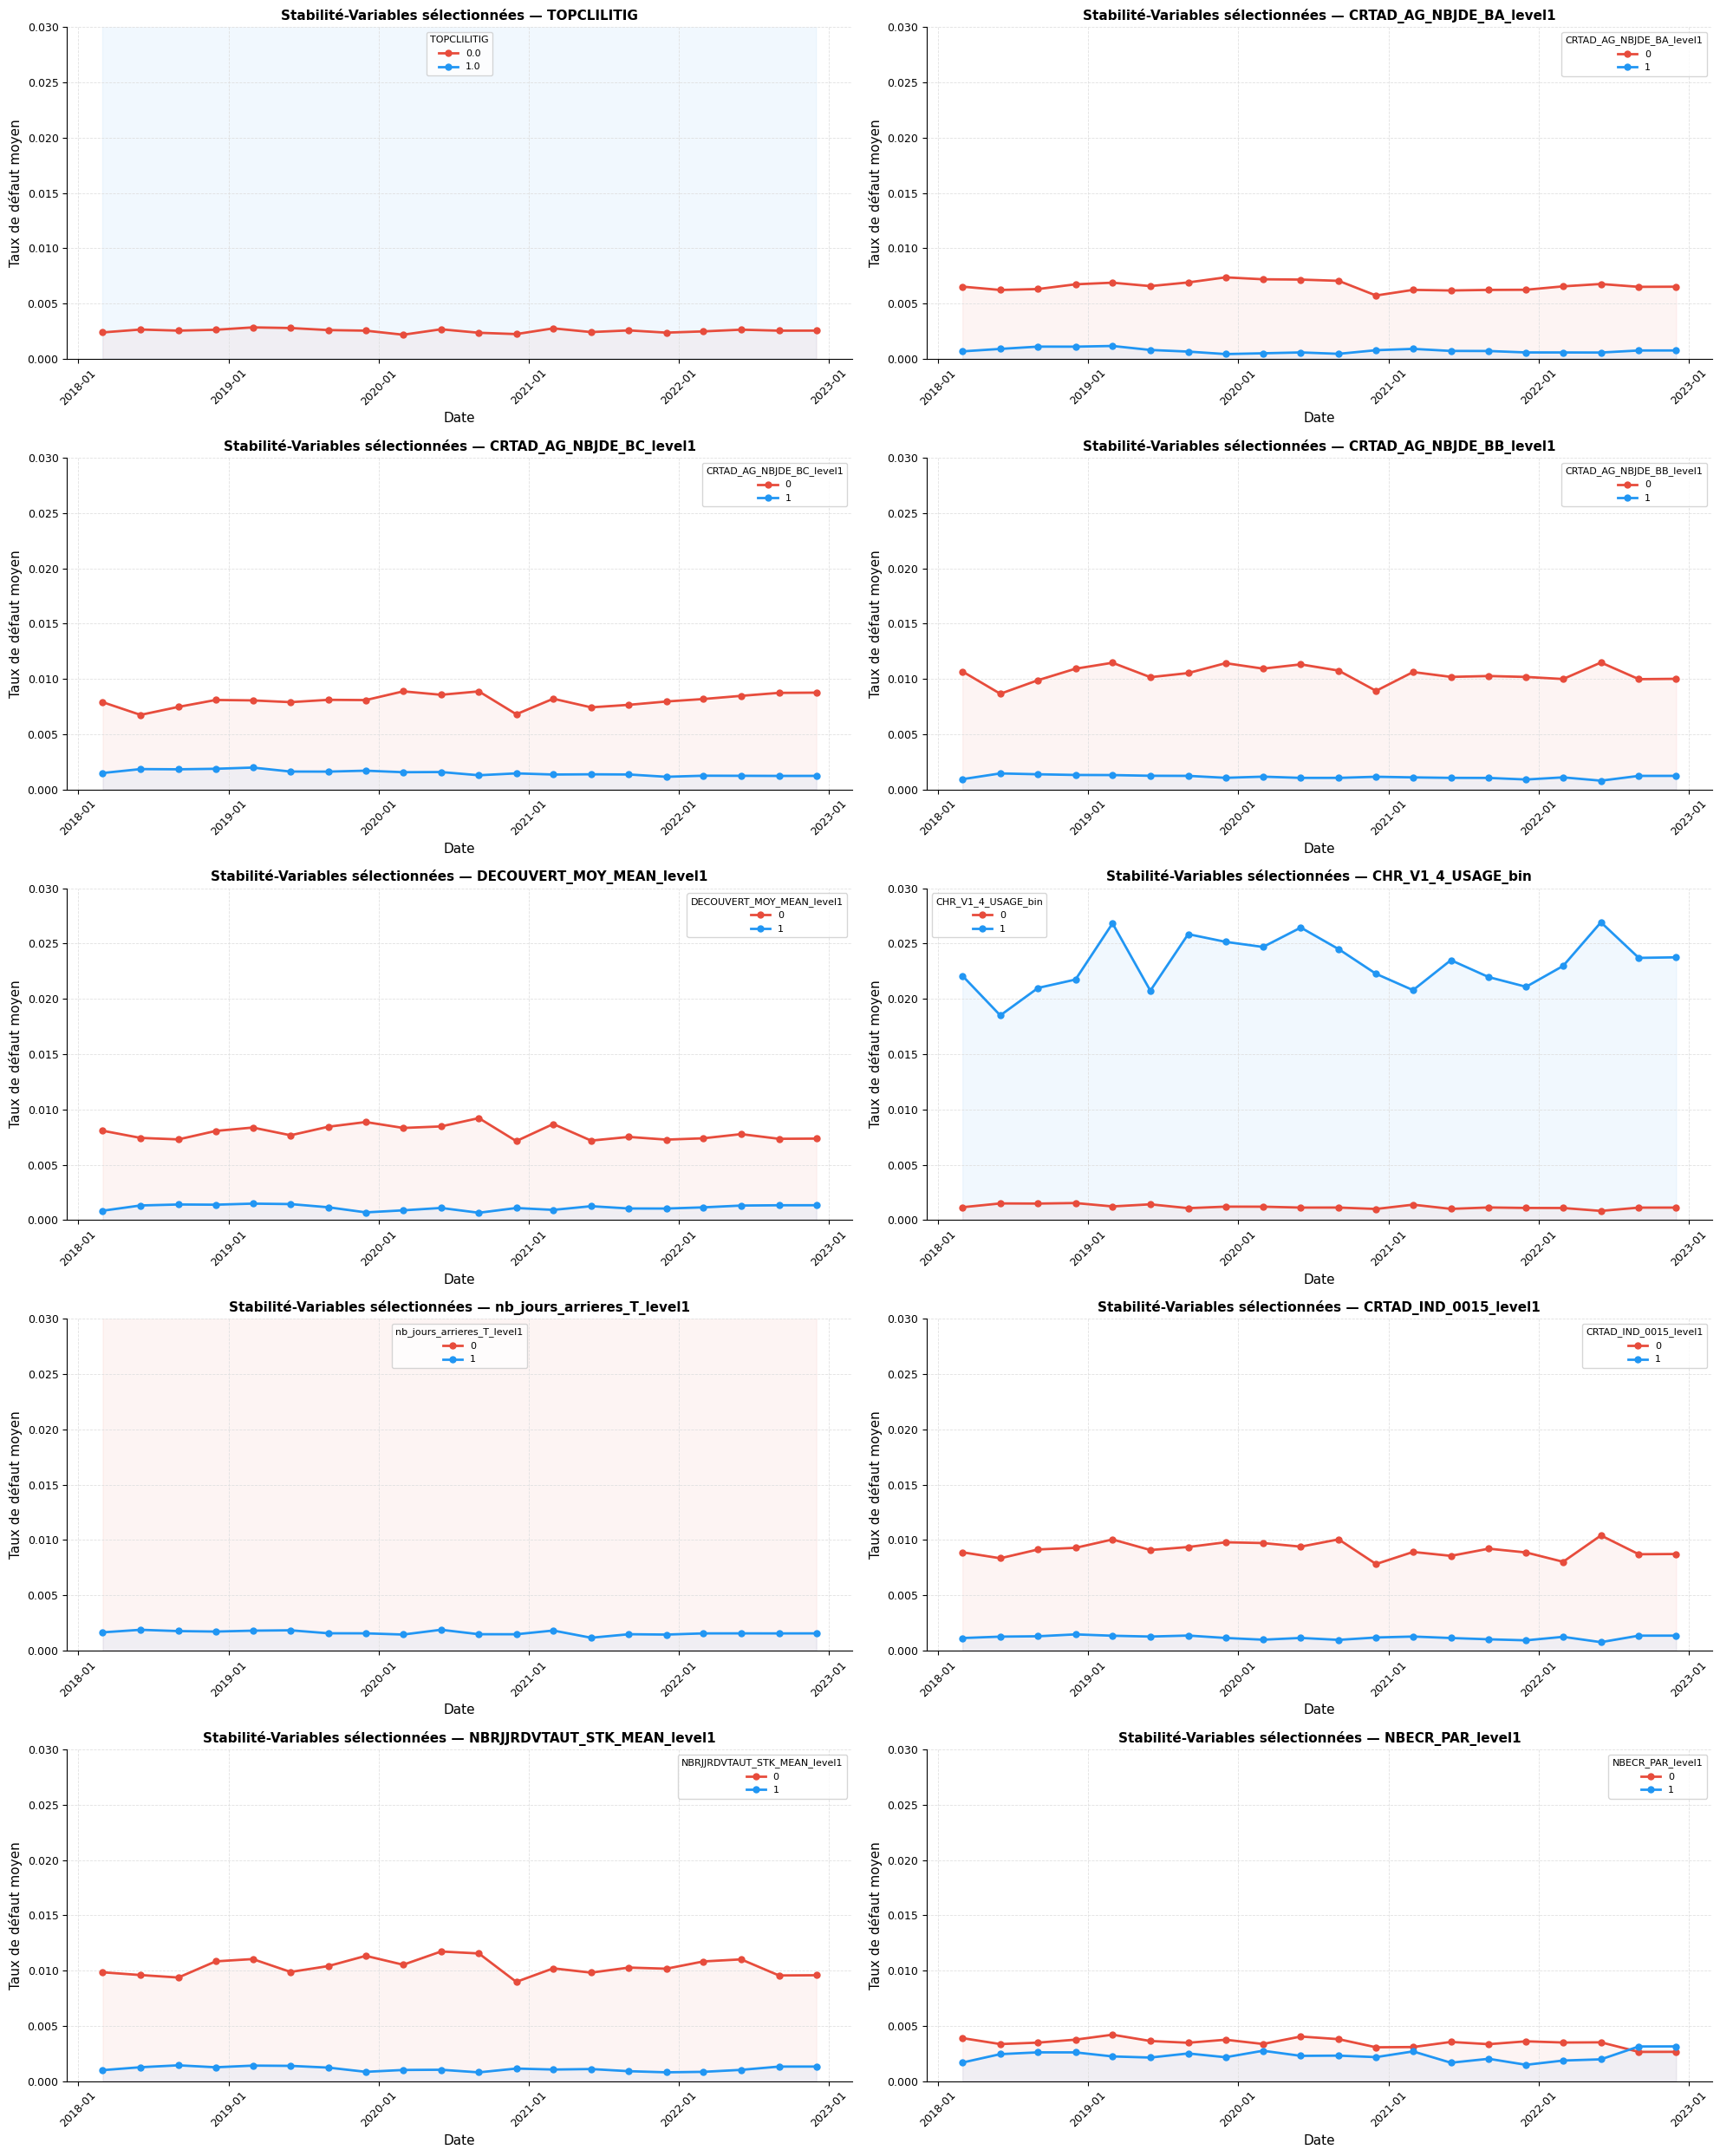

In [36]:
# Variable Categorielle
plot_evolution_taux_defaut(
    df       = df3,
    cible    = 'DDefaut_NDB',
    variables= final_selected_features,
    date_col = 'Date',
    y_min    = 0,
    y_max    = 0.03,
    titre_prefixe = "Stabilité-Variables sélectionnées",
    save_dir = OUTPUT_DIR,
)

In [37]:
# ── Entraînement du modèle logistique final (statsmodels) ─────────────────────
X_final = sm.add_constant(X_resampled[final_selected_features])
logit_model = sm.Logit(y_resampled, X_final)
logit_results = logit_model.fit(method='bfgs', maxiter=200, disp=False)
print(logit_results.summary())

                           Logit Regression Results                           
Dep. Variable:            DDefaut_NDB   No. Observations:               523072
Model:                          Logit   Df Residuals:                   523061
Method:                           MLE   Df Model:                           10
Date:                Thu, 09 Apr 2026   Pseudo R-squ.:                  0.4035
Time:                        11:54:08   Log-Likelihood:            -2.1626e+05
converged:                       True   LL-Null:                   -3.6257e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                            2.9193      0.016    187.485      0.000       2.889       2.950
TOPCLILITIG                      2.4175      0.090     26.813      0.000     

In [38]:
def export_logit_results(model_results):
    """Exporte les résultats logit en DataFrame formaté et Excel"""
    # 1. EN-TÊTE RÉSUMÉ MODÈLE 
    resume_dict = {
        'Nb Observations': model_results.nobs,
        'Nb Résiduels': model_results.df_resid,
        'Pseudo R²': model_results.prsquared,
        'Log-Likelihood': model_results.llf,
        'LL-Null': model_results.llnull,
        'LLR p-value': model_results.llr_pvalue,
        'AIC': model_results.aic,
        'BIC': model_results.bic,
        'Convergé': model_results.mle_retvals['converged']
    }
    
    resume_df = pd.DataFrame([resume_dict])
    
    # 2. TABLEAU COEFFICIENTS 
    coef_df = pd.DataFrame({
        'Coefficient' : model_results.params,
        'Std_Error'   : model_results.bse,
        'Z_stat'      : model_results.tvalues,
        'P_value'     : model_results.pvalues,
        'IC_bas_95'   : model_results.conf_int()[0],
        'IC_haut_95'  : model_results.conf_int()[1],
        'Odds_Ratio'  : np.exp(model_results.params),
    }).drop(index='const', errors='ignore')

    coef_df['Significatif_5pct'] = np.where(coef_df['P_value'] < 0.05, 'Oui', 'Non')
    coef_df = coef_df.sort_values('Coefficient')
    
    # 3. EXPORT EXCEL COMPLÈT (2 onglets)
    with pd.ExcelWriter(f"{OUTPUT_DIR}/logit_results_complet.xlsx", engine='openpyxl') as writer:
        # Onglet 1: Résumé modèle
        resume_df.to_excel(writer, sheet_name='Resume_Modele', index=False)
        
        # Onglet 2: Coefficients
        coef_df.round(4).to_excel(writer, sheet_name='Coefficients', index=True)
        
    return resume_df,coef_df

resume_df,coef_df=export_logit_results(logit_results)
display(resume_df)
display(coef_df)

,Nb Observations,Nb Résiduels,Pseudo R²,Log-Likelihood,LL-Null,LLR p-value,AIC,BIC,Convergé
0,523072,523061.0000,0.4035,-216261.0806,-362565.8820,0.0000,432544.1612,432667.0034,True


,Coefficient,Std_Error,Z_stat,P_value,IC_bas_95,IC_haut_95,Odds_Ratio,Significatif_5pct
nb_jours_arrieres_T_level1,-2.4187,0.0149,-161.8509,0.0000,-2.4480,-2.3895,0.0890,Oui
NBECR_PAR_level1,-0.7309,0.0080,-91.5713,0.0000,-0.7465,-0.7152,0.4815,Oui
CRTAD_AG_NBJDE_BB_level1,-0.5158,0.0132,-39.0525,0.0000,-0.5417,-0.4899,0.5970,Oui
CRTAD_AG_NBJDE_BA_level1,-0.5105,0.0118,-43.2940,0.0000,-0.5337,-0.4874,0.6002,Oui
DECOUVERT_MOY_MEAN_level1,-0.4806,0.0128,-37.4347,0.0000,-0.5058,-0.4554,0.6184,Oui
CRTAD_AG_NBJDE_BC_level1,-0.3962,0.0100,-39.6835,0.0000,-0.4158,-0.3767,0.6729,Oui
CRTAD_IND_0015_level1,-0.2320,0.0134,-17.3626,0.0000,-0.2581,-0.2058,0.7930,Oui
NBRJJRDVTAUT_STK_MEAN_level1,0.1068,0.0138,7.7647,0.0000,0.0798,0.1338,1.1127,Oui
CHR_V1_4_USAGE_bin,1.0950,0.0102,106.9587,0.0000,1.0750,1.1151,2.9893,Oui
TOPCLILITIG,2.4175,0.0902,26.8126,0.0000,2.2408,2.5943,11.2182,Oui


## Section 7 - Évaluation & Validation du Modèle

### 7.1 Pouvoir discriminant

**Métriques principales** :
- **AUC** (Area Under the ROC Curve) : mesure la capacité du modèle à séparer défauts et sains. AUC = 0.5 → modèle sans pouvoir discriminant ; AUC = 1 → discrimination parfaite.
- **Indice de Gini** = 2 × AUC − 1. Interprétation standard Bâle : Gini > 0.30 pour les modèles PD.

L'évaluation est effectuée sur trois échantillons : entraînement (SMOTE), test (original), et hors du temps.


  Performances — Échantillon : TRAIN (SMOTE)
  AUC         : 0.8862
  Gini        : 0.7724
  Accuracy    : 0.8246
  Precision   : 0.8549
  Rappel      : 0.7820
  F1          : 0.8168


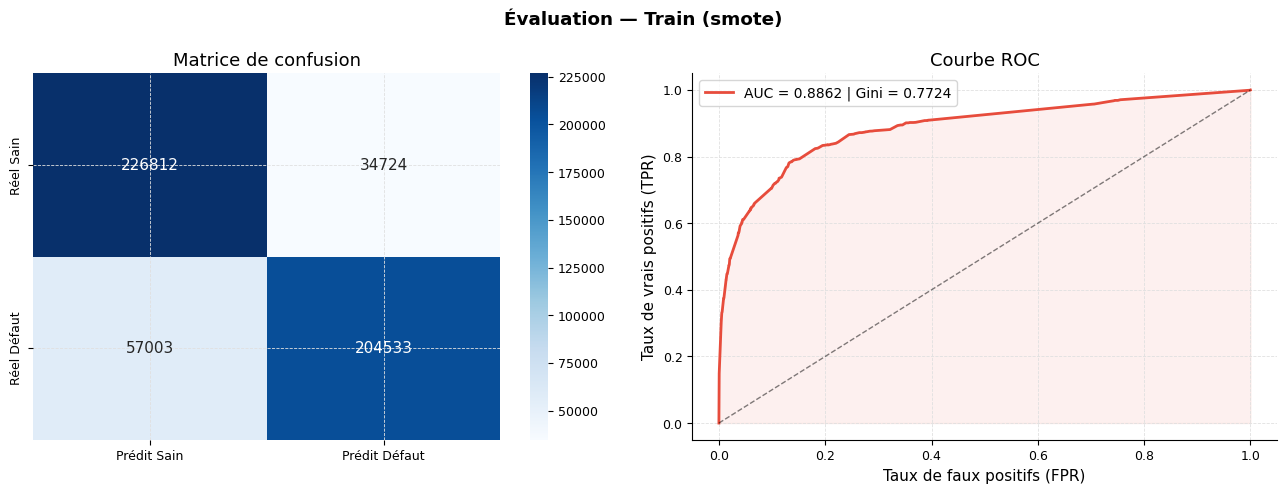


  Performances — Échantillon : TEST
  AUC         : 0.8828
  Gini        : 0.7657
  Accuracy    : 0.8658
  Precision   : 0.0165
  Rappel      : 0.7568
  F1          : 0.0323


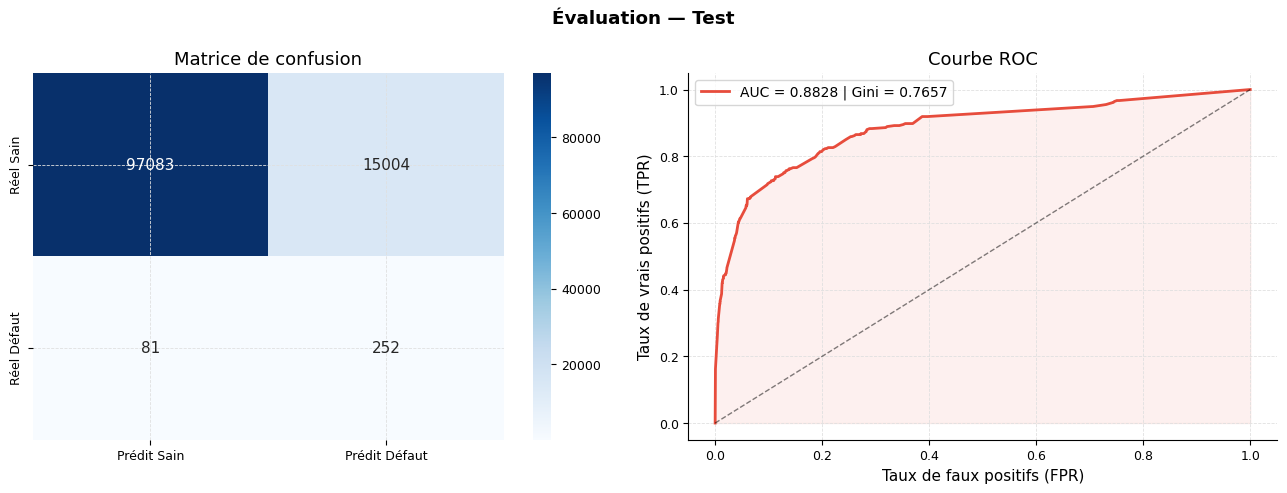

In [39]:
def evaluer_performance(
    y_true: pd.Series,
    y_pred_prob: pd.Series,
    nom: str = "test",
    seuil: float = 0.5
) -> dict:
    """
    Évalue les performances d'un modèle de classification binaire.

    Affiche :
    - AUC, Gini, Accuracy, Précision, Rappel, F1
    - Matrice de confusion
    - Courbe ROC

    Retourne un dictionnaire de métriques.
    """
    y_pred = (y_pred_prob >= seuil).astype(int)
    y_true_np = np.array(y_true)
    y_pred_np = np.array(y_pred)

    fpr, tpr, _ = roc_curve(y_true_np, y_pred_prob)
    auc_val  = auc(fpr, tpr)
    gini_val = 2 * auc_val - 1

    metriques = {
        'AUC'       : round(auc_val,  4),
        'Gini'      : round(gini_val, 4),
        'Accuracy'  : round(accuracy_score (y_true_np, y_pred_np), 4),
        'Precision' : round(precision_score(y_true_np, y_pred_np, zero_division=0), 4),
        'Rappel'    : round(recall_score   (y_true_np, y_pred_np, zero_division=0), 4),
        'F1'        : round(f1_score       (y_true_np, y_pred_np, zero_division=0), 4),
    }

    print(f"\n{'='*50}")
    print(f"  Performances — Échantillon : {nom.upper()}")
    print(f"{'='*50}")
    for k, v in metriques.items():
        print(f"  {k:<12}: {v:.4f}")

    # Matrice de confusion + courbe ROC
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"Évaluation — {nom.capitalize()}", fontweight='bold')

    # Heatmap confusion
    cm = confusion_matrix(y_true_np, y_pred_np)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Prédit Sain', 'Prédit Défaut'],
        yticklabels=['Réel Sain', 'Réel Défaut'],
        ax=axes[0]
    )
    axes[0].set_title('Matrice de confusion')

    # Courbe ROC
    axes[1].plot(fpr, tpr, color=COLOR_DEFAUT, linewidth=2,
                 label=f'AUC = {auc_val:.4f} | Gini = {gini_val:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
    axes[1].fill_between(fpr, tpr, alpha=0.08, color=COLOR_DEFAUT)
    axes[1].set_xlabel('Taux de faux positifs (FPR)')
    axes[1].set_ylabel('Taux de vrais positifs (TPR)')
    axes[1].set_title('Courbe ROC')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/roc_{nom}.png", bbox_inches='tight', dpi=150)
    plt.show()

    return metriques


# ── Évaluation sur le train (SMOTE) ──────────────────────────────────────────
y_train_proba = logit_results.predict(X_final)
perf_train = evaluer_performance(y_resampled, y_train_proba, nom="train (SMOTE)")

# ── Évaluation sur le test ────────────────────────────────────────────────────
X_test_final = sm.add_constant(X_test[final_selected_features], has_constant='add')
y_test_proba = logit_results.predict(X_test_final)
perf_test = evaluer_performance(y_test, y_test_proba, nom="test")

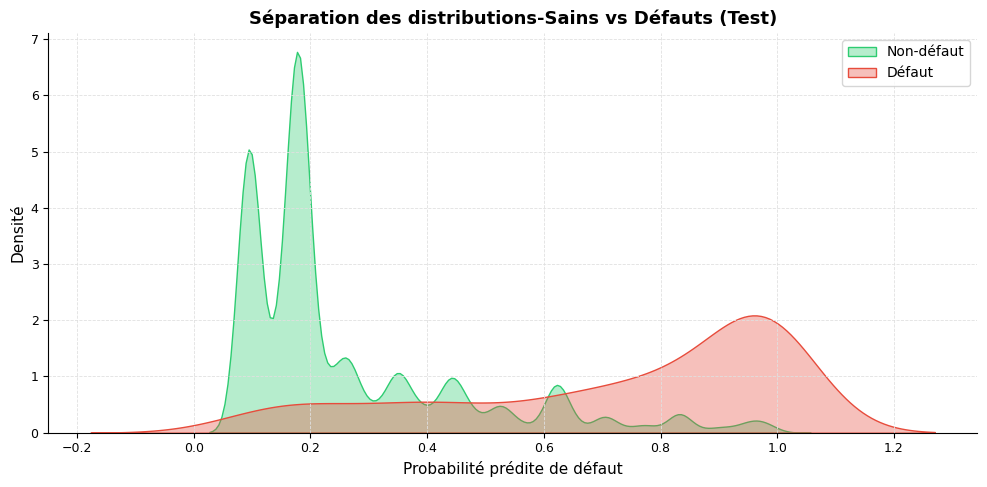

In [40]:
# ── Séparation des distributions — Sains vs Défauts ──────────────────────────
y_pred_aligned, y_test_aligned = y_test_proba.align(y_test, join='inner')

fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(
    data=y_pred_aligned[y_test_aligned == 0],
    color=COLOR_SAIN, label='Non-défaut', fill=True, alpha=0.35, ax=ax
)
sns.kdeplot(
    data=y_pred_aligned[y_test_aligned == 1],
    color=COLOR_DEFAUT, label='Défaut', fill=True, alpha=0.35, ax=ax
)
ax.set_xlabel('Probabilité prédite de défaut')
ax.set_ylabel('Densité')
ax.set_title('Séparation des distributions-Sains vs Défauts (Test)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7.2 Évaluation hors du temps

**Intérêt réglementaire** : l'évaluation hors du temps (Out-Of-Time, OOT) teste la stabilité du modèle sur une période postérieure à l'entraînement. Une dégradation de l'AUC supérieure à 5 points entre test et OOT est un signal d'instabilité temporelle.


  Performances — Échantillon : HORS DU TEMPS (2022+)
  AUC         : 0.8800
  Gini        : 0.7600
  Accuracy    : 0.8683
  Precision   : 0.0160
  Rappel      : 0.7509
  F1          : 0.0313


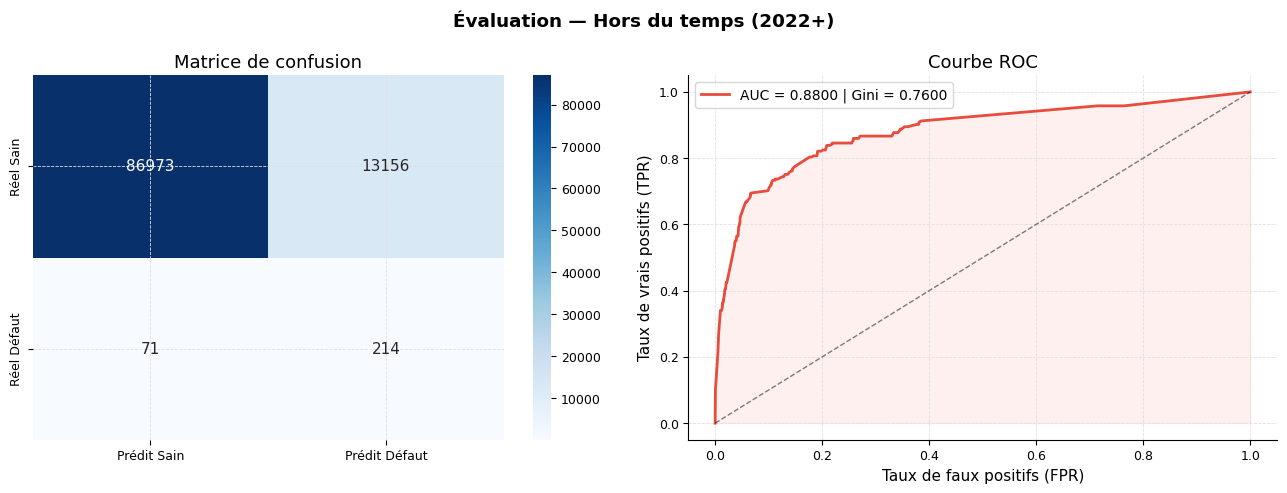


Tableau comparatif des performances :


,AUC,Gini,Accuracy,Precision,Rappel,F1
Échantillon,,,,,,
Train (SMOTE),0.8862,0.7724,0.8246,0.8549,0.7820,0.8168
Test,0.8828,0.7657,0.8658,0.0165,0.7568,0.0323
Hors du temps,0.8800,0.7600,0.8683,0.0160,0.7509,0.0313


In [ ]:
# ── Évaluation hors du temps (2022 et au-delà) ───────────────────────────────
X_hdt_final = sm.add_constant(X_hdt[final_selected_features], has_constant='add')
y_hdt_proba = logit_results.predict(X_hdt_final)
perf_hdt = evaluer_performance(y_hdt, y_hdt_proba, nom="hors du temps (2022+)")

# ── Tableau comparatif des performances ──────────────────────────────────────
comparatif = pd.DataFrame([
    {'Échantillon': 'Train (SMOTE)', **perf_train},
    {'Échantillon': 'Test'         , **perf_test},
    {'Échantillon': 'Hors du temps', **perf_hdt},
])

#comparatif.round(4).to_excel('comparatif_performances.xlsx', sheet_name='Comparatif', index=False)

print("\nTableau comparatif des performances :")
display(comparatif.set_index('Échantillon'))


### 7.3 Grille de score-Points des variables

**Concept** : la grille de score transforme les coefficients logistiques en points entiers, facilitant l'interprétation et la communication des résultats. Chaque variable et chaque modalité reçoit un nombre de points proportionnel à son contribution au log-odds.

In [42]:
# def calculer_grille_score(
#     X_test: pd.DataFrame,
#     y_test: pd.Series,
#     variables: list
# ) -> pd.DataFrame:
#     """
#     Calcule le taux de défaut observé par modalité pour chaque variable binaire.
#     Sert de base à la construction de la grille de score.
#     """
#     rows = []
#     for var in variables:
#         if var not in X_test.columns:
#             continue
#         tmp = X_test[[var]].copy()
#         tmp['DDefaut_NDB'] = y_test.values
#         for mod in sorted(tmp[var].unique()):
#             sub    = tmp[tmp[var] == mod]
#             n      = len(sub)
#             pct    = n / len(tmp) * 100
#             td     = sub['DDefaut_NDB'].mean() * 100
#             rows.append({
#                 'Variable'        : var,
#                 'Modalité'        : mod,
#                 'N'               : n,
#                 'Pct_Population'  : round(pct, 2),
#                 'Taux_Defaut_Pct' : round(td, 4),
#             })
#     return pd.DataFrame(rows)


# grille = calculer_grille_score(X_test, y_test, final_selected_features)
# display(grille)

### 7.3 Grille de Score-Transformation en points (0–1000)

**Concept** : la scorecard transforme les coefficients logistiques en points entiers
lisibles par un métier non-statisticien. La transformation repose sur deux paramètres
calibrés :

- **Score de référence (PDO)** : *Points to Double the Odds* - nombre de points
  nécessaires pour doubler les odds de bon payeur. Standard marché : PDO = 20.
- **Score ancre** : score cible pour un odds de référence. Standard : score = 600
  pour odds = 50 (i.e. 1 défaut pour 50 sains).

**Formule de conversion** :

$$\text{Points}(\text{variable, modalité}) = -\beta_j \times \text{Factor}$$

$$\text{Factor} = \frac{\text{PDO}}{\ln(2)}, \quad
\text{Offset} = \text{Score ancre} - \text{Factor} \times \ln(\text{Odds ancre})$$

$$\text{Score final} = \text{Offset} + \sum_j \text{Points}_j$$

Les points sont ensuite **normalisés linéairement sur [0, 1000]** pour la lisibilité.

**Intérêt métier** : la grille permet de calculer un score individuel sans modèle logiciel, d'expliquer la décision à un client, et de vérifier la monotonicité des points par rapport au risque.

Coefficients du modèle logistique final :


,Coefficient,Std_Error,Z_stat,P_value,IC_bas_95,IC_haut_95,Odds_Ratio,Significatif_5pct
nb_jours_arrieres_T_level1,-2.4187,0.0149,-161.8509,0.0000,-2.4480,-2.3895,0.0890,True
NBECR_PAR_level1,-0.7309,0.0080,-91.5713,0.0000,-0.7465,-0.7152,0.4815,True
CRTAD_AG_NBJDE_BB_level1,-0.5158,0.0132,-39.0525,0.0000,-0.5417,-0.4899,0.5970,True
CRTAD_AG_NBJDE_BA_level1,-0.5105,0.0118,-43.2940,0.0000,-0.5337,-0.4874,0.6002,True
DECOUVERT_MOY_MEAN_level1,-0.4806,0.0128,-37.4347,0.0000,-0.5058,-0.4554,0.6184,True
CRTAD_AG_NBJDE_BC_level1,-0.3962,0.0100,-39.6835,0.0000,-0.4158,-0.3767,0.6729,True
CRTAD_IND_0015_level1,-0.2320,0.0134,-17.3626,0.0000,-0.2581,-0.2058,0.7930,True
NBRJJRDVTAUT_STK_MEAN_level1,0.1068,0.0138,7.7647,0.0000,0.0798,0.1338,1.1127,True
CHR_V1_4_USAGE_bin,1.0950,0.0102,106.9587,0.0000,1.0750,1.1151,2.9893,True
TOPCLILITIG,2.4175,0.0902,26.8126,0.0000,2.2408,2.5943,11.2182,True



Paramètres de conversion :
  Factor (PDO/ln2) = 28.8539
  Offset           = 487.1229

Grille de score finale (0–1000) :


,Variable,Modalite,N,Pct_Population,Taux_Defaut_Pct,Log_Odds_Obs,Points_Bruts,Score_Brut,Score_Norme
0,CHR_V1_4_USAGE_bin,0.0000,103370,91.9500,0.1113,-6.8000,-31.6000,487.1229,500
1,CHR_V1_4_USAGE_bin,1.0000,9050,8.0500,2.4088,-3.7016,-31.6000,455.5229,273
2,CRTAD_AG_NBJDE_BA_level1,0.0000,42612,37.9000,0.6688,-5.0007,14.7300,487.1229,500
3,CRTAD_AG_NBJDE_BA_level1,1.0000,69808,62.1000,0.0688,-7.2816,14.7300,501.8529,605
4,CRTAD_AG_NBJDE_BB_level1,0.0000,22146,19.7000,1.0566,-4.5395,14.8800,487.1229,500
5,CRTAD_AG_NBJDE_BB_level1,1.0000,90274,80.3000,0.1097,-6.8144,14.8800,502.0029,607
6,CRTAD_AG_NBJDE_BC_level1,0.0000,24941,22.1900,0.7979,-4.8230,11.4300,487.1229,500
7,CRTAD_AG_NBJDE_BC_level1,1.0000,87479,77.8100,0.1532,-6.4798,11.4300,498.5529,582
8,CRTAD_IND_0015_level1,0.0000,25169,22.3900,0.9297,-4.6687,6.6900,487.1229,500
9,CRTAD_IND_0015_level1,1.0000,87251,77.6100,0.1135,-6.7803,6.6900,493.8129,548



Contrôle de monotonicité :


,Variable,N_Modalites,Score_Min,Score_Max,Taux_Defaut_Min_Pct,Taux_Defaut_Max_Pct,Monotone
0,CHR_V1_4_USAGE_bin,2,273,500,0.1113,2.4088,Non monotone
1,CRTAD_AG_NBJDE_BA_level1,2,500,605,0.0688,0.6688,Non monotone
2,CRTAD_AG_NBJDE_BB_level1,2,500,607,0.1097,1.0566,Non monotone
3,CRTAD_AG_NBJDE_BC_level1,2,500,582,0.1532,0.7979,Non monotone
4,CRTAD_IND_0015_level1,2,500,548,0.1135,0.9297,Non monotone
5,DECOUVERT_MOY_MEAN_level1,2,500,599,0.1022,0.8232,Non monotone
6,NBECR_PAR_level1,2,500,651,0.2279,0.3545,Non monotone
7,NBRJJRDVTAUT_STK_MEAN_level1,2,478,500,0.1035,1.0625,Monotone
8,TOPCLILITIG,2,0,500,0.2484,45.3782,Non monotone
9,nb_jours_arrieres_T_level1,2,500,1000,0.1563,5.3910,Non monotone


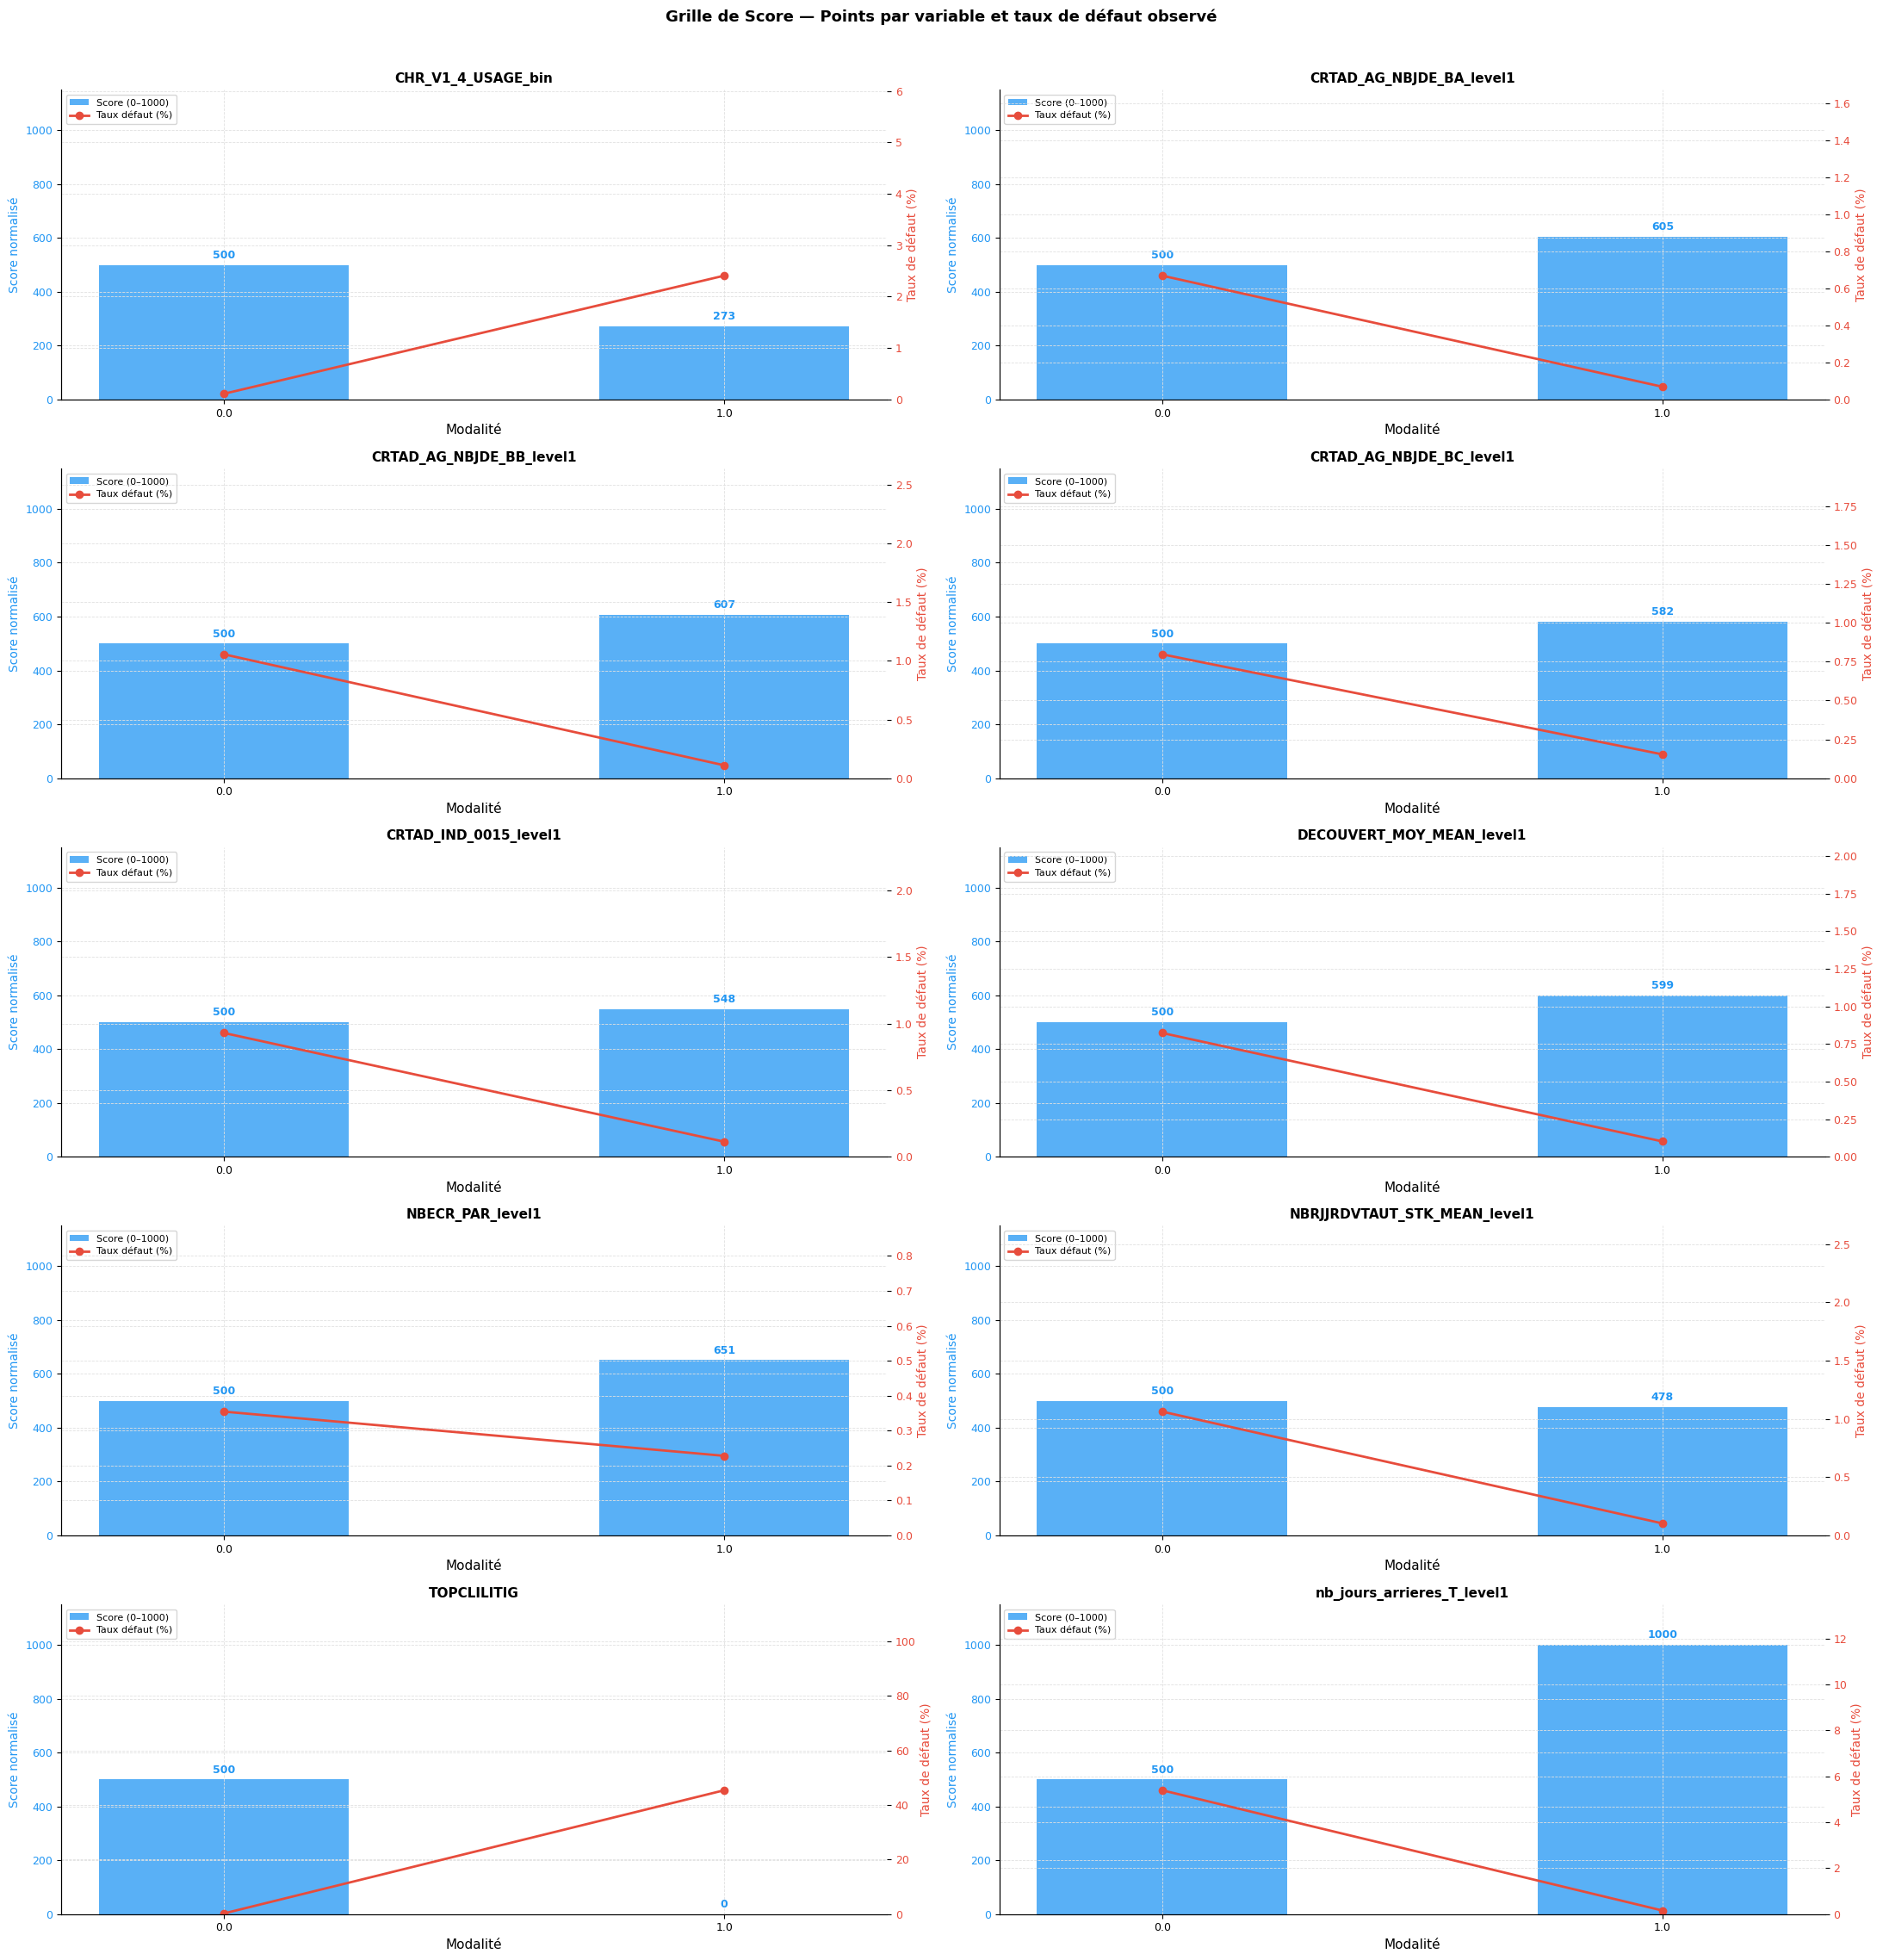

In [43]:
# ═══════════════════════════════════════════════════════════════════════════════
# GRILLE DE SCORE
# Étapes :
#   1. Extraction des coefficients du modèle logistique
#   2. Calcul des statistiques observées par modalité (taux de défaut, effectifs)
#   3. Conversion en points bruts (méthode PDO)
#   4. Normalisation sur [0, 1000]
#   5. Visualisation
#   6. Vérification de la monotonicité
# ═══════════════════════════════════════════════════════════════════════════════

# ── Paramètres de calibration ─────────────────────────────────────────────────
PDO         = 20        # Points to Double the Odds (standard marché)
SCORE_ANCRE = 600       # Score associé à l'odds de référence
ODDS_ANCRE  = 50        # 1 défaut pour 50 sains
SCORE_MIN   = 0         # Borne basse de normalisation
SCORE_MAX   = 1000      # Borne haute de normalisation


# ── Étape 1 : Extraction des coefficients logistiques ─────────────────────────
def extraire_coefficients(model_results) -> pd.DataFrame:
    """
    Extrait les coefficients, p-values et intervalles de confiance
    du modèle logistique statsmodels.

    Retourne un DataFrame indexé par variable.
    """
    coef_df = pd.DataFrame({
        'Coefficient' : model_results.params,
        'Std_Error'   : model_results.bse,
        'Z_stat'      : model_results.tvalues,
        'P_value'     : model_results.pvalues,
        'IC_bas_95'   : model_results.conf_int()[0],
        'IC_haut_95'  : model_results.conf_int()[1],
        'Odds_Ratio'  : np.exp(model_results.params),
    }).drop(index='const', errors='ignore')

    coef_df['Significatif_5pct'] = coef_df['P_value'] < 0.05
    return coef_df.sort_values('Coefficient')


coef_df = extraire_coefficients(logit_results)

print("Coefficients du modèle logistique final :")
display(coef_df.round(4))


# ── Étape 2 : Statistiques observées par (variable, modalité) ─────────────────
def calculer_stats_modalites(
    X: pd.DataFrame,
    y: pd.Series,
    variables: list,
    cible: str = 'DDefaut_NDB'
) -> pd.DataFrame:
    """
    Calcule pour chaque (variable, modalité) :
      - Effectif et % population
      - Taux de défaut observé
      - Log-odds observé (WoE simplifié)

    Paramètres
    ----------
    X         : DataFrame des prédicteurs (échantillon de test original, non SMOTE)
    y         : Série cible binaire
    variables : liste des variables du modèle final
    cible     : nom de la variable cible

    Note : on utilise X_test (non rééchantillonné) pour des statistiques
    représentatives de la population réelle.
    """
    df_tmp = X[variables].copy()
    df_tmp[cible] = y.values
    n_total = len(df_tmp)

    rows = []
    for var in variables:
        if var not in df_tmp.columns:
            continue
        for mod in sorted(df_tmp[var].unique()):
            sub = df_tmp[df_tmp[var] == mod]
            n   = len(sub)
            td  = sub[cible].mean()

            # Log-odds observé (avec protection contre log(0))
            td_safe   = np.clip(td, 1e-6, 1 - 1e-6)
            log_odds  = np.log(td_safe / (1 - td_safe))

            rows.append({
                'Variable'        : var,
                'Modalite'        : mod,
                'N'               : n,
                'Pct_Population'  : round(n / n_total * 100, 2),
                'Taux_Defaut_Pct' : round(td * 100, 4),
                'Log_Odds_Obs'    : round(log_odds, 4),
            })

    return pd.DataFrame(rows)


stats_modalites = calculer_stats_modalites(
    X_test, y_test, list(final_selected_features)
)


# ── Étape 3 : Conversion en points bruts (méthode PDO) ───────────────────────
def convertir_en_points(
    coef_df: pd.DataFrame,
    pdo: float = 20,
    score_ancre: float = 600,
    odds_ancre: float = 50,
) -> tuple[pd.DataFrame, float, float]:
    """
    Convertit les coefficients logistiques en points de scorecard.

    Factor = PDO / ln(2)
    Offset = Score_ancre - Factor * ln(Odds_ancre)
    Points(variable j) = -coef_j * Factor

    La constante est répartie uniformément sur l'Offset.

    Retourne :
        coef_avec_points : DataFrame enrichi avec la colonne 'Points_Bruts'
        factor           : facteur de conversion
        offset           : offset global du score
    """
    factor = pdo / np.log(2)
    offset = score_ancre - factor * np.log(odds_ancre)

    coef_avec_points = coef_df.copy()
    coef_avec_points['Points_Bruts'] = (
        -coef_avec_points['Coefficient'] * factor
    ).round(2)

    return coef_avec_points, factor, offset


coef_avec_points, FACTOR, OFFSET = convertir_en_points(
    coef_df, pdo=PDO, score_ancre=SCORE_ANCRE, odds_ancre=ODDS_ANCRE
)

print(f"\nParamètres de conversion :")
print(f"  Factor (PDO/ln2) = {FACTOR:.4f}")
print(f"  Offset           = {OFFSET:.4f}")


# ── Étape 4 : Grille complète avec normalisation [0, 1000] ───────────────────
def construire_grille_normalisee(
    stats_modalites: pd.DataFrame,
    coef_avec_points: pd.DataFrame,
    offset: float,
    score_min: int = 0,
    score_max: int = 1000,
) -> pd.DataFrame:
    """
    Assemble la grille finale en joignant statistiques observées et points,
    puis normalise les scores sur [score_min, score_max].

    Normalisation linéaire :
        Score_norm = score_min + (Score_brut - min_brut) /
                     (max_brut - min_brut) * (score_max - score_min)

    Le score individuel final est :
        Score_individu = Offset + sum(Points_bruts des modalités actives)
    puis normalisé dans [score_min, score_max].

    Convention : score élevé = risque FAIBLE (bon payeur).
    """
    grille = stats_modalites.merge(
        coef_avec_points[['Points_Bruts']],
        left_on='Variable',
        right_index=True,
        how='left'
    )

    # Points par modalité : coef * valeur_modalité (0 ou 1 pour binaires)
    # Pour modalité = 1 : points = Points_Bruts ; pour modalité = 0 : points = 0
    grille['Points_Modalite'] = np.where(
        grille['Modalite'] == 1,
        grille['Points_Bruts'],
        0.0
    )

    # Score brut = Offset + points de la modalité
    grille['Score_Brut'] = offset + grille['Points_Modalite']

    # Normalisation linéaire sur [score_min, score_max]
    s_min = grille['Score_Brut'].min()
    s_max = grille['Score_Brut'].max()

    grille['Score_Norme'] = (
        score_min
        + (grille['Score_Brut'] - s_min) / (s_max - s_min)
        * (score_max - score_min)
    ).round(0).astype(int)

    # Tri : variable puis modalité croissante
    grille = grille.sort_values(
        ['Variable', 'Modalite']
    ).reset_index(drop=True)

    # Colonnes finales ordonnées
    cols = [
        'Variable', 'Modalite', 'N', 'Pct_Population',
        'Taux_Defaut_Pct', 'Log_Odds_Obs',
        'Points_Bruts', 'Score_Brut', 'Score_Norme'
    ]
    return grille[[c for c in cols if c in grille.columns]]


grille_finale = construire_grille_normalisee(
    stats_modalites, coef_avec_points, OFFSET,
    score_min=SCORE_MIN, score_max=SCORE_MAX
)

print("\nGrille de score finale (0–1000) :")
display(grille_finale)


# ── Étape 5 : Vérification de la monotonicité ────────────────────────────────
def verifier_monotonie(grille: pd.DataFrame) -> pd.DataFrame:
    """
    Vérifie que les scores sont monotones par rapport au taux de défaut.

    Pour chaque variable :
      - Score doit croître quand le taux de défaut décroît (convention bon payeur)
      - Toute violation est flaggée

    Retourne un DataFrame de synthèse par variable.
    """
    resultats = []
    for var, sub in grille.groupby('Variable'):
        sub_sorted = sub.sort_values('Taux_Defaut_Pct')
        scores     = sub_sorted['Score_Norme'].values
        is_mono    = all(scores[i] >= scores[i-1] for i in range(1, len(scores)))

        resultats.append({
            'Variable'          : var,
            'N_Modalites'       : len(sub),
            'Score_Min'         : sub['Score_Norme'].min(),
            'Score_Max'         : sub['Score_Norme'].max(),
            'Taux_Defaut_Min_Pct': sub['Taux_Defaut_Pct'].min(),
            'Taux_Defaut_Max_Pct': sub['Taux_Defaut_Pct'].max(),
            'Monotone'          : 'Monotone' if is_mono else 'Non monotone',
        })

    return pd.DataFrame(resultats)


monotonie_df = verifier_monotonie(grille_finale)
print("\nContrôle de monotonicité :")
display(monotonie_df)


# ── Étape 6 : Visualisation ───────────────────────────────────────────────────
def plot_grille_score(grille: pd.DataFrame, n_cols: int = 2) -> None:
    """
    Visualise la grille de score :
      - Axe gauche  : Score normalisé par modalité (barres)
      - Axe droit   : Taux de défaut observé (ligne rouge)

    Convention graphique cohérente avec la Section 0 (COLORS, thème).
    """
    variables = grille['Variable'].unique()
    n_rows    = (len(variables) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(11 * n_cols, 4.5 * n_rows)
    )
    axes = np.array(axes).flatten()

    for idx, var in enumerate(variables):
        ax1 = axes[idx]
        sub = grille[grille['Variable'] == var].sort_values('Modalite')

        x      = np.arange(len(sub))
        labels = sub['Modalite'].astype(str).tolist()

        # Barres : score normalisé
        bars = ax1.bar(
            x, sub['Score_Norme'],
            color=COLOR_NEUTRE, alpha=0.75, width=0.5,
            label='Score (0–1000)'
        )
        ax1.set_xticks(x)
        ax1.set_xticklabels(labels, fontsize=9)
        ax1.set_ylim(0, SCORE_MAX * 1.15)
        ax1.set_ylabel('Score normalisé', color=COLOR_NEUTRE, fontsize=10)
        ax1.tick_params(axis='y', labelcolor=COLOR_NEUTRE)

        # Annotation des points sur chaque barre
        for bar, score in zip(bars, sub['Score_Norme']):
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 15,
                str(score), ha='center', va='bottom', fontsize=9, fontweight='bold',
                color=COLOR_NEUTRE
            )

        # Courbe : taux de défaut observé (axe secondaire)
        ax2 = ax1.twinx()
        ax2.plot(
            x, sub['Taux_Defaut_Pct'],
            color=COLOR_DEFAUT, marker='o',
            linewidth=2, markersize=6,
            label='Taux défaut (%)'
        )
        ax2.set_ylabel('Taux de défaut (%)', color=COLOR_DEFAUT, fontsize=10)
        ax2.tick_params(axis='y', labelcolor=COLOR_DEFAUT)
        ax2.set_ylim(0, sub['Taux_Defaut_Pct'].max() * 2.5)

        ax1.set_title(f"{var}", fontsize=11, fontweight='bold')
        ax1.set_xlabel('Modalité')

        # Légende combinée
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')

    for j in range(len(variables), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        'Grille de Score — Points par variable et taux de défaut observé',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/grille_score_visualisation.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_grille_score(grille_finale)


# ── Export ────────────────────────────────────────────────────────────────────
grille_finale.to_excel(
    f"{OUTPUT_DIR}/Grille_Score_0_1000.xlsx", index=False
)

### Grille de Score : Méthode Nexialog

**Concept** : La méthode Nexialog (2023) construit une scorecard directement
à partir des **écarts entre coefficients logistiques**, normalisés sur une plage fixe [0, 1000].

**Formule** (équation 16, Nexialog 2023) :

$$N_i^j = \frac{1000 \cdot \left| \max(x_i^1, \ldots, x_i^p) - x_i^j \right|}
{\sum_{i=1}^{k} \left( \max(x_i^1, \ldots, x_i^p)
- \min(0,\, x_i^1, \ldots, x_i^p) \right)}$$

où :
- $x_i^j$ : coefficient logistique de la modalité $j$ de la variable $i$
- Le numérateur mesure l'**écart au coefficient le plus risqué** de la variable
- Le dénominateur est la **somme des plages** de toutes les variables du modèle

**Propriétés** :
- La modalité la plus risquée (coefficient max) reçoit toujours **0 point**
- Le profil le moins risqué (toutes modalités à coefficient min) reçoit **1000 points**
- Le score final est la **somme directe** des notes par modalité active
- La contribution de chaque variable est **visible et bornée** dans la grille

**Intérêt métier** : outil de communication opérationnelle-un gestionnaire
de crédit peut calculer le score d'un dossier sans modèle logiciel.

> **Référence** : Nexialog Consulting (2023). *Scoring d'octroi par Machine Learning interprétable ?* Working paper, Paris.

In [ ]:
# # ═══════════════════════════════════════════════════════════════════════════════
# # GRILLE DE SCORE — Méthode Nexialog sans ré-estimation
# # Source des coefficients : logit_results (Section 6 du notebook)
# # Variables : toutes binaires 0/1 — modalité 0 = référence (coef = 0)
# # ═══════════════════════════════════════════════════════════════════════════════

# SCORE_MAX_NEXIALOG = 1000


# # ── Étape 1 : Extraction des coefficients depuis le modèle existant ───────────
# def extraire_coefs_binaires(
#     model_results,
#     selected_features: list,
# ) -> pd.DataFrame:
#     """
#     Extrait les coefficients du modèle logistique existant pour des
#     variables binaires (0/1).

#     Pour chaque variable, deux lignes sont créées :
#         - Modalité 0 : coefficient = 0  (référence implicite)
#         - Modalité 1 : coefficient = β  (estimé par le modèle)

#     Paramètres
#     ----------
#     model_results    : objet statsmodels LogitResults (logit_results)
#     selected_features: liste des variables binaires du modèle final

#     Retourne un DataFrame avec colonnes :
#         Variable | Modalite | Coefficient | P_value | Significatif
#     """
#     coefs = model_results.params.drop('const', errors='ignore')
#     pvals = model_results.pvalues.drop('const', errors='ignore')

#     rows = []
#     for var in selected_features:
#         if var not in coefs.index:
#             print(f"  ⚠️  {var} absent des coefficients — ignoré.")
#             continue

#         coef = coefs[var]
#         pval = pvals[var]

#         # Modalité 0 : référence (coefficient = 0 par convention OHE)
#         rows.append({
#             'Variable'    : var,
#             'Modalite'    : 0,
#             'Coefficient' : 0.0,
#             'P_value'     : np.nan,
#             'Significatif': False,
#         })
#         # Modalité 1 : coefficient estimé
#         rows.append({
#             'Variable'    : var,
#             'Modalite'    : 1,
#             'Coefficient' : round(coef, 6),
#             'P_value'     : round(pval, 6),
#             'Significatif': pval < 0.05,
#         })

#     df = pd.DataFrame(rows).sort_values(['Variable', 'Modalite']).reset_index(drop=True)

#     print(f"✅ {len(selected_features)} variables — {len(df)} lignes (2 modalités par variable)")
#     return df


# df_coef_binaire = extraire_coefs_binaires(logit_results, list(selected_features))

# print("\nCoefficients extraits :")
# display(df_coef_binaire)


# # ── Étape 2 : Application de l'équation 16 Nexialog ──────────────────────────
# def calculer_notes_nexialog(
#     df_coef: pd.DataFrame,
#     score_max: int = 1000,
# ) -> tuple[pd.DataFrame, float, pd.DataFrame]:
#     """
#     Implémente l'équation 16 de Nexialog Consulting (2023) :

#         N_i^j = score_max × |max(coefs_i) - coef_j|
#                 / Σ_i [ max(coefs_i) - min(0, coefs_i) ]

#     Paramètres
#     ----------
#     df_coef   : DataFrame issu de `extraire_coefs_binaires`
#     score_max : borne haute (défaut 1000)

#     Retourne
#     --------
#     df_grille    : DataFrame enrichi avec Note_Nexialog
#     denominateur : valeur scalaire du dénominateur global
#     stats_var    : statistiques par variable (max, min, plage, contribution)

#     Vérification intégrée :
#         Pour des variables binaires, la modalité la plus risquée
#         (coef > 0 → risque élevé) reçoit 0 point ; la modalité 0
#         reçoit le maximum de points pour cette variable.
#     """
#     # Stats par variable : max, min, plage
#     stats_var = (
#         df_coef.groupby('Variable')['Coefficient']
#         .agg(coef_max='max', coef_min='min')
#         .reset_index()
#     )
#     # Plage = max - min(0, min_coef) selon équation 16
#     stats_var['coef_min_plancher'] = stats_var['coef_min'].apply(lambda x: min(0, x))
#     stats_var['plage']             = stats_var['coef_max'] - stats_var['coef_min_plancher']

#     # Dénominateur global : somme des plages
#     denominateur = stats_var['plage'].sum()

#     if denominateur == 0:
#         raise ValueError("Dénominateur nul : tous les coefficients sont identiques.")

#     # Contribution max de chaque variable (si l'individu a la modalité la moins risquée)
#     stats_var['Contribution_Max_Pts'] = (
#         score_max * stats_var['plage'] / denominateur
#     ).round(1)
#     stats_var['Contribution_Max_Pct'] = (
#         stats_var['Contribution_Max_Pts'] / score_max * 100
#     ).round(2)

#     # Jointure et calcul des notes
#     df_grille = df_coef.merge(
#         stats_var[['Variable', 'coef_max', 'coef_min_plancher',
#                    'plage', 'Contribution_Max_Pts', 'Contribution_Max_Pct']],
#         on='Variable', how='left'
#     )

#     # Équation 16 : |max_i - coef_j| / dénominateur × 1000
#     df_grille['Note_Nexialog'] = (
#         score_max
#         * np.abs(df_grille['coef_max'] - df_grille['Coefficient'])
#         / denominateur
#     ).round(1)

#     # Contrôle : note modalité 0 > note modalité 1 si coef_1 > 0
#     df_grille = df_grille.sort_values(['Variable', 'Modalite']).reset_index(drop=True)

#     return df_grille, denominateur, stats_var


# df_grille_nexialog, denominateur_global, stats_variables = calculer_notes_nexialog(
#     df_coef_binaire, score_max=SCORE_MAX_NEXIALOG
# )

# # ── Vérification de la somme des contributions ────────────────────────────────
# somme_contrib = stats_variables['Contribution_Max_Pts'].sum()
# print(f"\nDénominateur global       : {denominateur_global:.6f}")
# print(f"Somme contributions max   : {somme_contrib:.1f} pts")
# print(f"  → Doit être ≤ {SCORE_MAX_NEXIALOG} (= {SCORE_MAX_NEXIALOG} si aucun coef négatif)\n")

# print("Contribution par variable (triée) :")
# display(
#     stats_variables[['Variable', 'coef_max', 'coef_min_plancher',
#                      'plage', 'Contribution_Max_Pts', 'Contribution_Max_Pct']]
#     .sort_values('Contribution_Max_Pts', ascending=False)
#     .reset_index(drop=True)
# )


# # ── Étape 3 : Enrichissement avec les statistiques observées ─────────────────
# def enrichir_grille_nexialog(
#     df_grille: pd.DataFrame,
#     X_test: pd.DataFrame,
#     y_test: pd.Series,
#     selected_features: list,
#     cible: str = 'DDefaut_NDB',
# ) -> pd.DataFrame:
#     """
#     Ajoute à la grille les statistiques observées sur X_test :
#         - Effectif et % population par modalité
#         - Taux de défaut observé
#         - Log-odds observé (WoE simplifié)

#     On utilise X_test (non SMOTE) pour des statistiques
#     représentatives de la population réelle.
#     """
#     df_tmp = X_test[selected_features].copy()
#     df_tmp[cible] = y_test.values
#     n_total = len(df_tmp)

#     stats_rows = []
#     for var in selected_features:
#         for mod in [0, 1]:
#             sub = df_tmp[df_tmp[var] == mod]
#             n   = len(sub)
#             if n == 0:
#                 continue
#             td      = sub[cible].mean()
#             td_safe = np.clip(td, 1e-6, 1 - 1e-6)
#             stats_rows.append({
#                 'Variable'        : var,
#                 'Modalite'        : mod,
#                 'N'               : n,
#                 'Pct_Population'  : round(n / n_total * 100, 2),
#                 'Taux_Defaut_Pct' : round(td * 100, 4),
#                 'Log_Odds_Obs'    : round(np.log(td_safe / (1 - td_safe)), 4),
#             })

#     df_stats = pd.DataFrame(stats_rows)

#     df_final = df_grille.merge(
#         df_stats, on=['Variable', 'Modalite'], how='left'
#     )

#     cols = [
#         'Variable', 'Modalite', 'Coefficient', 'P_value', 'Significatif',
#         'Note_Nexialog', 'Contribution_Max_Pts', 'Contribution_Max_Pct',
#         'N', 'Pct_Population', 'Taux_Defaut_Pct', 'Log_Odds_Obs',
#     ]
#     return df_final[[c for c in cols if c in df_final.columns]]


# df_grille_finale_nexialog = enrichir_grille_nexialog(
#     df_grille_nexialog, X_test, y_test, list(selected_features)
# )

# print("\nGrille de score finale — Méthode Nexialog :")
# display(df_grille_finale_nexialog)


# # ── Étape 4 : Vérification de la monotonicité ─────────────────────────────────
# def verifier_monotonie_nexialog(grille: pd.DataFrame) -> pd.DataFrame:
#     """
#     Vérifie que la note décroît quand le taux de défaut croît.
#     Pour des variables binaires : modalité 1 plus risquée → note 1 < note 0.
#     """
#     resultats = []
#     for var, sub in grille.groupby('Variable'):
#         sub_s  = sub.dropna(subset=['Taux_Defaut_Pct']).sort_values('Taux_Defaut_Pct')
#         notes  = sub_s['Note_Nexialog'].values
#         is_mono = all(notes[i] >= notes[i - 1] for i in range(1, len(notes)))

#         note_mod0 = sub.loc[sub['Modalite'] == 0, 'Note_Nexialog'].values
#         note_mod1 = sub.loc[sub['Modalite'] == 1, 'Note_Nexialog'].values
#         td_mod0   = sub.loc[sub['Modalite'] == 0, 'Taux_Defaut_Pct'].values
#         td_mod1   = sub.loc[sub['Modalite'] == 1, 'Taux_Defaut_Pct'].values

#         resultats.append({
#             'Variable'           : var,
#             'Note_Mod0'          : note_mod0[0] if len(note_mod0) else np.nan,
#             'Note_Mod1'          : note_mod1[0] if len(note_mod1) else np.nan,
#             'Taux_Defaut_Mod0_%' : td_mod0[0]   if len(td_mod0)   else np.nan,
#             'Taux_Defaut_Mod1_%' : td_mod1[0]   if len(td_mod1)   else np.nan,
#             'Contribution_Max'   : sub['Contribution_Max_Pts'].iloc[0],
#             'Monotone'           : 'Monotone' if is_mono else 'Non monotone',
#         })

#     return (
#         pd.DataFrame(resultats)
#         .sort_values('Contribution_Max', ascending=False)
#         .reset_index(drop=True)
#     )


# monotonie_nexialog = verifier_monotonie_nexialog(df_grille_finale_nexialog)
# print("\nContrôle de monotonicité :")
# display(monotonie_nexialog)


# # ── Étape 5 : Score individuel ────────────────────────────────────────────────
# def calculer_score_individuel_nexialog(
#     X: pd.DataFrame,
#     grille: pd.DataFrame,
#     selected_features: list,
# ) -> pd.Series:
#     """
#     Calcule le score Nexialog pour chaque observation.

#     Pour des variables binaires :
#         score_i = Σ_j  Note_Nexialog(var_j, modalité active de var_j)

#     La modalité active est simplement la valeur 0 ou 1 de chaque variable.
#     """
#     scores = pd.Series(0.0, index=X.index)

#     for var in selected_features:
#         if var not in X.columns:
#             continue
#         notes_var = grille[grille['Variable'] == var].set_index('Modalite')['Note_Nexialog']
#         scores += X[var].map(notes_var).fillna(0)

#     return scores.round(1)


# scores_nexialog_test = calculer_score_individuel_nexialog(
#     X_test, df_grille_finale_nexialog, list(selected_features)
# )

# X_test_scored = X_test[list(selected_features)].copy()
# X_test_scored['Score_Nexialog'] = scores_nexialog_test
# X_test_scored['DDefaut_NDB']    = y_test.values

# print(f"\nDistribution du score Nexialog sur X_test :")
# print(f"  Min  : {scores_nexialog_test.min():.1f}")
# print(f"  Max  : {scores_nexialog_test.max():.1f}")
# print(f"  Moy. : {scores_nexialog_test.mean():.1f}")
# print(f"  Éc.T : {scores_nexialog_test.std():.1f}")

# display(pd.cut(
#     scores_nexialog_test,
#     bins=5,
#     precision=0
# ).value_counts().sort_index().rename('Effectif').to_frame())


# # ── Étape 6 : Visualisation de la grille par variable ─────────────────────────
# def plot_grille_nexialog(
#     grille: pd.DataFrame,
#     score_max: int = 1000,
#     n_cols: int = 2,
# ) -> None:
#     """
#     Visualise la grille Nexialog variable par variable.
#     Variables triées par contribution décroissante.
#     Double axe : note (barres) + taux de défaut observé (courbe).
#     """
#     ordre_vars = (
#         grille.groupby('Variable')['Contribution_Max_Pts']
#         .max()
#         .sort_values(ascending=False)
#         .index.tolist()
#     )
#     n_plots = len(ordre_vars)
#     n_rows  = (n_plots + n_cols - 1) // n_cols

#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(11 * n_cols, 4.5 * n_rows))
#     axes = np.array(axes).flatten()

#     for idx, var in enumerate(ordre_vars):
#         ax1 = axes[idx]
#         sub = grille[grille['Variable'] == var].sort_values('Modalite').reset_index(drop=True)

#         x             = np.arange(len(sub))
#         contrib_max   = sub['Contribution_Max_Pts'].iloc[0]
#         pct_contrib   = sub['Contribution_Max_Pct'].iloc[0]

#         # Barres : notes Nexialog
#         bars = ax1.bar(
#             x, sub['Note_Nexialog'],
#             color=COLOR_NEUTRE, alpha=0.75, width=0.45,
#             label='Note Nexialog'
#         )
#         ax1.set_xticks(x)
#         ax1.set_xticklabels(
#             [f"Mod. {int(m)}" for m in sub['Modalite']], fontsize=9
#         )
#         ax1.set_ylim(0, score_max * 1.20)
#         ax1.set_ylabel('Note Nexialog', color=COLOR_NEUTRE, fontsize=10)
#         ax1.tick_params(axis='y', labelcolor=COLOR_NEUTRE)

#         # Annotation : note + taux de défaut sur chaque barre
#         for bar, row in zip(bars, sub.itertuples()):
#             ax1.text(
#                 bar.get_x() + bar.get_width() / 2,
#                 bar.get_height() + score_max * 0.015,
#                 f"{row.Note_Nexialog:.0f} pts",
#                 ha='center', va='bottom',
#                 fontsize=9, fontweight='bold', color=COLOR_NEUTRE
#             )
#             if not np.isnan(row.Taux_Defaut_Pct):
#                 ax1.text(
#                     bar.get_x() + bar.get_width() / 2,
#                     bar.get_height() / 2,
#                     f"TD: {row.Taux_Defaut_Pct:.1f}%\n({row.Pct_Population:.0f}% pop.)",
#                     ha='center', va='center',
#                     fontsize=7.5, color='white', fontweight='bold'
#                 )

#         # Courbe : taux de défaut (axe secondaire)
#         ax2 = ax1.twinx()
#         if sub['Taux_Defaut_Pct'].notna().any():
#             ax2.plot(
#                 x, sub['Taux_Defaut_Pct'],
#                 color=COLOR_DEFAUT, marker='o',
#                 linewidth=2, markersize=7,
#                 label='Taux défaut (%)'
#             )
#             ax2.set_ylabel('Taux de défaut (%)', color=COLOR_DEFAUT, fontsize=10)
#             ax2.tick_params(axis='y', labelcolor=COLOR_DEFAUT)
#             y_max_td = sub['Taux_Defaut_Pct'].max()
#             ax2.set_ylim(0, max(y_max_td * 2.5, 1))

#         ax1.set_title(
#             f"{var}\n(contribution max : {contrib_max:.0f} pts = {pct_contrib:.1f}%)",
#             fontsize=10, fontweight='bold'
#         )
#         ax1.set_xlabel('Modalité')

#         lines1, lbl1 = ax1.get_legend_handles_labels()
#         lines2, lbl2 = ax2.get_legend_handles_labels()
#         ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=8, loc='upper right')

#     for j in range(n_plots, len(axes)):
#         fig.delaxes(axes[j])

#     fig.suptitle(
#         'Grille de Score — Méthode Nexialog (éq. 16)\n'
#         'Variables triées par contribution décroissante | '
#         'Modèle logistique original (sans ré-estimation)',
#         fontsize=13, fontweight='bold', y=1.01
#     )
#     fig.tight_layout()
#     fig.savefig(
#         f"{OUTPUT_DIR}/grille_nexialog_variables.png",
#         bbox_inches='tight', dpi=150
#     )
#     plt.show()


# plot_grille_nexialog(df_grille_finale_nexialog, score_max=SCORE_MAX_NEXIALOG)


# # ── Étape 7 : Densité conditionnelle (Figure 6 Nexialog) ─────────────────────
# def plot_densite_conditionnelle(
#     X_scored: pd.DataFrame,
#     score_col: str = 'Score_Nexialog',
#     cible: str = 'DDefaut_NDB',
#     score_max: int = 1000,
# ) -> None:
#     """
#     Densités conditionnelles du score par classe défaut / non-défaut.
#     Un écart visuel entre les courbes traduit le pouvoir discriminant.
#     Reproduit la Figure 6 du document Nexialog.
#     """
#     fig, ax = plt.subplots(figsize=(10, 5))
#     sns.kdeplot(
#         data=X_scored[X_scored[cible] == 0][score_col],
#         color=COLOR_SAIN, label='Non-défaut (0)',
#         fill=True, alpha=0.30, linewidth=2, ax=ax
#     )
#     sns.kdeplot(
#         data=X_scored[X_scored[cible] == 1][score_col],
#         color=COLOR_DEFAUT, label='Défaut (1)',
#         fill=True, alpha=0.30, linewidth=2, ax=ax
#     )
#     ax.set_xlim(0, score_max)
#     ax.set_xlabel('Score Nexialog', fontsize=11)
#     ax.set_ylabel('Densité', fontsize=11)
#     ax.set_title(
#         'Densité conditionnelle — Score Nexialog\n'
#         'Un écart entre les courbes traduit le pouvoir discriminant',
#         fontsize=12, fontweight='bold'
#     )
#     ax.legend(fontsize=10)
#     plt.tight_layout()
#     plt.savefig(
#         f"{OUTPUT_DIR}/nexialog_densite_conditionnelle.png",
#         bbox_inches='tight', dpi=150
#     )
#     plt.show()


# plot_densite_conditionnelle(X_test_scored)


# # ── Étape 8 : Taux de défaut par vingtile (Figure 7 Nexialog) ────────────────
# def plot_defaut_par_vingtile(
#     X_scored: pd.DataFrame,
#     score_col: str = 'Score_Nexialog',
#     cible: str = 'DDefaut_NDB',
#     n_vingtiles: int = 20,
# ) -> None:
#     """
#     Taux de défaut par vingtile du score.
#     Décroissance attendue : plus le score est élevé, moins le risque est fort.
#     Reproduit la Figure 7 du document Nexialog.
#     """
#     X_tmp = X_scored[[score_col, cible]].dropna().copy()
#     X_tmp['vingtile'] = pd.qcut(
#         X_tmp[score_col], q=n_vingtiles,
#         labels=False, duplicates='drop'
#     )
#     stats = (
#         X_tmp.groupby('vingtile')[cible]
#         .agg(['mean', 'count'])
#         .rename(columns={'mean': 'Taux_Defaut', 'count': 'N'})
#         .reset_index()
#     )
#     stats['Taux_Defaut_Pct'] = stats['Taux_Defaut'] * 100

#     fig, ax1 = plt.subplots(figsize=(12, 5))
#     ax1.bar(
#         stats['vingtile'], stats['N'],
#         color=COLOR_NEUTRE, alpha=0.35, width=0.7, label='Effectif'
#     )
#     ax1.set_xlabel('Vingtile du score (0 = plus risqué → 19 = moins risqué)')
#     ax1.set_ylabel('Effectif', color=COLOR_NEUTRE, fontsize=10)
#     ax1.tick_params(axis='y', labelcolor=COLOR_NEUTRE)

#     ax2 = ax1.twinx()
#     ax2.plot(
#         stats['vingtile'], stats['Taux_Defaut_Pct'],
#         color=COLOR_DEFAUT, marker='o',
#         linewidth=2.5, markersize=6,
#         label='Taux de défaut (%)'
#     )
#     ax2.set_ylabel('Taux de défaut (%)', color=COLOR_DEFAUT, fontsize=10)
#     ax2.tick_params(axis='y', labelcolor=COLOR_DEFAUT)

#     ax1.set_title(
#         f'Taux de défaut par vingtile du score — Méthode Nexialog\n'
#         f'Décroissance attendue : score élevé = risque faible',
#         fontsize=12, fontweight='bold'
#     )
#     lines1, lbl1 = ax1.get_legend_handles_labels()
#     lines2, lbl2 = ax2.get_legend_handles_labels()
#     ax1.legend(lines1 + lines2, lbl1 + lbl2, fontsize=9, loc='upper right')
#     plt.tight_layout()
#     plt.savefig(
#         f"{OUTPUT_DIR}/nexialog_defaut_vingtile.png",
#         bbox_inches='tight', dpi=150
#     )
#     plt.show()


# plot_defaut_par_vingtile(X_test_scored)


# # ── Export ────────────────────────────────────────────────────────────────────
# df_grille_finale_nexialog.to_csv(
#     f"{OUTPUT_DIR}/Grille_Score_Nexialog.csv", index=False
# )
# df_grille_finale_nexialog.to_excel(
#     f"{OUTPUT_DIR}/Grille_Score_Nexialog.xlsx", index=False
# )
# X_test_scored[['Score_Nexialog', 'DDefaut_NDB']].to_csv(
#     f"{OUTPUT_DIR}/Scores_Individuels_Nexialog.csv"
# )
# print(f"Fichiers exportés → {OUTPUT_DIR}/")

### 7.4 Robustesse à l'échantillonnage-K-Fold & Bootstrap

**Concept** : la robustesse à l'échantillonnage vérifie que les performances ne dépendent pas du tirage aléatoire particulier de l'échantillon d'entraînement. On utilise deux approches complémentaires :
- **K-Fold** (k=10) : découpage en 10 blocs, chacun servant tour à tour de test
- **Bootstrap** (n=10 itérations) : tirage avec remise, évaluation sur les observations out-of-bag

Un modèle robuste présente une faible variance des AUC entre les folds.

In [ ]:
# def _fit_logit_select(
#     X_tr: pd.DataFrame,
#     y_tr: pd.Series,
#     X_te: pd.DataFrame,
#     n_features: int = 10
# ) -> np.ndarray:
#     """Entraîne un logit avec sélection chi2 et retourne les probas de test."""
#     sel = SelectKBest(chi2_sklearn, k=min(n_features, X_tr.shape[1]))
#     X_tr_s = sel.fit_transform(X_tr, y_tr)
#     X_te_s = sel.transform(X_te)

#     X_tr_sm = sm.add_constant(X_tr_s)
#     X_te_sm = sm.add_constant(X_te_s)

#     model = sm.Logit(y_tr, X_tr_sm).fit(disp=False, method='bfgs', maxiter=100)
#     return model.predict(X_te_sm)


# # ── K-Fold manuel (10 blocs) ──────────────────────────────────────────────────
# K = 10
# folds_X = np.array_split(X_train, K)
# folds_y = np.array_split(y_train.reset_index(drop=True), K)

# auc_kfold = []
# for i in range(K):
#     X_fold_tr = pd.concat([pd.DataFrame(folds_X[j]) for j in range(K) if j != i]).reset_index(drop=True)
#     y_fold_tr = pd.concat([pd.DataFrame(folds_y[j]) for j in range(K) if j != i]).reset_index(drop=True)
#     X_fold_te = pd.DataFrame(folds_X[i]).reset_index(drop=True)
#     y_fold_te = pd.DataFrame(folds_y[i]).reset_index(drop=True)

#     try:
#         proba = _fit_logit_select(X_fold_tr, y_fold_tr, X_fold_te)
#         fpr, tpr, _ = roc_curve(y_fold_te, proba)
#         auc_kfold.append(auc(fpr, tpr))
#     except Exception:
#         auc_kfold.append(np.nan)

# print(f"K-Fold ({K} blocs)-AUC :")
# print(f"Moyenne : {np.nanmean(auc_kfold):.4f}")
# print(f"Écart-type : {np.nanstd(auc_kfold):.4f}")
# print(f"Min / Max : {np.nanmin(auc_kfold):.4f} / {np.nanmax(auc_kfold):.4f}")

In [ ]:
# def _fit_logit_select(
#     X_tr: pd.DataFrame,
#     y_tr: pd.Series,
#     X_te: pd.DataFrame,
#     n_features: int = 10
# ) -> np.ndarray:
#     """Entraîne un logit avec sélection chi2 et retourne les probas de test."""

#     scaler = MinMaxScaler()
#     X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns, index=X_tr.index)
#     X_te = pd.DataFrame(scaler.transform(X_te), columns=X_te.columns, index=X_te.index)

#     if hasattr(y_tr, 'iloc') and len(y_tr.shape) > 1:
#         y_tr = y_tr.iloc[:, 0]
#     y_tr = pd.Series(y_tr.values, name=y_tr.name).reset_index(drop=True)

#     k = min(n_features, X_tr.shape[1])
#     sel = SelectKBest(chi2_sklearn, k=k)
#     X_tr_s = sel.fit_transform(X_tr, y_tr)
#     X_te_s = sel.transform(X_te)

#     X_tr_sm = sm.add_constant(X_tr_s, has_constant="add")
#     X_te_sm = sm.add_constant(X_te_s, has_constant="add")

#     model = sm.Logit(y_tr, X_tr_sm).fit(method="lbfgs", maxiter=500, disp=False)
#     return model.predict(X_te_sm)


# # ── K-Fold manuel (10 blocs) ──────────────────────────────────────────────────
# K = 10
# X_train_r = X_train.reset_index(drop=True)
# y_train_r = y_train.reset_index(drop=True)

# folds_X = np.array_split(X_train_r, K)
# folds_y = np.array_split(y_train_r, K)

# auc_kfold = []
# for i in range(K):
#     # FIX 7 : liste d'INDICES au lieu de list.index(f)
#     train_indices = [j for j in range(K) if j != i]
    
#     # Conversion numpy → pandas PROPRE
#     X_fold_tr = pd.concat([pd.DataFrame(folds_X[j]) for j in train_indices]).reset_index(drop=True)
#     y_fold_tr = pd.concat([pd.Series(folds_y[j]) for j in train_indices]).reset_index(drop=True)
    
#     X_fold_te = pd.DataFrame(folds_X[i]).reset_index(drop=True)
#     y_fold_te = pd.Series(folds_y[i]).reset_index(drop=True)

#     if y_fold_tr.nunique() < 2 or y_fold_te.nunique() < 2:
#         auc_kfold.append(np.nan)
#         continue

#     try:
#         proba = _fit_logit_select(X_fold_tr, y_fold_tr, X_fold_te)
#         fpr, tpr, _ = roc_curve(y_fold_te, proba)
#         auc_kfold.append(auc(fpr, tpr))
#     except Exception as e:
#         print(f"Fold {i} échoué : {e}")
#         auc_kfold.append(np.nan)

# print(f"K-Fold ({K} blocs)-AUC :")
# print(f"Moyenne    : {np.nanmean(auc_kfold):.4f}")
# print(f"Écart-type : {np.nanstd(auc_kfold):.4f}")
# print(f"Min / Max  : {np.nanmin(auc_kfold):.4f} / {np.nanmax(auc_kfold):.4f}")

In [ ]:
# # ── Bootstrap (10 itérations) ─────────────────────────────────────────────────
# N_BOOTSTRAP = 10
# np.random.seed(42)

# auc_bootstrap = []
# n = X_train.shape[0]

# for _ in range(N_BOOTSTRAP):
#     boot_idx = np.random.choice(n, size=n, replace=True)
#     oob_idx  = list(set(range(n)) - set(boot_idx))
#     if len(oob_idx) < 10:
#         continue

#     X_boot = X_train.iloc[boot_idx].reset_index(drop=True)
#     y_boot = y_train.iloc[boot_idx].reset_index(drop=True)
#     X_oob  = X_train.iloc[oob_idx].reset_index(drop=True)
#     y_oob  = y_train.iloc[oob_idx].reset_index(drop=True)

#     try:
#         proba = _fit_logit_select(X_boot, y_boot, X_oob)
#         fpr, tpr, _ = roc_curve(y_oob, proba)
#         auc_bootstrap.append(auc(fpr, tpr))
#     except Exception:
#         pass

# print(f"Bootstrap ({N_BOOTSTRAP} itérations) — AUC OOB :")
# print(f"  Moyenne : {np.mean(auc_bootstrap):.4f}")
# print(f"  Écart-type : {np.std(auc_bootstrap):.4f}")

# # Visualisation comparative
# fig, ax = plt.subplots(figsize=(10, 4))
# ax.plot(range(1, K+1), auc_kfold, color=COLOR_NEUTRE, marker='o', linewidth=2,
#         markersize=6, label='K-Fold')
# ax.axhline(np.nanmean(auc_kfold), color=COLOR_NEUTRE, linestyle='--', linewidth=1,
#            alpha=0.6, label=f'Moy. K-Fold = {np.nanmean(auc_kfold):.4f}')
# ax.set_xlabel('Fold')
# ax.set_ylabel('AUC')
# ax.set_title('Stabilité de l\'AUC — K-Fold (10 blocs)', fontweight='bold')
# ax.legend()
# ax.set_ylim(0.5, 1.0)
# plt.tight_layout()
# plt.show()

### 7.5 Sous-populations matérielles

**Intérêt réglementaire** : Bâle III impose de vérifier que le modèle discrimine correctement sur l'ensemble des sous-segments pertinents. Une dégradation significative de l'AUC sur une sous-population (ex. professionnels) peut indiquer un biais de modélisation ou nécessiter un modèle dédié.


  Performances — Échantillon : PROFESSIONNELS (TOP_PRO=1)
  AUC         : 0.8394
  Gini        : 0.6787
  Accuracy    : 0.8109
  Precision   : 0.0176
  Rappel      : 0.7358
  F1          : 0.0343


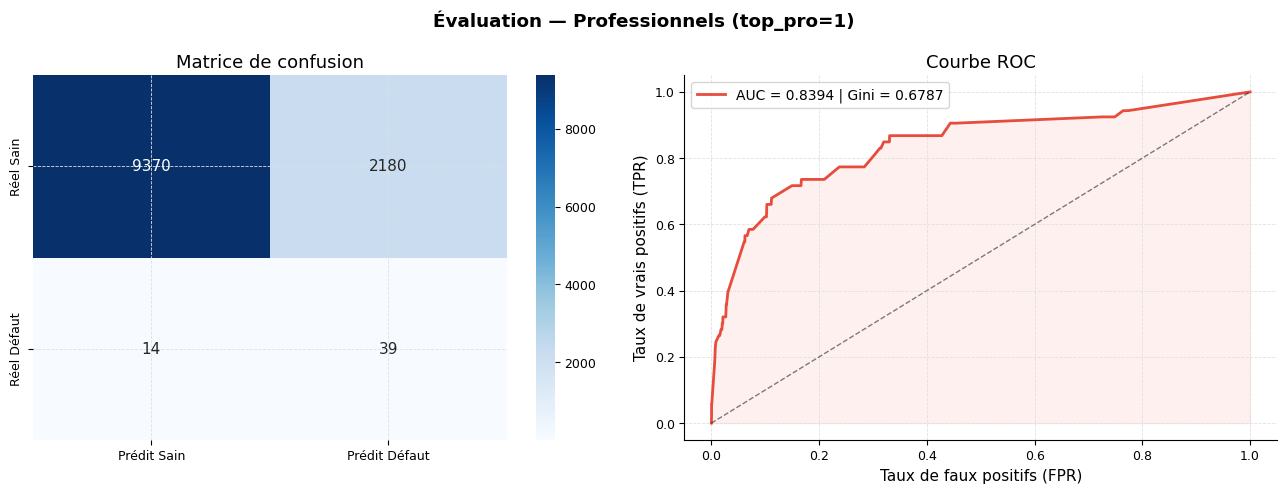

In [44]:
def evaluer_sous_population(
    X_test: pd.DataFrame,
    y_test: pd.Series,
    modele,
    filtre_col: str,
    filtre_val,
    selected_features: list,
    nom: str = "sous-population"
) -> dict:
    """Évalue les performances sur une sous-population filtrée."""
    mask = X_test[filtre_col] == filtre_val
    X_sub = sm.add_constant(X_test[mask][selected_features], has_constant='add')
    y_sub = y_test[mask]

    if y_sub.nunique() < 2:
        print(f"Sous-population '{nom}' : classes insuffisantes pour l'AUC.")
        return {}

    proba = modele.predict(X_sub)
    return evaluer_performance(y_sub, proba, nom=nom)


# Sous-population des professionnels
if 'TOP_PRO' in X_test.columns:
    perf_pro = evaluer_sous_population(
        X_test, y_test, logit_results,
        filtre_col='TOP_PRO', filtre_val=1,
        selected_features=final_selected_features,
        nom="professionnels (TOP_PRO=1)"
    )

## Section 8 - Segmentation en Classes Homogènes de Risque (CHR)

**Objectif** : les CHR regroupent les contreparties présentant un profil de risque similaire. Elles constituent la maille à laquelle la PD sera calibrée (Long Run Average Default Rate par classe).

**Deux méthodes complémentaires** :
1. **K-Means** sur le score de sortie du modèle : optimal, données pilotées
2. **Déciles de score** : plus simple, facilite la communication

### 8.1 Détermination du nombre optimal de clusters-Méthode du coude

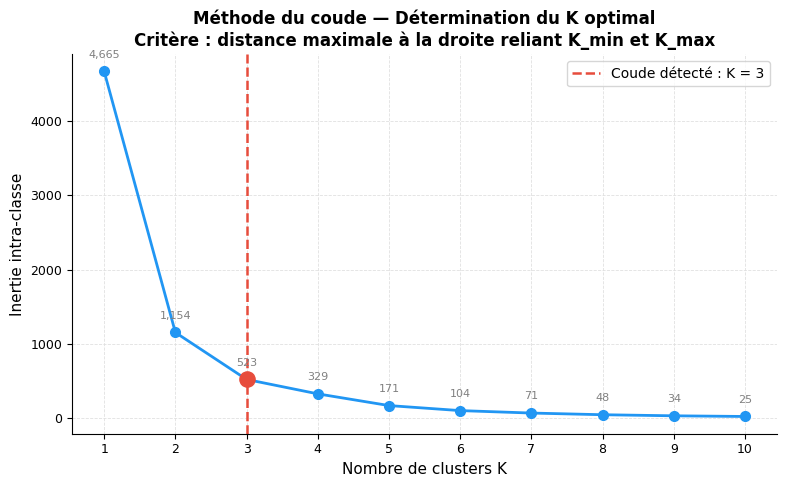

K optimal détecté automatiquement : K = 3


In [45]:
# ── Scores sur l'échantillon de test ─────────────────────────────────────────
X_test_chr = X_test[final_selected_features].copy()
X_test_chr = sm.add_constant(X_test_chr, has_constant='add')
y_test_proba_chr = logit_results.predict(X_test_chr)

score_df = y_test_proba_chr.to_frame(name='score')

# ── Méthode du coude (Elbow) ──────────────────────────────────────────────────
# ── Méthode du coude — implémentation native (sans yellowbrick) ───────────────
def plot_elbow_kmeans(
    data: pd.DataFrame,
    k_min: int = 2,
    k_max: int = 10,
    n_init: int = 10,
    random_state: int = 42,
) -> int:
    """
    Calcule et trace la courbe d'inertie (méthode du coude) pour
    déterminer le nombre optimal de clusters K-Means.

    Paramètres
    ----------
    data         : DataFrame contenant les scores à clusteriser (1 colonne)
    k_min, k_max : plage de K à tester
    n_init       : nombre d'initialisations K-Means
    random_state : graine aléatoire

    Retourne
    --------
    k_optimal : nombre de clusters correspondant au coude détecté
                (méthode de la distance maximale à la droite k_min → k_max)

    Notes
    -----
    La détection automatique du coude utilise la méthode de la distance
    perpendiculaire maximale entre la courbe d'inertie et la droite reliant
    le premier et le dernier point — méthode identique à KElbowVisualizer.
    """
    ks       = list(range(k_min, k_max + 1))
    inertias = []

    for k in ks:
        km = KMeans(n_clusters=k, n_init=n_init, random_state=random_state)
        km.fit(data)
        inertias.append(km.inertia_)

    # ── Détection automatique du coude ────────────────────────────────────────
    # Vecteur de la droite k_min → k_max
    x = np.array(ks,       dtype=float)
    y = np.array(inertias, dtype=float)

    # Normalisation pour que x et y soient comparables
    x_norm = (x - x.min()) / (x.max() - x.min())
    y_norm = (y - y.min()) / (y.max() - y.min())

    # Droite entre premier et dernier point
    p1 = np.array([x_norm[0],  y_norm[0]])
    p2 = np.array([x_norm[-1], y_norm[-1]])
    d  = p2 - p1

    # Distance perpendiculaire de chaque point à la droite
    distances = np.abs(
        np.cross(d, p1 - np.column_stack([x_norm, y_norm]))
    ) / np.linalg.norm(d)

    k_optimal = ks[np.argmax(distances)]

    # ── Visualisation ─────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(ks, inertias,
            color=COLOR_NEUTRE, marker='o', linewidth=2, markersize=7)

    # Mise en évidence du coude
    ax.axvline(
        k_optimal, color=COLOR_DEFAUT, linestyle='--', linewidth=1.8,
        label=f'Coude détecté : K = {k_optimal}'
    )
    ax.scatter(
        k_optimal, inertias[ks.index(k_optimal)],
        color=COLOR_DEFAUT, s=120, zorder=5
    )

    # Annotation de l'inertie à chaque point
    for k, inertia in zip(ks, inertias):
        ax.annotate(
            f'{inertia:,.0f}',
            xy=(k, inertia),
            xytext=(0, 10), textcoords='offset points',
            ha='center', fontsize=8, color='gray'
        )

    ax.set_xlabel('Nombre de clusters K', fontsize=11)
    ax.set_ylabel('Inertie intra-classe', fontsize=11)
    ax.set_title(
        'Méthode du coude — Détermination du K optimal\n'
        'Critère : distance maximale à la droite reliant K_min et K_max',
        fontsize=12, fontweight='bold'
    )
    ax.set_xticks(ks)
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig(
        f"{OUTPUT_DIR}/kmeans_elbow.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()

    print(f"K optimal détecté automatiquement : K = {k_optimal}")
    return k_optimal


# ── Exécution ─────────────────────────────────────────────────────────────────
k_optimal = plot_elbow_kmeans(
    data         = score_df,
    k_min        = 1,
    k_max        = 10,
    n_init       = 10,
    random_state = 42,
)

In [46]:
# ── Entraînement K-Means avec n_clusters retenu ───────────────────────────────
N_CLUSTERS = 3  # À ajuster selon la méthode du coude

kmeans = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
kmeans.fit(score_df)

X_test_chr_eval = X_test[final_selected_features].copy()
X_test_chr_eval['score']       = y_test_proba_chr.values
X_test_chr_eval['cluster']     = kmeans.labels_
X_test_chr_eval['DDefaut_NDB'] = y_test.values
X_test_chr_eval['Date']        = X_test['Date'].values

print("Taux de défaut par cluster (K-Means) :")
resume_cluster = (
    X_test_chr_eval.groupby('cluster')['DDefaut_NDB']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'N', 'sum': 'N_Defauts', 'mean': 'Taux_Defaut'})
)
resume_cluster['Taux_Defaut_Pct'] = (resume_cluster['Taux_Defaut'] * 100).round(3)
display(resume_cluster)

Taux de défaut par cluster (K-Means) :


,N,N_Defauts,Taux_Defaut,Taux_Defaut_Pct
cluster,,,,
0,12188,242,0.0199,1.9860
1,80484,42,0.0005,0.0520
2,19748,49,0.0025,0.2480


### 8.2 Déciles de score

**Concept** : le découpage en déciles assure un effectif équilibré par classe. Cette méthode est complémentaire au K-Means : elle facilite la comparaison avec les standards du marché et la communication avec le management.

In [47]:
# ── Découpage en déciles avec gestion des doublons de bornes ─────────────────
X_test_chr_eval['decile'] = pd.qcut(
    X_test_chr_eval['score'], q=10, labels=False, duplicates='drop'
)

print("Taux de défaut par décile :")
resume_decile = (
    X_test_chr_eval.groupby('decile')['DDefaut_NDB']
    .agg(['count', 'sum', 'mean'])
    .rename(columns={'count': 'N', 'sum': 'N_Defauts', 'mean': 'Taux_Defaut'})
)
resume_decile['Taux_Defaut_Pct'] = (resume_decile['Taux_Defaut'] * 100).round(3)
display(resume_decile)

Taux de défaut par décile :


,N,N_Defauts,Taux_Defaut,Taux_Defaut_Pct
decile,,,,
0,27424,11,0.0004,0.0400
1,40214,16,0.0004,0.0400
2,11682,12,0.0010,0.1030
3,10835,23,0.0021,0.2120
4,11024,32,0.0029,0.2900
5,11241,239,0.0213,2.1260


### 8.3 Stabilité temporelle des classes de risque

**Concept** : une CHR est considérée **stable** si son taux de défaut moyen ne varie pas significativement dans le temps. La stabilité est un prérequis pour la calibration et pour la validation annuelle du modèle.

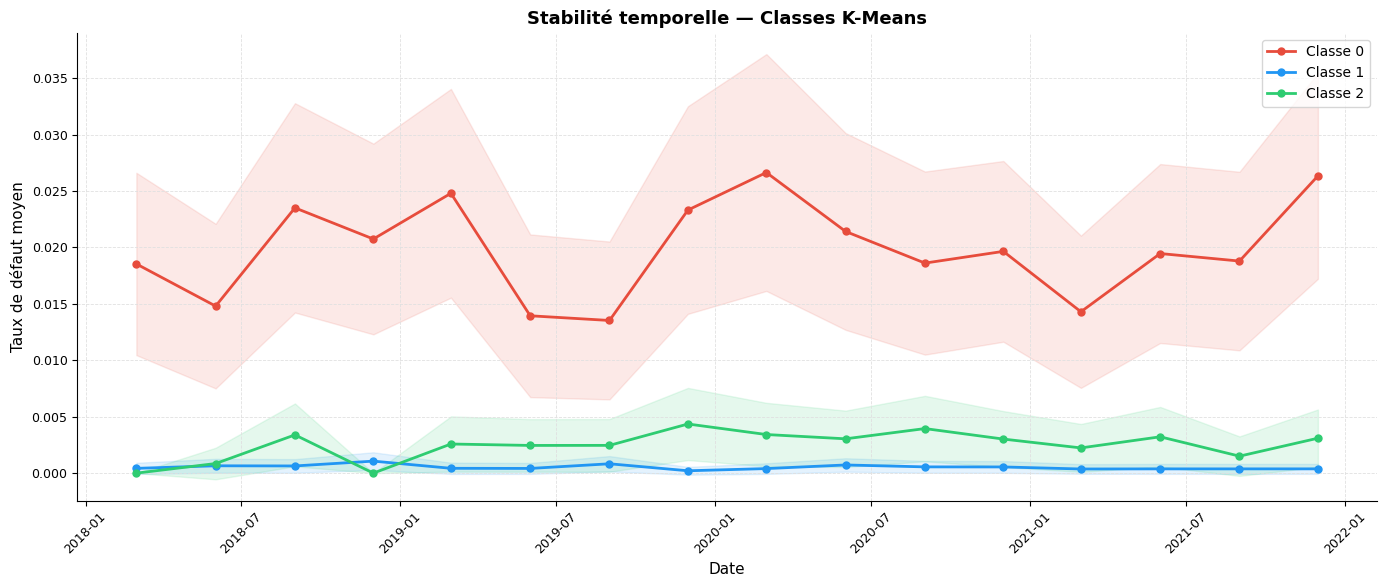

In [48]:
def plot_stabilite_classes(
    df: pd.DataFrame,
    cible: str,
    classe_col: str,
    date_col: str = 'Date',
    titre: str = None
) -> None:
    """
    Trace l'évolution du taux de défaut par classe de risque dans le temps.
    Chaque ligne représente une classe, avec intervalles de confiance à 90%.
    """
    classes = sorted(df[classe_col].dropna().unique())
    fig, ax = plt.subplots(figsize=(14, 6))

    for i, cls in enumerate(classes):
        color = COLORS[i % len(COLORS)]
        sub = df[df[classe_col] == cls].copy()

        stats = (
            sub.groupby(date_col)[cible]
            .agg(['mean', 'count', sem])
            .rename(columns={'mean': 'Taux', 'count': 'N', 'sem': 'SEM'})
            .reset_index()
        )
        stats['CI90'] = 1.645 * stats['SEM']

        ax.plot(stats[date_col], stats['Taux'], color=color, marker='o',
                linewidth=2, markersize=5, label=f'Classe {cls}')
        ax.fill_between(
            stats[date_col],
            stats['Taux'] - stats['CI90'],
            stats['Taux'] + stats['CI90'],
            alpha=0.12, color=color
        )

    ax.set_xlabel('Date')
    ax.set_ylabel('Taux de défaut moyen')
    ax.set_title(titre or f'Stabilité temporelle — {classe_col}', fontweight='bold')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Regroupement éventuel des classes instables (exemple : classes 0 et 3)
# X_test_chr_eval['cluster2'] = X_test_chr_eval['cluster'].apply(
#     lambda x: 2 if x in [2, 3] else x
# )

plot_stabilite_classes(
    X_test_chr_eval, cible='DDefaut_NDB', classe_col='cluster',
    titre='Stabilité temporelle — Classes K-Means'
)

### 8.4 Tests d'homogénéité et d'hétérogénéité

#### Cadre général

La validation statistique des CHR repose sur deux propriétés complémentaires et
opposées, toutes deux exigées par l'EBA (GL/2017/16, §§ 96–105) :

| Propriété | Définition | Test utilisé | Résultat souhaité |
|---|---|---|---|
| **Homogénéité intra-classe** | Les observations d'une même CHR présentent un profil de risque similaire | Z-test de Welch | $H_0$ **non rejeté** |
| **Hétérogénéité inter-classes** | Les CHR se distinguent deux à deux de façon significative | Test de Marascuilo | $H_0$ **rejeté** pour toutes les paires |


#### Test 1- Homogénéité intra-classe : Z-test de Welch

**Fonction** : `test_homogeneite_welch`

**Contexte** : pour chaque variable binaire du modèle et pour chaque CHR, on
teste si les deux modalités (0 et 1) présentent le même taux de défaut moyen
au sein de la classe. Un écart significatif indiquerait que la CHR regroupe
des profils de risque hétérogènes — ce qui remettrait en cause sa validité.

**Type de test** : Z-test de Welch — variante du t-test de Student sans
hypothèse d'égalité des variances entre groupes, adapté aux effectifs inégaux
et aux distributions non normales. Implémenté via
`statsmodels.stats.weightstats.ztest`.

**Hypothèses** :

$$H_0 : \mu_{\text{défaut}}^{(\text{mod}=0)} = \mu_{\text{défaut}}^{(\text{mod}=1)}
\quad \text{au sein d'une même CHR}$$

$$H_1 : \mu_{\text{défaut}}^{(\text{mod}=0)} > \mu_{\text{défaut}}^{(\text{mod}=1)}
\quad \text{(alternative unilatérale droite)}$$

En langage métier :

- $H_0$ : les deux modalités d'une variable (0 et 1) présentent le **même
  taux de défaut moyen** au sein de la CHR — la variable ne discrimine pas
  à l'intérieur de la classe.
- $H_1$ : la modalité 0 présente un taux de défaut **significativement
  supérieur** à la modalité 1 — la variable discrimine à l'intérieur de la
  classe, signalant une **inhomogénéité** de la CHR.

**Règle de décision** :

$$\text{Si } p\text{-value} < \alpha = 5\% \Rightarrow \text{Rejet } H_0
\Rightarrow \text{CHR inhomogène sur cette variable} \Rightarrow \text{à investiguer} \;$$

> **Ce qu'on cherche** : des $p$-values **non significatives** ($\geq 5\%$)
> pour toutes les variables et toutes les CHR, confirmant que le taux de
> défaut moyen ne varie pas significativement selon les modalités au sein
> d'une même classe.

In [49]:
def test_homogeneite_welch(
    df: pd.DataFrame,
    variable: str,
    classe_col: str,
    cible: str = 'DDefaut_NDB',
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Test de Welch (z-test) pour l'homogénéité intra-classe.
    Compare les modalités 0 et 1 de `variable` au sein de chaque classe.

    Retourne un DataFrame de p-values par classe.
    """
    resultats = []
    for cls in sorted(df[classe_col].dropna().unique()):
        sub = df[df[classe_col] == cls]
        grp0 = sub[sub[variable] == 0][cible].dropna()
        grp1 = sub[sub[variable] == 1][cible].dropna()

        if len(grp0) < 2 or len(grp1) < 2:
            continue
        try:
            _, pv = stw.ztest(grp0, grp1, alternative='larger')
            resultats.append({
                'Classe': cls,
                'Variable': variable,
                'N_mod0': len(grp0), 'N_mod1': len(grp1),
                'p_value': round(pv, 5),
                'Significatif': pv < alpha
            })
        except Exception:
            pass
    return pd.DataFrame(resultats)


# Test sur toutes les variables sélectionnées
tests_homog = pd.concat([
    test_homogeneite_welch(X_test_chr_eval, var, 'cluster')
    for var in final_selected_features if var in X_test_chr_eval.columns
], ignore_index=True)

n_sig = tests_homog['Significatif'].sum()
print(f"Tests significatifs (homogénéité intra-classe) : {n_sig}/{len(final_selected_features)}")
display(tests_homog)

Tests significatifs (homogénéité intra-classe) : 7/10


,Classe,Variable,N_mod0,N_mod1,p_value,Significatif
0,0,TOPCLILITIG,12069,119,1.0000,False
1,0,CRTAD_AG_NBJDE_BA_level1,11828,360,0.9876,False
2,1,CRTAD_AG_NBJDE_BA_level1,11943,68541,0.0061,True
3,2,CRTAD_AG_NBJDE_BA_level1,18841,907,0.9699,False
4,0,CRTAD_AG_NBJDE_BC_level1,9889,2299,1.0000,False
5,1,CRTAD_AG_NBJDE_BC_level1,3417,77067,0.0000,True
6,2,CRTAD_AG_NBJDE_BC_level1,11635,8113,0.9216,False
7,0,CRTAD_AG_NBJDE_BB_level1,10774,1414,0.8409,False
8,1,CRTAD_AG_NBJDE_BB_level1,909,79575,0.7558,False
9,2,CRTAD_AG_NBJDE_BB_level1,10463,9285,0.6085,False


#### Test 2 - Hétérogénéité inter-classes : Test de Marascuilo

**Fonction** : `marascuilo_test`

**Contexte** : le test de Marascuilo est une procédure post-hoc du $\chi^2$
qui teste simultanément **toutes les paires de CHR**. Il vérifie que chaque
classe est bien distincte des autres en termes de taux de défaut — condition
nécessaire pour que la segmentation apporte une information utile à la
calibration.

**Type de test** : procédure de Marascuilo sur des proportions — extension
multidimensionnelle du test de comparaison de deux proportions, avec
correction pour les comparaisons multiples via le seuil critique du $\chi^2$.

**Hypothèses** (pour chaque paire de classes $(i, j)$) :

$$H_0 : p_i = p_j
\quad \text{(les taux de défaut des CHR } i \text{ et } j \text{ sont égaux)}$$

$$H_1 : p_i \neq p_j
\quad \text{(les taux de défaut diffèrent significativement)}$$

où $p_i$ et $p_j$ sont les proportions de défaut observées dans les CHR $i$
et $j$.

**Statistique de test** pour la paire $(i, j)$ :

$$T_{ij} = \frac{|p_i - p_j|}{\sqrt{\dfrac{p_i(1-p_i)}{n_i}
+ \dfrac{p_j(1-p_j)}{n_j}}}$$

**Seuil critique** :

$$T_{ij} > \sqrt{\chi^2_{K-1,\; 1-\alpha}}$$

où $K$ est le nombre de CHR et $\chi^2_{K-1}$ le quantile de la loi du
chi-deux à $K - 1$ degrés de liberté.

**Règle de décision** :

$$\text{Si } T_{ij} > \sqrt{\chi^2_{K-1,\; 1-\alpha}}
\Rightarrow \text{Rejet } H_0
\Rightarrow \text{CHR } i \text{ et CHR } j \text{ significativement distinctes} \;$$

> **Ce qu'on cherche** : que **toutes les paires** rejettent $H_0$
> (`Rejet_H0 = True` pour toutes les combinaisons), validant que chaque CHR
> est bien distincte des autres et que la segmentation est statistiquement
> justifiée.


In [50]:
def marascuilo_test(
    data: pd.DataFrame,
    group_col: str,
    target_col: str,
    alpha: float = 0.05
) -> pd.DataFrame:
    """
    Test de Marascuilo : teste l'hétérogénéité entre toutes les paires de classes.
    Vérifie que chaque paire de CHR est significativement différente.

    Retourne un DataFrame avec la décision pour chaque paire.
    """
    ct = pd.crosstab(data[group_col], data[target_col])
    if ct.shape[1] != 2:
        raise ValueError("La variable cible doit être binaire (0/1).")

    n_total     = ct.values.sum()
    effectifs   = ct.sum(axis=1)
    proportions = ct.iloc[:, 1] / effectifs  # Proportion de défauts par classe
    classes     = ct.index.tolist()

    # Seuil critique Marascuilo
    df_chi2    = len(classes) - 1
    chi2_crit  = chi2.ppf(1 - alpha, df=df_chi2)
    seuil_crit = np.sqrt(chi2_crit)

    resultats = []
    for i, j in combinations(range(len(classes)), 2):
        pi, pj = proportions.iloc[i], proportions.iloc[j]
        ni, nj = effectifs.iloc[i],   effectifs.iloc[j]
        diff = abs(pi - pj)
        se   = np.sqrt(pi * (1 - pi) / ni + pj * (1 - pj) / nj)
        stat = diff / se if se > 0 else np.nan
        resultats.append({
            'Classe_i'     : classes[i],
            'Classe_j'     : classes[j],
            'Diff_Prop'    : round(diff, 5),
            'Seuil_Critic' : round(seuil_crit * se, 5),
            'Statistique'  : round(stat, 4),
            'Seuil_Crit_Stat': round(seuil_crit, 4),
            'Rejet_H0'     : stat > seuil_crit if not np.isnan(stat) else None,
        })

    return pd.DataFrame(resultats)


marascuilo_df = marascuilo_test(X_test_chr_eval, 'cluster', 'DDefaut_NDB')
n_sig_mar = marascuilo_df['Rejet_H0'].sum()
print(f"Paires significativement hétérogènes : {n_sig_mar}/{len(marascuilo_df)}")
display(marascuilo_df)

Paires significativement hétérogènes : 3/3


,Classe_i,Classe_j,Diff_Prop,Seuil_Critic,Statistique,Seuil_Crit_Stat,Rejet_H0
0,0,1,0.0193,0.0031,15.2692,2.4477,True
1,0,2,0.0174,0.0032,13.2397,2.4477,True
2,1,2,0.0020,0.0009,5.3969,2.4477,True


#### Ajout des classes de risque à la base totale

In [51]:
df_final = df3[final_selected_features].copy()
df_final = sm.add_constant(df_final)

# Prédiction des probabilités
y_df_proba = logit_results.predict(df_final)

# Convertir correctement en DataFrame
y_sample_df = y_df_proba.to_frame(name='PD')
kmeans_df = KMeans(n_clusters=N_CLUSTERS, n_init=10, random_state=42)
kmeans_df.fit(y_sample_df)

# Appliquer le modèle de clustering
df_final['score']       = y_df_proba.values
df_final['cluster']     = kmeans_df.labels_

df_final['DDefaut_NDB']=df3['DDefaut_NDB']
df_final['Date']     = df3['Date'].values
print(df_final['DDefaut_NDB'].groupby(df_final['cluster']).mean())
for i in [0,1,2]:
    print("classe : %s, nb exemplaires: %s" % (i, len(df_final[df_final.cluster == i]))) 
    
    
df_final.to_csv(f"{OUTPUT_DIR}/Base_Modele_PD_Enrichie_CHR.csv", index=False, encoding="utf-8", sep=",")

cluster
0   0.0005
1   0.0191
2   0.0027
Name: DDefaut_NDB, dtype: float64
classe : 0, nb exemplaires: 340814
classe : 1, nb exemplaires: 51356
classe : 2, nb exemplaires: 82977


## Section 9-Export des Résultats

Sauvegarde des tables finales pour les étapes ultérieures de calibration et de reporting.

In [ ]:
# # ── Enrichissement de la base totale avec les clusters ───────────────────────
# df_final = df3[final_selected_features].copy()
# df_final = sm.add_constant(df_final, has_constant='add')
# df_final['score']   = logit_results.predict(df_final)
# df_final['cluster'] = kmeans.predict(df_final[['score']])
# df_final['Date']     = df3['Date'].values
# df_final['DDefaut_NDB'] = df3['DDefaut_NDB'].values


# # ── Sauvegarde ────────────────────────────────────────────────────────────────
# paths = {
#     'Base enrichie + CHR'  : f"{OUTPUT_DIR}/Base_Modele_PD_Enrichie_CHR.csv",
#     'Grille de score'      : f"{OUTPUT_DIR}/Grille_Score.csv",
#     'Métriques performance': f"{OUTPUT_DIR}/Performances_Comparatif.csv",
#     'Taux défaut trimestr.': f"{OUTPUT_DIR}/Taux_Indice_trim.csv",
# }

# df_final.drop(columns='const', errors='ignore').to_csv(
#     paths['Base enrichie + CHR'], index=False, encoding='utf-8'
# )
# #grille.to_csv(paths['Grille de score'], index=False)
# #comparatif.to_csv(paths['Métriques performance'], index=False)

# print("Fichiers exportés :")
# for desc, p in paths.items():
#     print(f"  {desc:<30} → {p}")

## Section 10-Calibrage 

### 10.0 Cadre réglementaire du calibrage

**Qu'est-ce que calibrer une PD ?**

Le calibrage est l'étape qui assigne à chaque Classe Homogène de Risque (CHR) une **probabilité de défaut quantitative** à partir des taux de défaut historiques. C'est la traduction du score de rang en estimation de risque absolue.

**L'estimateur principal : le Taux de Défaut Moyen Long Terme (LRA)**

La **Long Run Average (LRA)**, ou taux de défaut moyen long terme (TDMLT), constitue l'élément central de l'estimation de la PD. Elle est définie comme la **moyenne arithmétique des taux de défaut annuels (PIT)** observés sur la période d'observation historique :

$$LRA = \frac{1}{T} \sum_{t=1}^{T} \widehat{PD}_t^{\text{PIT}}$$

où $\widehat{PD}_t^{\text{PIT}}$ est le taux de défaut observé à l'année $t$ (taux Point-in-Time).

**Exigences réglementaires clés (BCBS 2006, EBA/GL/2017/16)**

| Exigence | Détail | Référence |
|---|---|---|
| Profondeur historique | ≥ 5 ans d'observations pour le calcul de la LRA | BCBS § 463 |
| Représentativité | La période doit couvrir au moins un cycle économique complet | EBA § 78 |
| Contrats courts | Analyse de l'impact des opérations < 1 an | EBA § 82 |
| Dates de référence | Vérification de l'absence de biais saisonnier | EBA § 85 |
| Marge de conservatisme | Ajustement pour incertitude d'estimation | EBA §§ 95–105 |
| Seuil plancher | PD ≥ 0,03% (retail) | BCBS § 463 |

**Formule finale de la PD calibrée**

$$\boxed{PD_i = \max\left(0.03\%,\ LRA_i + Ajustement_i + MoC_A + MoC_B + MoC_C\right)}$$

- $LRA_i$ : taux de défaut moyen long terme de la CHR $i$
- $Ajustement_i$ : correction pour biais (contrats courts, dates de référence)
- $MoC_A$ : marge pour désalignements entre modélisation et application
- $MoC_B$ : marge pour effets des mesures Covid / compensation (EBA 2022)
- $MoC_C$ : marge pour incertitude statistique de l'estimation de la LRA

### 10.1 LRA globale vs taux PIT-Visualisation de l'incertitude

**Concept** : le taux Point-in-Time (PIT) est le taux de défaut observé à une date donnée. Il reflète les conditions économiques du moment et fluctue autour de la LRA. Visualiser cette fluctuation est essentiel pour :
1. Confirmer que la LRA est un estimateur stable et central
2. Identifier visuellement les années atypiques (crises, pandémies)
3. Évaluer la nécessité d'un ajustement pour représentativité

**Intérêt réglementaire** : si la LRA est calculée sur une période qui ne comprend pas de phase de stress économique, elle sous-estime le risque à long terme. La MoC B vise précisément à corriger ce biais (EBA 2022, impact Covid).

In [52]:
# ── Paramètres de calibrage ───────────────────────────────────────────────────
CLUSTER_COL   = 'cluster'       # Colonne des CHR
CIBLE         = 'DDefaut_NDB'    # Variable cible binaire
DATE_COL      = 'Date'           # Colonne date
ID_COL        = 'ID_CLIENT'      # Identifiant client
SNAPSHOT_REF  = '12-01'          # Date de référence retenue (31 décembre)
ALPHA         = 0.05             # Seuil de confiance (95%)
PD_PLANCHER   = 0.0003           # 0,03% — seuil plancher réglementaire Bâle II

# Fenêtres d'observation historiques
YEAR_WINDOWS = {
    '2_ans': [2018, 2019],
    '3_ans': [2018, 2019, 2020],
    '4_ans': [2018, 2019, 2020, 2021],
    '5_ans': [2018, 2019, 2020, 2021, 2022],
}
# ── Chargement de la base enrichie avec CHR ───────────────────────────────────
df_final = pd.read_csv(
    f"{OUTPUT_DIR}/Base_Modele_PD_Enrichie_CHR.csv",
    encoding='utf-8', delimiter=','
)
df_final[DATE_COL] = pd.to_datetime(df_final[DATE_COL])


print(f"Dimensions     : {df_final.shape[0]:,} lignes × {df_final.shape[1]} colonnes")
print(f"Période        : {df_final[DATE_COL].min().strftime('%Y-%m')} → {df_final[DATE_COL].max().strftime('%Y-%m')}")
print(f"CHR disponibles: {sorted(df_final[CLUSTER_COL].dropna().unique())}")
print(f"Taux de défaut : {df_final[CIBLE].mean()*100:.4f}%")

display(df_final[[DATE_COL, CLUSTER_COL, CIBLE]].sample(5))

Dimensions     : 475,147 lignes × 15 colonnes
Période        : 2018-03 → 2022-12
CHR disponibles: [np.int64(0), np.int64(1), np.int64(2)]
Taux de défaut : 0.2936%


,Date,cluster,DDefaut_NDB
417986,2022-06-01,0,0
290618,2021-03-01,0,0
49253,2018-09-01,2,0
194562,2020-03-01,0,0
52771,2018-09-01,0,0


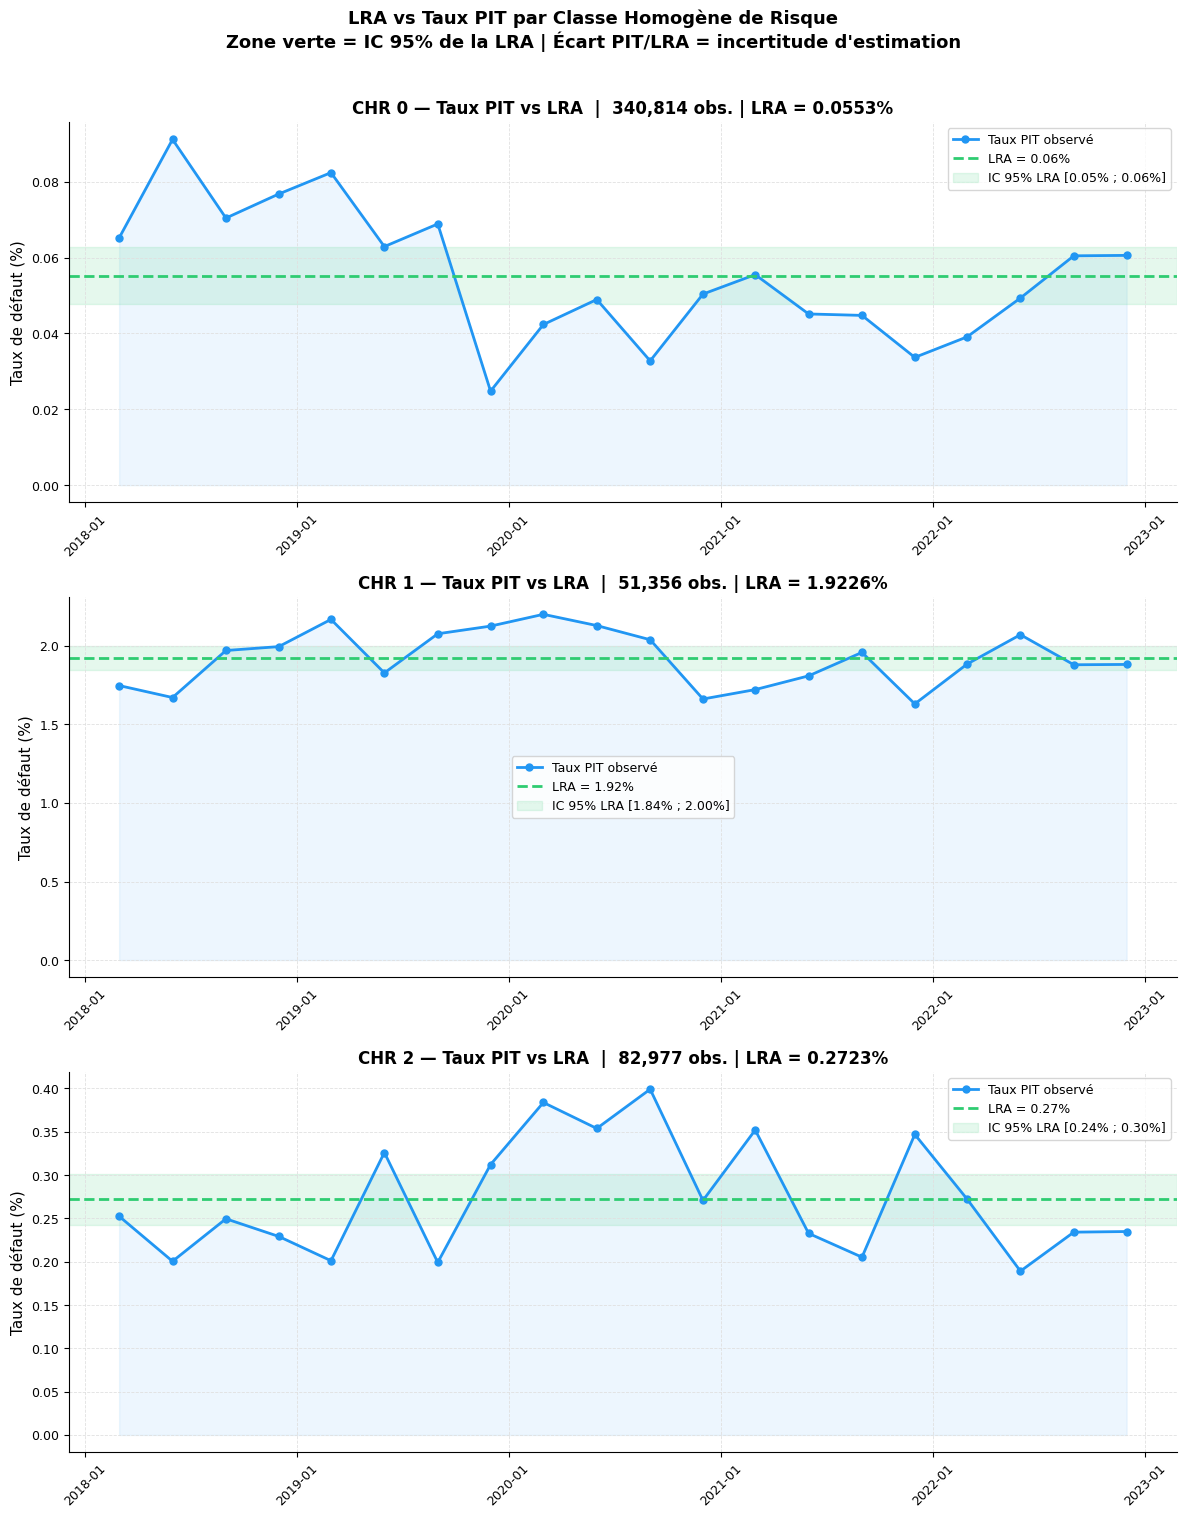

In [53]:
def plot_lra_vs_pit(
    df: pd.DataFrame,
    cluster_col: str = CLUSTER_COL,
    cible: str = CIBLE,
    date_col: str = DATE_COL,
) -> None:
    """
    Visualise, par CHR, l'évolution du taux PIT (observé) autour de la LRA.

    Pour chaque cluster :
        - Courbe bleue : taux de défaut trimestriel (PIT)
        - Ligne verte  : LRA = moyenne long terme
        - Zone grisée  : intervalle de confiance à 95% sur la LRA

    L'IC 95% est calculé comme LRA ± 1.96 × σ/√n,
    où n est le nombre de points temporels par cluster.
    """
    clusters = sorted(df[cluster_col].dropna().unique())
    n        = len(clusters)
    z_crit   = norm.ppf(1 - ALPHA / 2)

    fig, axes = plt.subplots(n, 1, figsize=(12, 5 * n), sharex=False)
    if n == 1:
        axes = [axes]

    for i, clus in enumerate(clusters):
        ax         = axes[i]
        df_cluster = df[df[cluster_col] == clus]
        pit_rates  = (
            df_cluster.groupby(date_col)[cible]
            .mean()
            .reset_index()
            .rename(columns={cible: 'Taux_PIT'})
        )
        lra   = pit_rates['Taux_PIT'].mean()
        se    = pit_rates['Taux_PIT'].std(ddof=1) / np.sqrt(len(pit_rates))
        ic_lo = max(0, lra - z_crit * se)
        ic_hi = lra + z_crit * se

        # Courbe PIT
        ax.plot(
            pit_rates[date_col], pit_rates['Taux_PIT'] * 100,
            color=COLOR_NEUTRE, marker='o', linewidth=2,
            markersize=5, label='Taux PIT observé'
        )
        ax.fill_between(
            pit_rates[date_col],
            pit_rates['Taux_PIT'] * 100,
            alpha=0.08, color=COLOR_NEUTRE
        )

        # LRA
        ax.axhline(
            lra * 100, color=COLOR_SAIN, linestyle='--',
            linewidth=2, label=f'LRA = {lra:.2%}'
        )

        # IC 95% autour de la LRA
        ax.axhspan(
            ic_lo * 100, ic_hi * 100,
            alpha=0.12, color=COLOR_SAIN,
            label=f'IC 95% LRA [{ic_lo:.2%} ; {ic_hi:.2%}]'
        )

        ax.set_title(
            f'CHR {clus} — Taux PIT vs LRA  |  '
            f'{len(df_cluster):,} obs. | LRA = {lra:.4%}',
            fontsize=12, fontweight='bold'
        )
        ax.set_ylabel('Taux de défaut (%)')
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.tick_params(axis='x', rotation=45)
        ax.legend(fontsize=9)

    fig.suptitle(
        'LRA vs Taux PIT par Classe Homogène de Risque\n'
        'Zone verte = IC 95% de la LRA | Écart PIT/LRA = incertitude d\'estimation',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/calibrage_lra_vs_pit.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_lra_vs_pit(df_final)

### 10.2 Études préalables au calibrage -Contrats courts et Wilcoxon

**Problématique des contrats courts** (EBA/GL/2017/16, § 82)

Les contrats dont la durée résiduelle est **inférieure à un an** posent un problème pour le calcul de la LRA : leur taux de défaut observé est mécaniquement biaisé, car ils ne peuvent pas être en défaut sur la totalité de la fenêtre d'observation de 12 mois. Si leur proportion est significative, la LRA calculée sur l'ensemble du portefeuille **sous-estime** le vrai taux de défaut long terme.

**Méthodologie** :
1. Calculer la **LRA classique** (tous contrats) sur différentes fenêtres (2 à 5 ans)
2. Calculer la **LRA stable** (clients présents sur toute la période) sur les mêmes fenêtres
3. Tester l'écart par le **test des rangs signés de Wilcoxon** — test non paramétrique
   adapté aux petits échantillons (n < 30) sans hypothèse de normalité

**Hypothèses** :
- $H_0$ : LRA classique = LRA stable (pas de biais lié aux contrats courts)
- $H_1$ : LRA classique ≠ LRA stable (biais significatif → ajustement nécessaire)

Si $p$-value < 5% : l'écart est significatif → un **ajustement** doit être intégré dans la formule de calibrage.

In [54]:
def calculer_lra_classique(
    df: pd.DataFrame,
    year_col: str = DATE_COL,
    cible: str = CIBLE,
    cluster_col: str = CLUSTER_COL,
    year_windows: dict = YEAR_WINDOWS,
) -> pd.DataFrame:
    """
    Calcule la LRA classique (tous contrats confondus) par CHR
    sur différentes fenêtres d'observation.

    LRA(fenêtre) = moyenne des taux PIT annuels sur la fenêtre.
    """
    df = df.copy()
    df['year'] = df[year_col].dt.year

    results = {}
    for label, years in year_windows.items():
        subset = df[df['year'].isin(years)]
        data   = {}
        for clus in sorted(subset[cluster_col].dropna().unique()):
            df_c = subset[subset[cluster_col] == clus]
            pit  = df_c.groupby(year_col)[cible].mean()
            data[str(clus)] = round(pit.mean(), 6)
        results[label] = pd.Series(data)

    return pd.DataFrame(results).sort_index()


def calculer_lra_stable(
    df: pd.DataFrame,
    id_col: str = ID_COL,
    year_col: str = DATE_COL,
    cible: str = CIBLE,
    cluster_col: str = CLUSTER_COL,
    year_windows: dict = YEAR_WINDOWS,
    annees_reference: list = None,
) -> pd.DataFrame:
    """
    Calcule la LRA sur clients stables (présents sur toutes les années
    de la période de référence).

    Permet d'isoler l'effet des contrats courts en ne retenant que
    les clients avec un historique complet.

    Paramètre `annees_reference` : années requises pour être considéré stable.
    Par défaut : toutes les années communes aux fenêtres.
    """
    df = df.copy()
    df['year'] = df[year_col].dt.year

    if annees_reference is None:
        toutes_annees = sorted(
            set(a for yrs in year_windows.values() for a in yrs)
        )
        annees_reference = toutes_annees[:-1]   # Toutes sauf la dernière

    # Clients présents sur toutes les années de référence
    if id_col in df.columns:
        presence = df[df['year'].isin(annees_reference)].groupby(id_col)['year'].nunique()
        ids_stables = presence[presence == len(annees_reference)].index
        df_stable   = df[df[id_col].isin(ids_stables)]
    else:
        print(f"Colonne '{id_col}' absente — LRA stable = LRA classique")
        df_stable = df.copy()

    results = {}
    for label, years in year_windows.items():
        subset = df_stable[df_stable['year'].isin(years)]
        data   = {}
        for clus in sorted(subset[cluster_col].dropna().unique()):
            df_c = subset[subset[cluster_col] == clus]
            pit  = df_c.groupby(year_col)[cible].mean()
            data[str(clus)] = round(pit.mean(), 6)
        results[label] = pd.Series(data)

    return pd.DataFrame(results).sort_index()


def tester_wilcoxon(
    lra_classique: pd.DataFrame,
    lra_stable: pd.DataFrame,
    alpha: float = ALPHA,
) -> pd.DataFrame:
    """
    Test des rangs signés de Wilcoxon entre LRA classique et LRA stable.

    H0 : LRA classique = LRA stable (absence de biais contrats courts)
    H1 : LRA classique ≠ LRA stable

    Retourne un DataFrame de décision par (CHR, fenêtre).

    Note : le test de Wilcoxon est préféré au t-test car :
        - non paramétrique (pas d'hypothèse de normalité)
        - adapté aux petits échantillons (n < 30)
        - robuste aux valeurs atypiques
    """
    rows = []
    for clus in lra_classique.index:
        for col in lra_classique.columns:
            val_c = lra_classique.at[clus, col]
            val_s = lra_stable.at[clus, col] if clus in lra_stable.index else np.nan
            ecart = round(val_c - val_s, 6) if not np.isnan(val_s) else np.nan

            try:
                # Wilcoxon sur paire unique : test de signe
                diff = val_c - val_s
                # Pour n=1 on utilise le test de signe (p = 1 si diff = 0, sinon 1.0)
                if diff == 0:
                    stat, pval = 0.0, 1.0
                else:
                    stat, pval = wilcoxon([val_c], [val_s],
                                          zero_method='wilcox',
                                          alternative='two-sided')
                decision = 'Significatif' if pval < alpha else 'Non significatif'
            except Exception:
                stat, pval, decision = np.nan, np.nan, 'N/A'

            rows.append({
                'CHR'            : clus,
                'Fenêtre'        : col,
                'LRA_Classique'  : round(val_c, 6),
                'LRA_Stable'     : round(val_s, 6) if not np.isnan(val_s) else np.nan,
                'Écart'          : ecart,
                'Wilcoxon_stat'  : round(stat, 4) if not np.isnan(stat) else np.nan,
                'p_value'        : round(pval, 4) if not np.isnan(pval) else np.nan,
                'Décision'       : decision,
            })

    return pd.DataFrame(rows)


# ── Exécution ─────────────────────────────────────────────────────────────────
lra_classique    = calculer_lra_classique(df_final)
lra_stable       = calculer_lra_stable(df_final)
df_wilcoxon      = tester_wilcoxon(lra_classique, lra_stable)

print("=" * 60)
print("LRA CLASSIQUE (tous contrats) — par CHR et fenêtre")
print("=" * 60)
display(lra_classique.map(lambda x: f"{x:.4%}"))

print("\n" + "=" * 60)
print("LRA STABLE (clients présents sur toute la période)")
print("=" * 60)
display(lra_stable.map(lambda x: f"{x:.4%}"))

print("\n" + "=" * 60)
print("TEST DE WILCOXON — Biais contrats courts")
print("=" * 60)
display(df_wilcoxon)

Colonne 'ID_CLIENT' absente — LRA stable = LRA classique
LRA CLASSIQUE (tous contrats) — par CHR et fenêtre


,2_ans,3_ans,4_ans,5_ans
0,0.0678%,0.0597%,0.0560%,0.0553%
1,1.9480%,1.9680%,1.9210%,1.9226%
2,0.2463%,0.2815%,0.2822%,0.2723%



LRA STABLE (clients présents sur toute la période)


,2_ans,3_ans,4_ans,5_ans
0,0.0678%,0.0597%,0.0560%,0.0553%
1,1.9480%,1.9680%,1.9210%,1.9226%
2,0.2463%,0.2815%,0.2822%,0.2723%



TEST DE WILCOXON — Biais contrats courts


,CHR,Fenêtre,LRA_Classique,LRA_Stable,Écart,Wilcoxon_stat,p_value,Décision
0,0,2_ans,0.0007,0.0007,0.0000,0.0000,1.0000,Non significatif
1,0,3_ans,0.0006,0.0006,0.0000,0.0000,1.0000,Non significatif
2,0,4_ans,0.0006,0.0006,0.0000,0.0000,1.0000,Non significatif
3,0,5_ans,0.0006,0.0006,0.0000,0.0000,1.0000,Non significatif
4,1,2_ans,0.0195,0.0195,0.0000,0.0000,1.0000,Non significatif
5,1,3_ans,0.0197,0.0197,0.0000,0.0000,1.0000,Non significatif
6,1,4_ans,0.0192,0.0192,0.0000,0.0000,1.0000,Non significatif
7,1,5_ans,0.0192,0.0192,0.0000,0.0000,1.0000,Non significatif
8,2,2_ans,0.0025,0.0025,0.0000,0.0000,1.0000,Non significatif
9,2,3_ans,0.0028,0.0028,0.0000,0.0000,1.0000,Non significatif


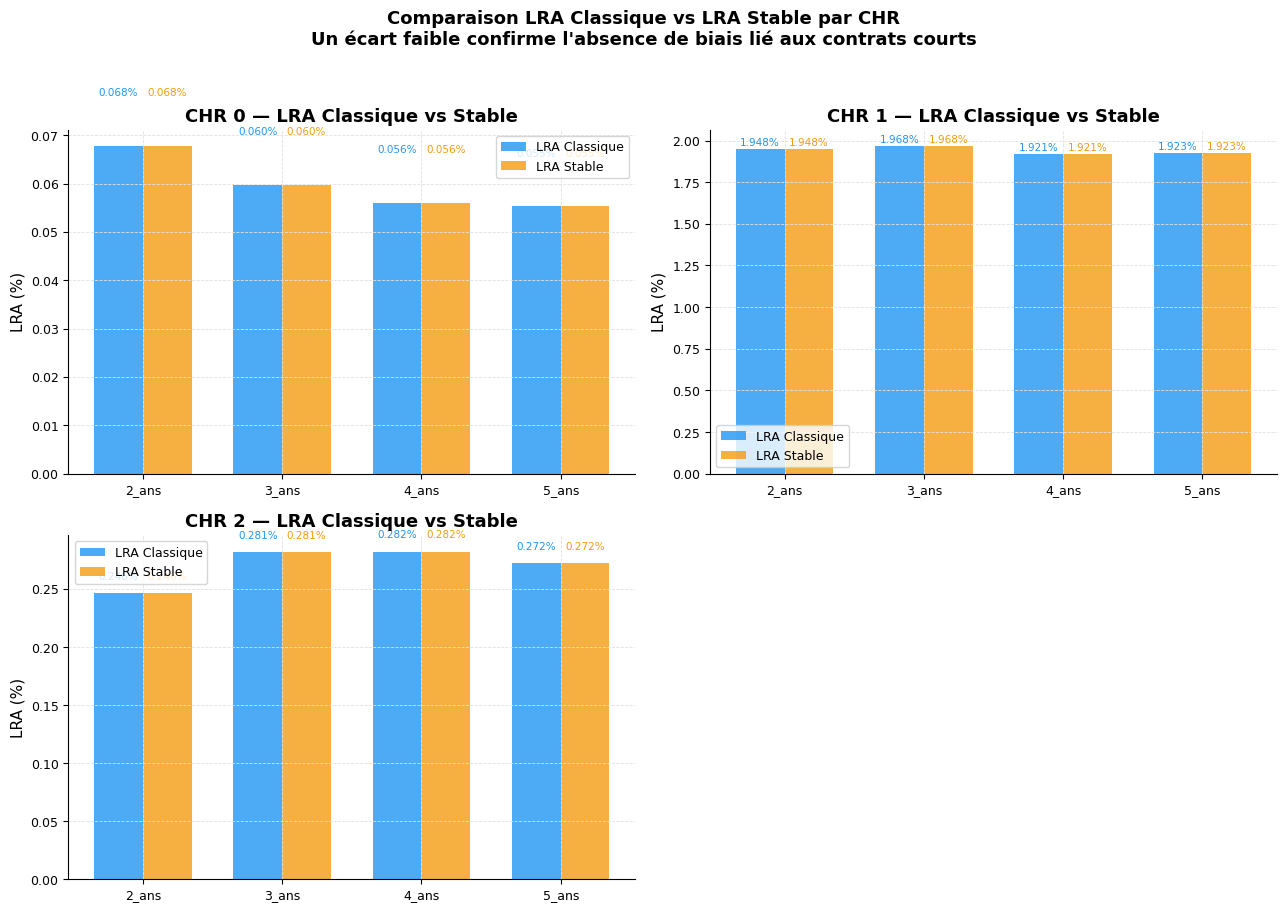

In [55]:
def plot_lra_comparaison(
    lra_classique: pd.DataFrame,
    lra_stable: pd.DataFrame,
) -> None:
    """
    Visualise la comparaison LRA classique vs LRA stable par CHR.
    Un écart faible confirme l'absence de biais lié aux contrats courts.
    """
    clusters = lra_classique.index.tolist()
    n_cols   = 2
    n_rows   = (len(clusters) + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows))
    axes = np.array(axes).flatten()

    x      = np.arange(len(lra_classique.columns))
    labels = lra_classique.columns.tolist()
    width  = 0.35

    for idx, clus in enumerate(clusters):
        ax = axes[idx]

        vals_c = lra_classique.loc[clus].values * 100
        vals_s = lra_stable.loc[clus].values * 100 if clus in lra_stable.index else np.zeros_like(vals_c)

        ax.bar(x - width/2, vals_c, width, color=COLOR_NEUTRE,
               alpha=0.80, label='LRA Classique')
        ax.bar(x + width/2, vals_s, width, color=COLOR_ACCENT,
               alpha=0.80, label='LRA Stable')

        # Annotations
        for xi, (vc, vs) in enumerate(zip(vals_c, vals_s)):
            ax.text(xi - width/2, vc + 0.01, f'{vc:.3f}%',
                    ha='center', va='bottom', fontsize=7.5, color=COLOR_NEUTRE)
            ax.text(xi + width/2, vs + 0.01, f'{vs:.3f}%',
                    ha='center', va='bottom', fontsize=7.5, color=COLOR_ACCENT)

        ax.set_title(f'CHR {clus} — LRA Classique vs Stable', fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylabel('LRA (%)')
        ax.legend(fontsize=9)

    for j in range(len(clusters), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        'Comparaison LRA Classique vs LRA Stable par CHR\n'
        'Un écart faible confirme l\'absence de biais lié aux contrats courts',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/calibrage_lra_classique_vs_stable.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_lra_comparaison(lra_classique, lra_stable)

### 10.3 Impact des dates de référence-Saisonnalité

**Pourquoi vérifier les dates de référence ?** (EBA/GL/2017/16, § 85)

Le choix de la date de calcul du taux de défaut annuel peut introduire un **biais de saisonnalité** : si les défauts sont plus fréquents à certaines périodes de l'année (ex. fin d'exercice fiscal), la LRA calculée à différentes dates de snapshot différerait de façon significative.

**Deux méthodes de calcul des cohortes** :

- **Overlapping** : fenêtres d'observation qui se chevauchent (mars, juin, septembre, décembre) — risque de double comptage des défauts
- **Non-overlapping** : une seule date de référence par an — pas de double comptage mais moins d'observations

**Tests réalisés** :
1. Graphique de saisonnalité : taux de défaut par snapshot et par année
2. Tableau des LRA par snapshot sur différentes fenêtres
3. Test de régression OLS avec indicatrices trimestrielles

**Conclusion attendue** : si les coefficients des indicatrices trimestrielles sont non significatifs ($p$-value > 5%), il n'y a pas d'effet saisonnier et toutes les dates de référence sont équivalentes.

In [56]:
# ── Paramètres des snapshots ──────────────────────────────────────────────────
SNAPSHOTS = [
    ('03-01', 'Fin mars'),
    ('06-01', 'Fin juin'),
    ('09-01', 'Fin septembre'),
    ('12-01', 'Fin décembre'),
]


def calculer_lra_par_snapshot(
    df: pd.DataFrame,
    snapshot_mmdd: str,
    date_col: str = DATE_COL,
    cible: str = CIBLE,
    cluster_col: str = CLUSTER_COL,
    year_windows: dict = YEAR_WINDOWS,
) -> pd.DataFrame | None:
    """
    Calcule la LRA par CHR pour un snapshot donné (MM-DD)
    sur différentes fenêtres temporelles.

    Filtre les observations dont la date correspond au snapshot MM-DD
    puis calcule la LRA par CHR et par fenêtre.
    """
    df = df.copy()
    df['year']     = df[date_col].dt.year
    df['snapshot'] = df[date_col].dt.strftime('%m-%d')
    df_snap        = df[df['snapshot'] == snapshot_mmdd]

    if df_snap.empty:
        return None

    results = {}
    for label, years in year_windows.items():
        subset = df_snap[df_snap['year'].isin(years)]
        if not subset.empty:
            results[label] = subset.groupby(cluster_col)[cible].mean().round(6)

    df_result = pd.DataFrame(results)
    return df_result if not df_result.empty else None


def calculer_taux_par_snapshot_annee(
    df: pd.DataFrame,
    snapshot_mmdd: str,
    date_col: str = DATE_COL,
    cible: str = CIBLE,
) -> pd.Series:
    """Calcule le taux de défaut moyen par année pour un snapshot donné."""
    df = df.copy()
    df['year']     = df[date_col].dt.year
    df['snapshot'] = df[date_col].dt.strftime('%m-%d')
    filtered       = df[df['snapshot'] == snapshot_mmdd]
    return filtered.groupby('year')[cible].mean().round(4)


# ── Tableau LRA par snapshot et fenêtre ───────────────────────────────────────
print("=" * 60)
print("LRA PAR SNAPSHOT ET FENÊTRE TEMPORELLE — par CHR")
print("=" * 60)

tables_snapshot = {}
for snap_code, snap_label in SNAPSHOTS:
    result = calculer_lra_par_snapshot(df_final, snap_code)
    if result is not None:
        tables_snapshot[snap_label] = result
        print(f"\n── {snap_label} ({snap_code}) ──")
        display(result.map(lambda x: f"{x:.4%}"))

LRA PAR SNAPSHOT ET FENÊTRE TEMPORELLE — par CHR

── Fin mars (03-01) ──


,2_ans,3_ans,4_ans,5_ans
cluster,,,,
0,0.0739%,0.0630%,0.0609%,0.0562%
1,1.9549%,2.0278%,1.9411%,1.9287%
2,0.2268%,0.2786%,0.2980%,0.2925%



── Fin juin (06-01) ──


,2_ans,3_ans,4_ans,5_ans
cluster,,,,
0,0.0768%,0.0665%,0.0608%,0.0584%
1,1.7470%,1.8744%,1.8565%,1.9000%
2,0.2633%,0.2947%,0.2786%,0.2603%



── Fin septembre (09-01) ──


,2_ans,3_ans,4_ans,5_ans
cluster,,,,
0,0.0696%,0.0561%,0.0531%,0.0547%
1,2.0236%,2.0290%,2.0101%,1.9821%
2,0.2244%,0.2850%,0.2640%,0.2579%



── Fin décembre (12-01) ──


,2_ans,3_ans,4_ans,5_ans
cluster,,,,
0,0.0503%,0.0504%,0.0460%,0.0491%
1,2.0592%,1.9176%,1.8412%,1.8495%
2,0.2702%,0.2704%,0.2905%,0.2791%


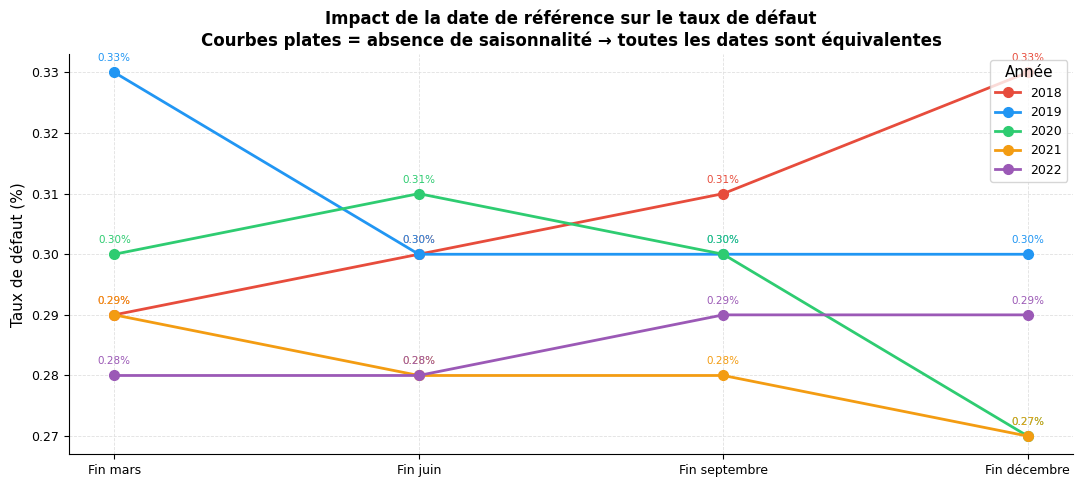

In [57]:
def plot_saisonnalite(
    df: pd.DataFrame,
    snapshots: list = SNAPSHOTS,
    date_col: str = DATE_COL,
    cible: str = CIBLE,
) -> None:
    """
    Visualise l'impact de la date de référence sur le taux de défaut.

    Chaque ligne = une année ; chaque point = taux à un snapshot trimestriel.
    Des courbes plates indiquent l'absence de saisonnalité.
    """
    df_lines = pd.DataFrame()
    for snap_code, label in snapshots:
        rates = calculer_taux_par_snapshot_annee(df, snap_code, date_col, cible)
        if not rates.empty:
            df_lines[label] = rates
    df_lines = df_lines.sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))

    for i, year in enumerate(df_lines.index):
        color = COLORS[i % len(COLORS)]
        ax.plot(
            df_lines.columns,
            df_lines.loc[year] * 100,
            marker='o', linewidth=2, markersize=7,
            color=color, label=str(year)
        )
        # Annotation du taux sur chaque point
        for j, (snap_label, val) in enumerate(df_lines.loc[year].items()):
            ax.annotate(
                f'{val*100:.2f}%',
                xy=(j, val * 100),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=7.5, color=color
            )

    ax.set_ylabel('Taux de défaut (%)', fontsize=11)
    ax.set_title(
        'Impact de la date de référence sur le taux de défaut\n'
        'Courbes plates = absence de saisonnalité → toutes les dates sont équivalentes',
        fontsize=12, fontweight='bold'
    )
    ax.legend(title='Année', fontsize=9, loc='upper right')
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/calibrage_saisonnalite.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_saisonnalite(df_final)

In [58]:
def tester_saisonnalite_ols(
    df: pd.DataFrame,
    date_col: str = DATE_COL,
    cible: str = CIBLE,
    annees: tuple = (2018, 2022),
) -> pd.DataFrame:
    """
    Test statistique de saisonnalité par régression OLS avec indicatrices
    trimestrielles.

    Modèle :
        DDefaut = γ_s (décembre, base) + β₁·D1(mars) + β₂·D2(juin) + β₃·D3(sept)

    H0 : β₁ = β₂ = β₃ = 0 (pas d'effet saisonnier)
    Si p-value > 5% pour tous les coefficients → pas de saisonnalité
    → on choisit la date de référence la plus commode (31 décembre).

    EBA/GL/2017/16, § 85 : le choix de la date de référence doit être
    documenté et justifié par ce type d'analyse.
    """
    df_ols = df.copy()
    df_ols = df_ols[
        df_ols[date_col].dt.year.between(annees[0], annees[1])
    ].copy()

    df_ols['month_day'] = df_ols[date_col].dt.strftime('%m-%d')
    df_ols['D1'] = (df_ols['month_day'] == '03-01').astype(int)  # Mars
    df_ols['D2'] = (df_ols['month_day'] == '06-01').astype(int)  # Juin
    df_ols['D3'] = (df_ols['month_day'] == '09-01').astype(int)  # Septembre
    # Décembre = référence (constante)

    X = sm.add_constant(df_ols[['D1', 'D2', 'D3']])
    y = df_ols[cible]

    model = sm.OLS(y, X).fit()

    summary = model.summary2().tables[1].reset_index()
    summary.columns = ['Variable'] + summary.columns[1:].tolist()
    summary.insert(1, 'DDL', 1)
    summary = summary.rename(columns={
        'Coef.'      : 'Coeff. estimé (βᵢ = γᵢ - γs)',
        'Std.Err.'   : 'Erreur type',
        't'          : 'Stat. t',
        'P>|t|'      : 'p-value',
        '[0.025'     : 'IC_2.5%',
        '0.975]'     : 'IC_97.5%',
    })
    summary['Décision'] = summary['p-value'].apply(
        lambda p: 'Significatif' if p < ALPHA else 'Non significatif'
    )

    print(f"\nR² = {model.rsquared:.6f} | F-stat p-value = {model.f_pvalue:.4f}")
    print(f"N observations = {int(model.nobs):,}")

    return summary


df_saisonnalite = tester_saisonnalite_ols(df_final)
print("\n" + "=" * 70)
print("TEST OLS DE SAISONNALITÉ — Coefficients des indicatrices trimestrielles")
print("=" * 70)
display(df_saisonnalite)


R² = 0.000000 | F-stat p-value = 0.9753
N observations = 475,147

TEST OLS DE SAISONNALITÉ — Coefficients des indicatrices trimestrielles


,Variable,DDL,Coeff. estimé (βᵢ = γᵢ - γs),Erreur type,Stat. t,p-value,IC_2.5%,IC_97.5%,Décision
0,const,1,0.0029,0.0002,18.4834,0.0000,0.0026,0.0032,Significatif
1,D1,1,0.0001,0.0002,0.4566,0.6479,-0.0003,0.0005,Non significatif
2,D2,1,0.0000,0.0002,0.1621,0.8712,-0.0004,0.0005,Non significatif
3,D3,1,0.0000,0.0002,0.2077,0.8355,-0.0004,0.0005,Non significatif


### 10.4 Marges de Conservatisme (MoC)

**Principe général** (EBA/GL/2017/16, §§ 95–105)

La LRA est une estimation statistique entachée d'incertitude. Les Marges de Conservatisme (MoC) ont pour rôle de **corriger prudemment vers le haut** l'estimation de la PD pour tenir compte de différentes sources d'incertitude.

L'EBA distingue trois catégories de MoC :

| Catégorie | Source d'incertitude | Méthode de calcul |
|---|---|---|
| **MoC A** | Désalignement modélisation/application ; absence de données de crise | Écart entre deux estimations de LRA (avec/sans données manquantes) |
| **MoC B** | Mesures compensatoires Covid-19 (EBA 2022) | Analyse de l'impact des moratoires sur les taux d'entrée en défaut |
| **MoC C** | Incertitude statistique de l'estimation de la LRA | Borne supérieure IC bilatéral 95% sur la distribution des taux PIT |

### 10.6.1 MoC C-Incertitude statistique

**Formule** :

$$MoC_C = z_{1-\alpha/2} \times \frac{\hat{\sigma}_{\text{PIT}}}{\sqrt{n}} = \text{IC}_{97.5\%} - LRA$$

où :
- $\hat{\sigma}_{\text{PIT}}$ : écart-type des taux PIT annuels
- $n$ : nombre d'années d'observation
- $z_{97.5\%} \approx 1.96$

**Intérêt** : plus le nombre d'années d'observation est faible (petit $n$), plus la MoC C est grande-ce qui est cohérent avec le principe de prudence réglementaire.

In [59]:
def calculer_moc_c(
    df: pd.DataFrame,
    snapshot_ref: str = SNAPSHOT_REF,
    cluster_col: str = CLUSTER_COL,
    date_col: str = DATE_COL,
    cible: str = CIBLE,
    alpha: float = ALPHA,
) -> pd.DataFrame:
    """
    Calcule la MoC C (incertitude statistique) par CHR.

    Méthode : IC bilatéral à (1-alpha)% sur la distribution des taux PIT annuels.
    MoC_C = borne supérieure IC - LRA = z_(1-alpha/2) × σ/√n

    On filtre sur la date de référence retenue (31 décembre par défaut)
    conformément à la décision de la Section 10.5.

    Paramètres
    ----------
    snapshot_ref : date de référence retenue au format MM-DD (ex. '12-01')
    alpha        : seuil de risque (défaut 5% → IC à 95%)

    Retourne
    --------
    DataFrame avec pour chaque CHR :
        LRA, σ_PIT, n, IC_bas, IC_haut, MoC_C
    """
    z_crit = norm.ppf(1 - alpha / 2)

    df_snap = df.copy()
    df_snap['snapshot'] = df_snap[date_col].dt.strftime('%m-%d')
    df_snap = df_snap[df_snap['snapshot'] == snapshot_ref]

    rows = []
    for clus in sorted(df_snap[cluster_col].dropna().unique()):
        df_c      = df_snap[df_snap[cluster_col] == clus]
        pit_rates = df_c.groupby(date_col)[cible].mean()
        n         = len(pit_rates)

        if n >= 2:
            lra     = pit_rates.mean()
            std_pit = pit_rates.std(ddof=1)
            se      = std_pit / np.sqrt(n)
            ic_lo   = max(0, lra - z_crit * se)
            ic_hi   = lra + z_crit * se
            moc_c   = ic_hi - lra
        else:
            lra = pit_rates.mean() if n == 1 else np.nan
            std_pit = ic_lo = ic_hi = moc_c = np.nan

        rows.append({
            'CHR'             : clus,
            'N_années'        : n,
            'LRA'             : round(lra, 6) if not np.isnan(lra) else np.nan,
            'σ_PIT'           : round(std_pit, 6) if not np.isnan(std_pit) else np.nan,
            f'IC_{int((1-alpha)*100)}%_bas'  : round(ic_lo, 6) if not np.isnan(ic_lo) else np.nan,
            f'IC_{int((1-alpha)*100)}%_haut' : round(ic_hi, 6) if not np.isnan(ic_hi) else np.nan,
            'MoC_C'           : round(moc_c, 6) if not np.isnan(moc_c) else np.nan,
        })

    return pd.DataFrame(rows)


df_moc_c = calculer_moc_c(df_final)

print("=" * 70)
print(f"MARGE DE CONSERVATISME C (MoC C) — Snapshot de référence : {SNAPSHOT_REF}")
print(f"IC bilatéral à {int((1-ALPHA)*100)}% | z_crit = {norm.ppf(1-ALPHA/2):.4f}")
print("=" * 70)
display(
    df_moc_c.style.format({
        col: '{:.4%}' for col in df_moc_c.columns if col not in ['CHR', 'N_années']
    })
)

MARGE DE CONSERVATISME C (MoC C) — Snapshot de référence : 12-01
IC bilatéral à 95% | z_crit = 1.9600


,CHR,N_années,LRA,σ_PIT,IC_95%_bas,IC_95%_haut,MoC_C
0,0,5,0.0492%,0.0208%,0.0310%,0.0674%,0.0182%
1,1,5,1.8591%,0.2129%,1.6725%,2.0458%,0.1866%
2,2,5,0.2788%,0.0505%,0.2345%,0.3231%,0.0443%


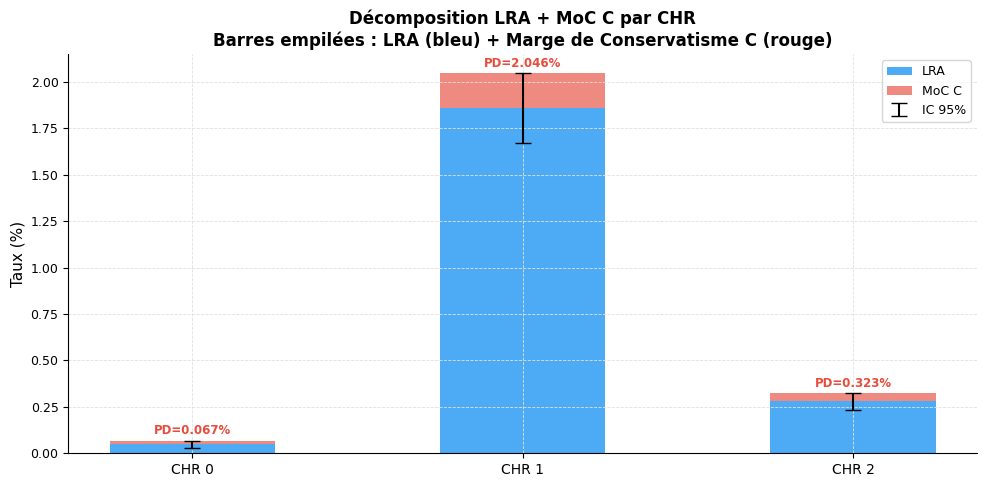

In [60]:
def plot_moc_c(
    df_moc_c: pd.DataFrame,
    lra_col: str = 'LRA',
    moc_col: str = 'MoC_C',
) -> None:
    """
    Visualise la LRA et la MoC C par CHR.
    Les barres empilées montrent la décomposition LRA + MoC_C
    et l'IC 95% sous forme d'errorbar.
    """
    ic_bas_col  = [c for c in df_moc_c.columns if 'bas'  in c][0]
    ic_haut_col = [c for c in df_moc_c.columns if 'haut' in c][0]

    fig, ax = plt.subplots(figsize=(10, 5))

    x      = np.arange(len(df_moc_c))
    labels = df_moc_c['CHR'].astype(str).tolist()

    bars_lra = ax.bar(
        x, df_moc_c[lra_col] * 100,
        color=COLOR_NEUTRE, alpha=0.80, width=0.5, label='LRA'
    )
    bars_moc = ax.bar(
        x, df_moc_c[moc_col] * 100,
        bottom=df_moc_c[lra_col] * 100,
        color=COLOR_DEFAUT, alpha=0.65, width=0.5, label='MoC C'
    )

    # Errorbars IC 95%
    yerr_lo = (df_moc_c[lra_col] - df_moc_c[ic_bas_col]) * 100
    yerr_hi = (df_moc_c[ic_haut_col] - df_moc_c[lra_col]) * 100
    ax.errorbar(
        x, df_moc_c[lra_col] * 100,
        yerr=[yerr_lo, yerr_hi],
        fmt='none', color='black', capsize=6, linewidth=1.5,
        label=f'IC {int((1-ALPHA)*100)}%'
    )

    # Annotations : LRA + MoC C
    for xi, row in df_moc_c.iterrows():
        pd_totale = (row[lra_col] + row[moc_col]) * 100
        ax.text(
            xi, pd_totale + 0.02,
            f'PD={pd_totale:.3f}%',
            ha='center', va='bottom', fontsize=8.5,
            fontweight='bold', color=COLOR_DEFAUT
        )

    ax.set_xticks(x)
    ax.set_xticklabels([f'CHR {l}' for l in labels], fontsize=10)
    ax.set_ylabel('Taux (%)')
    ax.set_title(
        'Décomposition LRA + MoC C par CHR\n'
        'Barres empilées : LRA (bleu) + Marge de Conservatisme C (rouge)',
        fontsize=12, fontweight='bold'
    )
    ax.legend(fontsize=9)
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/calibrage_moc_c.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_moc_c(df_moc_c)

### 10.5 MoC A -Désalignements et données manquantes

**Définition** (EBA/GL/2017/16, § 96)

La MoC A couvre les **désalignements entre la phase de modélisation et la phase d'application** du modèle. Elle est nulle lorsqu'aucun désalignement n'est identifié. Les principales sources :

1. **Absence de données de crise dans l'historique de calibrage** : si la période d'observation ne comprend pas d'épisode de stress économique comparable à celui prévu dans le cycle économique, la LRA sous-estime le risque long terme. Dans ce cas, on affecte à l'année manquante le pire taux de défaut observé dans l'historique. La MoC A est l'écart entre les deux LRA.

2. **Traitement différent des données manquantes** entre modélisation et scoring en production.

3. **Mauvaise hiérarchisation des CHR** ou **inhomogénéité** interne à une classe.

### 10.6. MoC B-Impact des mesures Covid-19

**Contexte** (EBA, juin 2022)

Les mesures de soutien adoptées pendant la pandémie Covid-19 (moratoires, garanties d'État, reports d'échéances) ont artificiellement réduit les entrées en défaut entre 2020 et 2021. Si ces années sont incluses dans l'historique de calibrage, la LRA est **biaisée à la baisse**.

La MoC B est calculée en 4 étapes :
1. Identifier les années affectées par des mesures compensatoires
2. Estimer le taux de défaut contrefactuel (sans mesures)
3. Calculer l'écart entre LRA avec et sans correction
4. La MoC B = cet écart

> **Note** : les MoC A et B font l'objet d'une analyse qualitative documentée dans le rapport de validation du modèle. Leur quantification dépend des données spécifiques du portefeuille.

In [61]:
# ── MoC A — Saisie manuelle des résultats de l'analyse experte ───────────────
# À renseigner après l'analyse qualitative des désalignements.
# Valeur par défaut = 0 (pas de désalignement identifié).

df_moc_a = pd.DataFrame({
    'CHR'  : sorted(df_final[CLUSTER_COL].dropna().unique()),
    'MoC_A': 0.0,    # À compléter selon analyse experte
    'Justification_A': 'Pas de désalignement identifié entre modélisation et application'
})

# ── MoC B — Saisie manuelle des résultats de l'analyse Covid ─────────────────
# À renseigner après analyse de l'impact des mesures compensatoires.

df_moc_b = pd.DataFrame({
    'CHR'  : sorted(df_final[CLUSTER_COL].dropna().unique()),
    'MoC_B': 0.0,    # À compléter selon analyse Covid EBA 2022
    'Justification_B': 'Pas de correction significative identifiée'
})

print("MoC A par CHR :")
display(df_moc_a)

print("\nMoC B par CHR :")
display(df_moc_b)

MoC A par CHR :


,CHR,MoC_A,Justification_A
0,0,0.0000,Pas de désalignement identifié entre modélisat...
1,1,0.0000,Pas de désalignement identifié entre modélisat...
2,2,0.0000,Pas de désalignement identifié entre modélisat...



MoC B par CHR :


,CHR,MoC_B,Justification_B
0,0,0.0000,Pas de correction significative identifiée
1,1,0.0000,Pas de correction significative identifiée
2,2,0.0000,Pas de correction significative identifiée


### 10.7 Estimation finale de la PD calibrée par CHR

**Formule de synthèse**

$$\boxed{PD_i = \max\left(0.03\%,\ LRA_i + Ajustement_i + MoC_{A,i} + MoC_{B,i} + MoC_{C,i}\right)}$$

**Convention de signe** :
- Le seuil plancher de **0,03%** (retail) est imposé par BCBS (2006) § 463
- L'ajustement est positif si les contrats courts biaisent la LRA à la baisse
- Toutes les MoC sont positives par construction (prudence réglementaire)

**Interprétation attendue** : la PD calibrée doit être :
- **Monotone croissante** avec le numéro de CHR (CHR 1 = moins risquée)
- **Significativement différente** entre classes (test de Marascuilo validé en Section 8.4)
- **Stable dans le temps** (vérifiée par la stabilité des CHR en Section 8.3)

In [62]:
def estimer_pd_finale(
    df_moc_c: pd.DataFrame,
    df_moc_a: pd.DataFrame,
    df_moc_b: pd.DataFrame,
    df_wilcoxon: pd.DataFrame,
    fenetre_retenue: str = '5_ans',
    pd_plancher: float = PD_PLANCHER,
) -> pd.DataFrame:
    """
    Calcule la PD calibrée finale par CHR.

    Formule :
        PD = max(PD_plancher, LRA + Ajustement + MoC_A + MoC_B + MoC_C)

    L'ajustement pour contrats courts est nul si le test de Wilcoxon
    est non significatif (aucun biais détecté).

    Paramètres
    ----------
    fenetre_retenue : fenêtre temporelle retenue pour la LRA (ex. '5_ans')
    pd_plancher     : seuil plancher réglementaire (0.03% par défaut)

    Retourne
    --------
    DataFrame de synthèse avec LRA, MoC A/B/C, PD brute, PD calibrée
    """
    # Ajustement contrats courts : nul si Wilcoxon non significatif
    ajustement_dict = {}
    if df_wilcoxon is not None and not df_wilcoxon.empty:
        for _, row in df_wilcoxon[
            df_wilcoxon['Fenêtre'] == fenetre_retenue
        ].iterrows():
            if 'Significatif' in str(row.get('Décision', '')):
                ajustement_dict[str(row['CHR'])] = abs(
                    row.get('Écart', 0) or 0
                )
            else:
                ajustement_dict[str(row['CHR'])] = 0.0

    rows = []
    for _, row_c in df_moc_c.iterrows():
        clus   = str(row_c['CHR'])
        lra    = row_c['LRA']
        moc_c  = row_c['MoC_C']

        moc_a = df_moc_a.loc[
            df_moc_a['CHR'].astype(str) == clus, 'MoC_A'
        ].values[0] if clus in df_moc_a['CHR'].astype(str).values else 0.0

        moc_b = df_moc_b.loc[
            df_moc_b['CHR'].astype(str) == clus, 'MoC_B'
        ].values[0] if clus in df_moc_b['CHR'].astype(str).values else 0.0

        ajustement = ajustement_dict.get(clus, 0.0)

        pd_brute   = lra + ajustement + moc_a + moc_b + moc_c
        pd_calibre = max(pd_plancher, pd_brute)
        plancher_actif = pd_calibre == pd_plancher and pd_brute < pd_plancher

        rows.append({
            'CHR'              : clus,
            'N_années'         : int(row_c['N_années']),
            'LRA'              : lra,
            'Ajustement_Contrats_Courts': ajustement,
            'MoC_A'            : moc_a,
            'MoC_B'            : moc_b,
            'MoC_C'            : moc_c,
            'PD_Brute'         : pd_brute,
            'PD_Calibree'      : pd_calibre,
            'Plancher_Actif'   : 'OK' if plancher_actif else '—',
        })

    df_pd = pd.DataFrame(rows).sort_values('CHR').reset_index(drop=True)

    # Vérification de la monotonicité
    pd_vals    = df_pd['PD_Calibree'].values
    is_mono    = all(pd_vals[i] <= pd_vals[i+1] for i in range(len(pd_vals)-1))
    mono_label = 'Monotonicité respectée' if is_mono else 'Monotonicité non respectée — à vérifier'
    print(f"Vérification : {mono_label}")

    return df_pd


df_pd_finale = estimer_pd_finale(
    df_moc_c    = df_moc_c,
    df_moc_a    = df_moc_a,
    df_moc_b    = df_moc_b,
    df_wilcoxon = df_wilcoxon,
    fenetre_retenue = '5_ans',
)

print("\n" + "=" * 70)
print("TABLEAU DE SYNTHÈSE — PD CALIBRÉE FINALE PAR CHR")
print(f"Seuil plancher réglementaire : {PD_PLANCHER:.2%}")
print("=" * 70)

cols_pct = ['LRA', 'Ajustement_Contrats_Courts', 'MoC_A',
            'MoC_B', 'MoC_C', 'PD_Brute', 'PD_Calibree']
display(
    df_pd_finale.style.format(
        {col: '{:.4%}' for col in cols_pct if col in df_pd_finale.columns}
    ).background_gradient(
        subset=['PD_Calibree'], cmap='RdYlGn_r'
    )
)

Vérification : Monotonicité non respectée — à vérifier

TABLEAU DE SYNTHÈSE — PD CALIBRÉE FINALE PAR CHR
Seuil plancher réglementaire : 0.03%


,CHR,N_années,LRA,Ajustement_Contrats_Courts,MoC_A,MoC_B,MoC_C,PD_Brute,PD_Calibree,Plancher_Actif
0,0.0,5,0.0492%,0.0000%,0.0000%,0.0000%,0.0182%,0.0674%,0.0674%,—
1,1.0,5,1.8591%,0.0000%,0.0000%,0.0000%,0.1866%,2.0457%,2.0457%,—
2,2.0,5,0.2788%,0.0000%,0.0000%,0.0000%,0.0443%,0.3231%,0.3231%,—


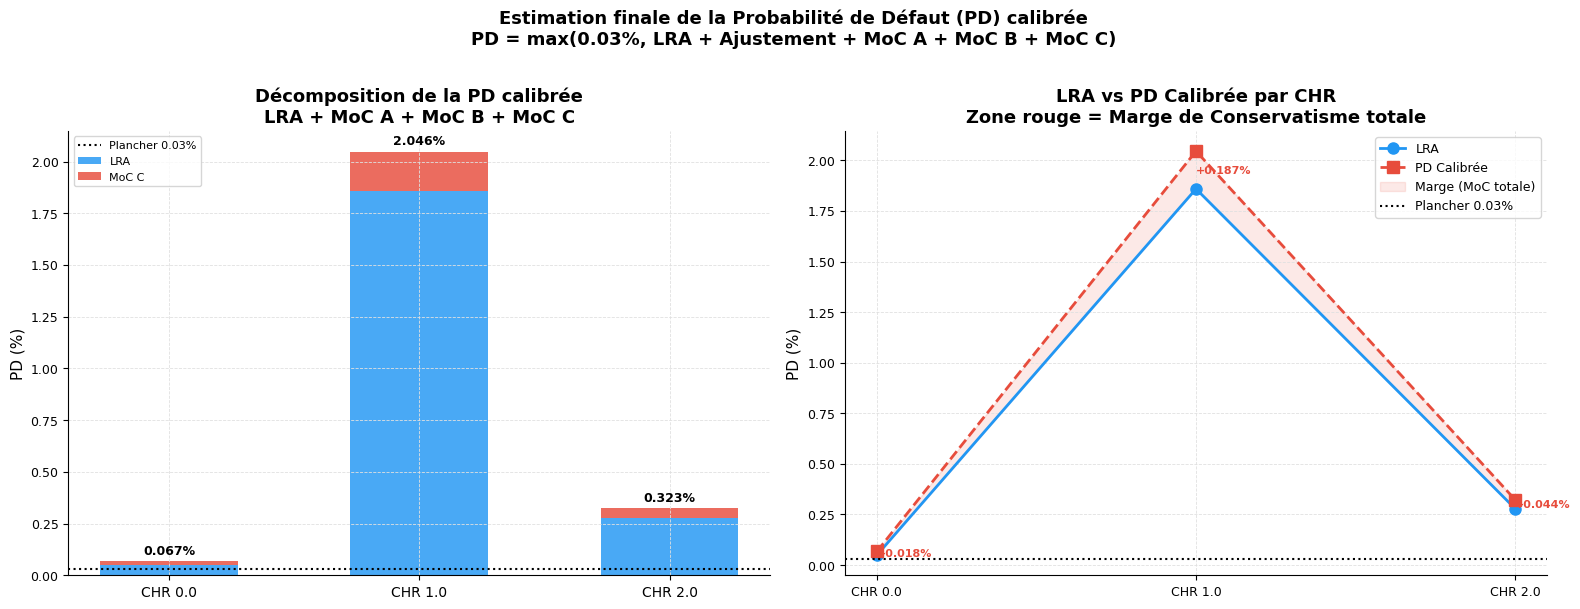

In [63]:
def plot_pd_finale(
    df_pd: pd.DataFrame,
    pd_plancher: float = PD_PLANCHER,
) -> None:
    """
    Visualisation de la décomposition de la PD calibrée finale par CHR.

    Graphique 1 : Barres empilées (LRA + MoC A + MoC B + MoC C + Ajustement)
    Graphique 2 : PD calibrée vs LRA — delta visible par CHR
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    x      = np.arange(len(df_pd))
    labels = [f'CHR {c}' for c in df_pd['CHR']]
    width  = 0.55

    # ── Graphique 1 : Barres empilées ─────────────────────────────────────────
    ax1 = axes[0]

    composantes = [
        ('LRA',                           COLOR_NEUTRE,  'LRA'),
        ('MoC_C',                         COLOR_DEFAUT,  'MoC C'),
        ('MoC_A',                         COLOR_ACCENT,  'MoC A'),
        ('MoC_B',                         '#9B59B6',     'MoC B'),
        ('Ajustement_Contrats_Courts',    '#555555',     'Ajust. Contrats Courts'),
    ]

    bottom = np.zeros(len(df_pd))
    for col, color, label in composantes:
        vals = df_pd[col].values * 100
        if vals.sum() > 0:
            ax1.bar(x, vals, width, bottom=bottom,
                    color=color, alpha=0.82, label=label)
            bottom += vals

    # Ligne plancher
    ax1.axhline(
        pd_plancher * 100, color='black', linestyle=':',
        linewidth=1.5, label=f'Plancher {pd_plancher:.2%}'
    )

    for xi, row in df_pd.iterrows():
        ax1.text(
            xi, row['PD_Calibree'] * 100 + 0.02,
            f"{row['PD_Calibree']:.3%}",
            ha='center', va='bottom', fontsize=9, fontweight='bold'
        )

    ax1.set_xticks(x)
    ax1.set_xticklabels(labels, fontsize=10)
    ax1.set_ylabel('PD (%)')
    ax1.set_title('Décomposition de la PD calibrée\nLRA + MoC A + MoC B + MoC C',
                  fontweight='bold')
    ax1.legend(fontsize=8, loc='upper left')

    # ── Graphique 2 : LRA vs PD calibrée ──────────────────────────────────────
    ax2 = axes[1]

    ax2.plot(
        labels, df_pd['LRA'] * 100,
        color=COLOR_NEUTRE, marker='o', linewidth=2,
        markersize=8, label='LRA'
    )
    ax2.plot(
        labels, df_pd['PD_Calibree'] * 100,
        color=COLOR_DEFAUT, marker='s', linewidth=2,
        markersize=8, linestyle='--', label='PD Calibrée'
    )

    # Zone MoC
    ax2.fill_between(
        labels,
        df_pd['LRA'] * 100,
        df_pd['PD_Calibree'] * 100,
        alpha=0.12, color=COLOR_DEFAUT, label='Marge (MoC totale)'
    )

    ax2.axhline(
        pd_plancher * 100, color='black', linestyle=':',
        linewidth=1.5, label=f'Plancher {pd_plancher:.2%}'
    )

    # Annotations delta MoC total
    for xi, (_, row) in enumerate(df_pd.iterrows()):
        delta = (row['PD_Calibree'] - row['LRA']) * 100
        mid   = (row['LRA'] + row['PD_Calibree']) / 2 * 100
        ax2.text(
            xi, mid, f'+{delta:.3f}%',
            ha='left', va='center', fontsize=8,
            color=COLOR_DEFAUT, fontweight='bold'
        )

    ax2.set_ylabel('PD (%)')
    ax2.set_title('LRA vs PD Calibrée par CHR\n'
                  'Zone rouge = Marge de Conservatisme totale',
                  fontweight='bold')
    ax2.legend(fontsize=9)

    fig.suptitle(
        'Estimation finale de la Probabilité de Défaut (PD) calibrée\n'
        f'PD = max({pd_plancher:.2%}, LRA + Ajustement + MoC A + MoC B + MoC C)',
        fontsize=13, fontweight='bold', y=1.01
    )
    fig.tight_layout()
    fig.savefig(
        f"{OUTPUT_DIR}/calibrage_pd_finale.png",
        bbox_inches='tight', dpi=150
    )
    plt.show()


plot_pd_finale(df_pd_finale)

### 10.7 Export des résultats de calibrage

Les résultats du calibrage sont exportés dans plusieurs formats pour alimenter :
- le **rapport de validation** du modèle
- le **système de notation** en production (mapping CHR → PD)
- les **calculs d'exigences en fonds propres** (RWA = f(PD, LGD, EAD))
- les **provisions IFRS 9** (ECL = PD × LGD × EAD)

In [64]:
# ── Ajout de la PD calibrée à la base complète ────────────────────────────────
pd_map = df_pd_finale.set_index('CHR')['PD_Calibree'].to_dict()
df_final['PD_Calibree'] = df_final[CLUSTER_COL].astype(str).map(pd_map)

# ── Exports ───────────────────────────────────────────────────────────────────
exports = {
    'PD_Calibree_par_CHR'         : df_pd_finale,
    'MoC_C_detail'                : df_moc_c,
    'MoC_A_detail'                : df_moc_a,
    'MoC_B_detail'                : df_moc_b,
    'LRA_Classique_par_fenetre'   : lra_classique.reset_index(),
    'LRA_Stable_par_fenetre'      : lra_stable.reset_index(),
    'Test_Wilcoxon_Contrats_Courts': df_wilcoxon,
    'Test_Saisonnalite_OLS'       : df_saisonnalite,
}

for nom, df_exp in exports.items():
    path_csv = f"{OUTPUT_DIR}/Calibrage_{nom}.csv"
    df_exp.to_csv(path_csv, index=False, encoding='utf-8')
    print(f"OK {path_csv}")

# Base complète enrichie avec PD
df_final.to_csv(
    f"{OUTPUT_DIR}/Base_Modele_PD_Final_Calibre.csv",
    index=False, encoding='utf-8'
)
print(f"\n OK {OUTPUT_DIR}/Base_Modele_PD_Final_Calibre.csv")

# Résumé final
print("\n" + "=" * 70)
print("RÉSUMÉ FINAL DU CALIBRAGE")
print("=" * 70)
for _, row in df_pd_finale.iterrows():
    print(
        f"  CHR {row['CHR']} | "
        f"LRA = {row['LRA']:.4%} | "
        f"MoC_C = {row['MoC_C']:.4%} | "
        f"PD calibrée = {row['PD_Calibree']:.4%}"
    )

OK output/Calibrage_PD_Calibree_par_CHR.csv
OK output/Calibrage_MoC_C_detail.csv
OK output/Calibrage_MoC_A_detail.csv
OK output/Calibrage_MoC_B_detail.csv
OK output/Calibrage_LRA_Classique_par_fenetre.csv
OK output/Calibrage_LRA_Stable_par_fenetre.csv
OK output/Calibrage_Test_Wilcoxon_Contrats_Courts.csv
OK output/Calibrage_Test_Saisonnalite_OLS.csv

 OK output/Base_Modele_PD_Final_Calibre.csv

RÉSUMÉ FINAL DU CALIBRAGE
  CHR 0.0 | LRA = 0.0492% | MoC_C = 0.0182% | PD calibrée = 0.0674%
  CHR 1.0 | LRA = 1.8591% | MoC_C = 0.1866% | PD calibrée = 2.0457%
  CHR 2.0 | LRA = 0.2788% | MoC_C = 0.0443% | PD calibrée = 0.3231%


In [68]:
df_pd_finale.to_excel(
    f"{OUTPUT_DIR}/Calibrage_PD_Calibree_par_CHR.xlsx", index=False
)